# 🩺 Clasificación de Cáncer de Mama en DCE-MRI mediante Deep Learning
## Transfer Learning + Fine-Tuning Progresivo + 5-Fold CV | Erika Alexandra García Barrios
### `BreastCancer_DCE_DL` —
---

**Modelos:** ResNet50 (RadImageNet) · EfficientNet-B3 (ImageNet) · MobileViT-S (Transformer)  
**Predicción:** NIVEL PACIENTE — `patient → mean(sigmoid(logits_slices))`  
**Validación:** 5-Fold Estratificado por Paciente (sin data leakage)  
**Normalización:** Z-score por estudio MRI (no ImageNet — corrección crítica auditoría)  
**Threshold:** Optimizado en VAL → aplicado FIJO en TEST (corrección leakage)  
**Target clínico:** Sensibilidad ≥ 0.95 (estándar screening mamario)  
**Augmentation médica:** Flip H · Rot ±12° · Escala leve ·   
**PROHIBIDO:** Flip vertical · Rot >20° · Deformaciones geométricas  
**Tracking:** TensorBoard + MLflow + Telegram  
**Paper base:** BreastDM — A DCE-MRI Dataset for Breast Tumor Classification  
**Benchmark objetivo:** ACC ≥ 88.20% · AUC ≥ 0.9154

---
### 📋 Correcciones respecto a iter2 (Auditoría)
| Error detectado | Corrección en iter3 |
|---|---|
| Normalización ImageNet en MRI | ✅ Z-score por estudio |
| Threshold buscado en test | ✅ Threshold en val → fijo en test |
| Sin validación cruzada | ✅ 5-Fold estratificado por paciente |
| Sin Transformer | ✅ MobileViT-S como tercer modelo |
| ResNet solo con ImageNet | ✅ ResNet50 con pesos RadImageNet |
| Target sensibilidad 0.90 | ✅ Target ≥ 0.95 con justificación |


## 1. Configuración Global del Experimento

> Centraliza la identidad principal de la corrida experimental.
>
> Aquí se define:
> - nombre del proyecto,
> - versión / iteración,
> - descripción experimental,
> - y seed global reproducible.
>
> Esta configuración será reutilizada posteriormente
> en MLflow, checkpoints, métricas, evidencias
> y organización experimental del pipeline.
>
> El objetivo es mantener una única fuente de verdad
> para la configuración global del experimento.

In [1]:
# ============================================================
# BLOQUE 1 — CONFIGURACIÓN GLOBAL DEL EXPERIMENTO
# ============================================================

PROYECTO = "BreastCancer_DCE_DL"

ITER = "VF"

DESCRIPTION = (
    "Pipeline modular V6 para clasificación de cáncer "
    "de mama en DCE-MRI usando Transfer Learning, "
    "Fine-Tuning progresivo y evaluación clínica "
    "a nivel paciente"
)

SEED = 42

print(f"✅ Proyecto: {PROYECTO}")
print(f"✅ Iteración: {ITER}")
print(f"📝 Descripción: {DESCRIPTION}")
print(f"🎲 Seed global: {SEED}")

✅ Proyecto: BreastCancer_DCE_DL
✅ Iteración: VF
📝 Descripción: Pipeline modular V6 para clasificación de cáncer de mama en DCE-MRI usando Transfer Learning, Fine-Tuning progresivo y evaluación clínica a nivel paciente
🎲 Seed global: 42


## 2. Imports, Seeds y Configuración CUDA

> Centraliza todos los imports utilizados a lo largo
> del pipeline de Deep Learning.
>
> Este bloque incluye:
> - PyTorch y torchvision,
> - métricas clínicas y validación,
> - visualización,
> - tracking experimental,
> - reproducibilidad,
> - y configuración CUDA.
>
> También configura:
> - seeds determinísticas,
> - device global (`cpu` / `cuda`),
> - y validación del entorno de ejecución.
>
> Librerías importantes:
> - `timm` → backbones modernos como MobileViT-S
> - `mlflow` → tracking experimental
> - `StratifiedGroupKFold` → validación 5-Fold por paciente
>
> El objetivo es garantizar un entorno reproducible,
> modular y consistente para todo el pipeline.

In [2]:
# ============================================================
# BLOQUE 2 — IMPORTS, SEEDS Y CONFIGURACIÓN CUDA
# ============================================================

# ============================================================
# STANDARD LIBRARY
# ============================================================

import os
import sys
import time
import copy
import yaml
import random
import pickle
import warnings

from pathlib import Path
from datetime import datetime
from collections import defaultdict

# ============================================================
# DATA SCIENCE
# ============================================================

import numpy as np
import pandas as pd

# ============================================================
# VISUALIZACIÓN
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ============================================================
# COMPUTER VISION
# ============================================================

import cv2

# ============================================================
# PYTORCH
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader,
    Subset
)

from torch.utils.tensorboard import SummaryWriter

from torch.optim.lr_scheduler import CosineAnnealingLR

from torchvision import (
    models,
    transforms
)

# ============================================================
# MODELOS PRETRAINED
# ============================================================

import timm

# ============================================================
# TRACKING EXPERIMENTAL
# ============================================================

import mlflow
import mlflow.pytorch

# ============================================================
# MÉTRICAS Y VALIDACIÓN
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss
)

from sklearn.model_selection import (
    StratifiedGroupKFold
)

from sklearn.calibration import (
    calibration_curve
)

from scipy import stats as scipy_stats

# ============================================================
# UTILIDADES
# ============================================================

from tqdm import tqdm

warnings.filterwarnings("ignore")

%matplotlib inline

# ============================================================
# CONFIGURACIÓN REPRODUCIBLE
# ============================================================

def set_seed(seed: int = 42):
    """
    Configuración determinística global.
    """

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"✅ Seed configurada: {seed}")


set_seed(SEED)

# ============================================================
# CONFIGURACIÓN CUDA
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"\n✅ Device detectado: {DEVICE}")

if torch.cuda.is_available():

    gpu_name = torch.cuda.get_device_name(0)

    gpu_memory = (
        torch.cuda.get_device_properties(0).total_memory / 1e9
    )

    print(f"🔥 GPU: {gpu_name}")
    print(f"💾 VRAM: {gpu_memory:.1f} GB")

print("\n✅ Entorno inicializado correctamente")

✅ Seed configurada: 42

✅ Device detectado: cuda
🔥 GPU: NVIDIA RTX A4000
💾 VRAM: 16.7 GB

✅ Entorno inicializado correctamente


## 3. Configuración de Paths V6

> Centraliza toda la estructura de rutas y carpetas
> utilizadas por el pipeline experimental V6.
>
> Aquí se define:
> - repositorio principal,
> - dataset,
> - archivos CSV,
> - estructura experimental,
> - y directorios de artefactos.
>
> Este bloque también:
> - añade el repositorio al `PYTHONPATH`,
> - valida la existencia del dataset,
> - valida los CSVs necesarios,
> - y prepara la arquitectura modular reproducible.
>
> La estructura V6 separa completamente:
> - modelos,
> - métricas,
> - evidencias,
> - logs,
> - configuraciones,
> - y notebooks experimentales.
>
> No se permiten:
> - paths hardcodeados dispersos,
> - variables legacy,
> - ni dependencias ocultas entre celdas.
>
> Toda la ejecución debe depender de una única fuente
> de verdad para los paths del proyecto.

In [3]:
# ============================================================
# BLOQUE 3 — CONFIGURACIÓN DE PATHS V6
# ============================================================

from pathlib import Path
import sys

# ============================================================
# REPOSITORIO BASE
# ============================================================

REPO_PATH = Path(
    "/workspace/breast-cancer-dce-mri-classification"
)

# ============================================================
# RAÍZ EXPERIMENTAL V6
# ============================================================

V6_ROOT = (
    REPO_PATH /
    "BreastCancer_DCE_DL_v6"
)

EXPERIMENTS_ROOT = (
    V6_ROOT /
    "experiments"
)

CURRENT_EXPERIMENT = (
    EXPERIMENTS_ROOT /
    f"exp-{ITER}"
)

# ============================================================
# DIRECTORIOS EXPERIMENTALES
# ============================================================

MODELS_DIR = (
    CURRENT_EXPERIMENT /
    "models"
)

METRICS_DIR = (
    CURRENT_EXPERIMENT /
    "metrics"
)

EVIDENCIAS_DIR = (
    CURRENT_EXPERIMENT /
    "evidencias"
)

LOGS_DIR = (
    CURRENT_EXPERIMENT /
    "logs"
)

CONFIGS_DIR = (
    CURRENT_EXPERIMENT /
    "configs"
)

NOTEBOOK_DIR = (
    CURRENT_EXPERIMENT /
    "notebooks"
)

# ============================================================
# DATASET
# ============================================================

DATASET_ROOT = (
    REPO_PATH /
    "data"
)

PROCESSED_DIR = (
    DATASET_ROOT /
    "processed"
)

# ============================================================
# CSVs
# ============================================================

TRAIN_CSV = (
    PROCESSED_DIR /
    "BREAST_ROI_TRAIN.csv"
)

VAL_CSV = (
    PROCESSED_DIR /
    "BREAST_ROI_VAL.csv"
)

TEST_CSV = (
    PROCESSED_DIR /
    "BREAST_ROI_TEST.csv"
)

FULL_CSV = (
    PROCESSED_DIR /
    "BREAST_ROI_FULL.csv"
)

# ============================================================
# CREACIÓN DE DIRECTORIOS V6
# ============================================================

v6_directories = [

    V6_ROOT,

    EXPERIMENTS_ROOT,

    CURRENT_EXPERIMENT,

    MODELS_DIR,

    METRICS_DIR,

    EVIDENCIAS_DIR,

    LOGS_DIR,

    CONFIGS_DIR,

    NOTEBOOK_DIR
]

for directory in v6_directories:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )

# ============================================================
# PYTHON PATH
# ============================================================

if str(REPO_PATH) not in sys.path:

    sys.path.insert(
        0,
        str(REPO_PATH)
    )

# ============================================================
# VALIDACIÓN CSVs
# ============================================================

required_csvs = [

    TRAIN_CSV,

    VAL_CSV,

    TEST_CSV
]

missing_csvs = [

    str(csv_path)

    for csv_path in required_csvs

    if not csv_path.exists()
]

if missing_csvs:

    raise FileNotFoundError(
        f"""
❌ CSVs faltantes:

{missing_csvs}

📂 Verifica:

{PROCESSED_DIR}
"""
    )

# ============================================================
# VALIDACIÓN DATASET
# ============================================================

required_dataset_dirs = [

    DATASET_ROOT / "train",

    DATASET_ROOT / "val",

    DATASET_ROOT / "test"
]

missing_dataset_dirs = [

    str(dataset_dir)

    for dataset_dir in required_dataset_dirs

    if not dataset_dir.exists()
]

if missing_dataset_dirs:

    raise FileNotFoundError(
        f"""
❌ Dataset incompleto.

Faltan carpetas:

{missing_dataset_dirs}
"""
    )

# ============================================================
# INFO GENERAL
# ============================================================

print("✅ Arquitectura V6 configurada correctamente")

print("\n📂 REPO_PATH")
print(f"   {REPO_PATH}")

print("\n📂 CURRENT_EXPERIMENT")
print(f"   {CURRENT_EXPERIMENT}")

print("\n📂 MODELS_DIR")
print(f"   {MODELS_DIR}")

print("\n📂 METRICS_DIR")
print(f"   {METRICS_DIR}")

print("\n📂 EVIDENCIAS_DIR")
print(f"   {EVIDENCIAS_DIR}")

print("\n📂 LOGS_DIR")
print(f"   {LOGS_DIR}")

print("\n📂 CONFIGS_DIR")
print(f"   {CONFIGS_DIR}")

print("\n📂 NOTEBOOK_DIR")
print(f"   {NOTEBOOK_DIR}")

print("\n📂 DATASET_ROOT")
print(f"   {DATASET_ROOT}")

print("\n📄 CSVs detectados")

print(f"   TRAIN → {TRAIN_CSV.name}")
print(f"   VAL   → {VAL_CSV.name}")
print(f"   TEST  → {TEST_CSV.name}")

if FULL_CSV.exists():

    print(f"   FULL  → {FULL_CSV.name}")

print("\n✅ Dataset validado correctamente")

# ============================================================
# RESUMEN FINAL
# ============================================================

print("\n🧠 Arquitectura activa: V6 modular experimental")

print(
    "\n✅ Una sola fuente de verdad para todos los paths"
)

✅ Arquitectura V6 configurada correctamente

📂 REPO_PATH
   /workspace/breast-cancer-dce-mri-classification

📂 CURRENT_EXPERIMENT
   /workspace/breast-cancer-dce-mri-classification/BreastCancer_DCE_DL_v6/experiments/exp-VF

📂 MODELS_DIR
   /workspace/breast-cancer-dce-mri-classification/BreastCancer_DCE_DL_v6/experiments/exp-VF/models

📂 METRICS_DIR
   /workspace/breast-cancer-dce-mri-classification/BreastCancer_DCE_DL_v6/experiments/exp-VF/metrics

📂 EVIDENCIAS_DIR
   /workspace/breast-cancer-dce-mri-classification/BreastCancer_DCE_DL_v6/experiments/exp-VF/evidencias

📂 LOGS_DIR
   /workspace/breast-cancer-dce-mri-classification/BreastCancer_DCE_DL_v6/experiments/exp-VF/logs

📂 CONFIGS_DIR
   /workspace/breast-cancer-dce-mri-classification/BreastCancer_DCE_DL_v6/experiments/exp-VF/configs

📂 NOTEBOOK_DIR
   /workspace/breast-cancer-dce-mri-classification/BreastCancer_DCE_DL_v6/experiments/exp-VF/notebooks

📂 DATASET_ROOT
   /workspace/breast-cancer-dce-mri-classification/data

📄 CSVs 

## 4. Validación del Dataset y Reconstrucción de CSVs

> Este bloque valida la integridad estructural del dataset
> y reconstruye dinámicamente los archivos CSV utilizados
> por el pipeline.
>
> El proceso:
> - verifica la existencia de los splits (`train`, `val`, `test`),
> - recorre automáticamente la estructura del dataset,
> - detecta pacientes y clases,
> - valida secuencias DCE-MRI requeridas,
> - y genera los CSVs de entrenamiento.
>
> Cada registro reconstruido contiene:
> - identificador de paciente,
> - etiqueta clínica,
> - imagen pre-contraste,
> - post-contraste temprano,
> - y post-contraste tardío.
>
> Este enfoque garantiza:
> - compatibilidad multiplataforma,
> - reconstrucción reproducible,
> - eliminación de dependencias manuales,
> - y consistencia entre dataset físico y metadatos.
>
> El bloque también genera:
> - `BREAST_ROI_TRAIN.csv`
> - `BREAST_ROI_VAL.csv`
> - `BREAST_ROI_TEST.csv`
> - `BREAST_ROI_FULL.csv`
>
> Toda la reconstrucción se realiza automáticamente
> a partir de la estructura real del dataset.

In [4]:
# ============================================================
# BLOQUE 4 — VALIDACIÓN DEL DATASET Y RECONSTRUCCIÓN CSV
# ============================================================

import pandas as pd

from pathlib import Path

# ============================================================
# VALIDACIÓN DEL DATASET
# ============================================================

def validate_dataset_structure():
    """
    Verifica que existan los splits necesarios
    para el pipeline.
    """

    required_splits = [

        "train",

        "val",

        "test"
    ]

    missing_splits = []

    for split in required_splits:

        split_path = (
            DATASET_ROOT / split
        )

        if not split_path.exists():

            missing_splits.append(
                str(split_path)
            )

    if missing_splits:

        raise FileNotFoundError(
            f"""
❌ Dataset incompleto.

Faltan los siguientes splits:

{missing_splits}
"""
        )

    print("✅ Dataset detectado correctamente")


# ============================================================
# RECONSTRUCCIÓN DE CSVs
# ============================================================

def rebuild_csvs():
    """
    Reconstruye dinámicamente los CSVs del dataset
    a partir de la estructura física de carpetas.
    """

    print("\n🔄 Reconstruyendo CSVs...")

    processed_dir = (
        DATASET_ROOT / "processed"
    )

    processed_dir.mkdir(
        exist_ok=True
    )

    split_dfs = {}

    full_records = []

    # ========================================================
    # RECORRER SPLITS
    # ========================================================

    for split in [

        "train",

        "val",

        "test"
    ]:

        split_path = (
            DATASET_ROOT / split
        )

        records = []

        # ====================================================
        # RECORRER CLASES
        # ====================================================

        for label_dir in split_path.iterdir():

            if not label_dir.is_dir():
                continue

            label = (

                "Malignant"

                if "Mal" in label_dir.name

                else "Benign"
            )

            # ================================================
            # RECORRER PACIENTES
            # ================================================

            for patient_dir in label_dir.iterdir():

                if not patient_dir.is_dir():
                    continue

                patient_id = patient_dir.name

                # ============================================
                # SECUENCIAS DCE-MRI
                # ============================================

                pre_dir = (
                    patient_dir / "VIBRANT"
                )

                early_dir = (
                    patient_dir / "VIBRANT+C2"
                )

                late_dir = (
                    patient_dir / "VIBRANT+C7"
                )

                # ============================================
                # VALIDAR SECUENCIAS
                # ============================================

                required_sequences = [

                    pre_dir,

                    early_dir,

                    late_dir
                ]

                if not all(
                    sequence.exists()

                    for sequence in required_sequences
                ):

                    continue

                # ============================================
                # IMÁGENES PRE-CONTRASTE
                # ============================================

                pre_images = sorted(
                    pre_dir.glob("*.jpg")
                )

                for pre_image in pre_images:

                    filename = pre_image.name

                    early_image = (
                        early_dir / filename
                    )

                    late_image = (
                        late_dir / filename
                    )

                    # ========================================
                    # VALIDAR MATCH ENTRE FASES
                    # ========================================

                    if (

                        not early_image.exists()

                        or not late_image.exists()
                    ):

                        continue

                    row = {

                        "patient": patient_id,

                        "label": label,

                        "pre_contrast": str(
                            pre_image.relative_to(
                                DATASET_ROOT
                            )
                        ),

                        "post_early": str(
                            early_image.relative_to(
                                DATASET_ROOT
                            )
                        ),

                        "post_late": str(
                            late_image.relative_to(
                                DATASET_ROOT
                            )
                        )
                    }

                    records.append(row)

                    full_records.append(row)

        # ====================================================
        # DATAFRAME DEL SPLIT
        # ====================================================

        split_df = pd.DataFrame(records)

        split_csv_path = (

            processed_dir /

            f"BREAST_ROI_{split.upper()}.csv"
        )

        split_df.to_csv(
            split_csv_path,
            index=False
        )

        split_dfs[split] = split_df

        print(
            f"✅ {split.upper()} CSV → "
            f"{len(split_df)} slices"
        )

        print(
            f"   👤 Pacientes únicos: "
            f"{split_df['patient'].nunique()}"
        )

    # ========================================================
    # FULL CSV
    # ========================================================

    full_df = pd.DataFrame(
        full_records
    )

    full_csv_path = (

        processed_dir /

        "BREAST_ROI_FULL.csv"
    )

    full_df.to_csv(
        full_csv_path,
        index=False
    )

    # ========================================================
    # RESUMEN FINAL
    # ========================================================

    print("\n✅ FULL CSV reconstruido")

    print(
        f"📌 Total slices: "
        f"{len(full_df)}"
    )

    print(
        f"👤 Pacientes únicos: "
        f"{full_df['patient'].nunique()}"
    )

    print(
        f"📄 CSV guardado en:\n"
        f"   {full_csv_path}"
    )

    return split_dfs, full_df


# ============================================================
# EJECUCIÓN
# ============================================================

validate_dataset_structure()

split_dfs, full_df = rebuild_csvs()

print("\n✅ Dataset listo para entrenamiento")

✅ Dataset detectado correctamente

🔄 Reconstruyendo CSVs...
✅ TRAIN CSV → 1202 slices
   👤 Pacientes únicos: 166
✅ VAL CSV → 117 slices
   👤 Pacientes únicos: 19
✅ TEST CSV → 403 slices
   👤 Pacientes únicos: 47

✅ FULL CSV reconstruido
📌 Total slices: 1722
👤 Pacientes únicos: 232
📄 CSV guardado en:
   /workspace/breast-cancer-dce-mri-classification/data/processed/BREAST_ROI_FULL.csv

✅ Dataset listo para entrenamiento


## 5. Generación de Splits Patient-Level

> Este bloque genera los splits clínicamente válidos
> utilizados por el pipeline experimental.
>
> El proceso se realiza completamente a nivel paciente
> para evitar data leakage entre entrenamiento,
> validación y prueba.
>
> El bloque:
> - carga el CSV maestro reconstruido,
> - valida integridad de tripletas DCE-MRI,
> - calcula slices por paciente,
> - realiza estratificación clínica y volumétrica,
> - y genera splits reproducibles 70 / 15 / 15.
>
> La estratificación considera:
> - etiqueta clínica (`Benign` / `Malignant`)
> - y carga volumétrica de slices por paciente.
>
> Posteriormente:
> - se generan los CSVs finales,
> - se valida ausencia de leakage,
> - y se resumen estadísticas clínicas
>   para cada partición.
>
> Este enfoque garantiza:
> - separación real por paciente,
> - balance clínico,
> - reproducibilidad experimental,
> - y consistencia metodológica.

In [5]:
# ============================================================
# BLOQUE 5 — GENERACIÓN DE SPLITS PATIENT-LEVEL
# ============================================================

from sklearn.model_selection import train_test_split

# ============================================================
# CARGAR CSV MAESTRO
# ============================================================

full_df = pd.read_csv(FULL_CSV)

print(
    f"✅ FULL CSV cargado correctamente\n"
    f"📌 Total slices: {len(full_df)}"
)

# ============================================================
# VALIDACIÓN TRIPLETAS DCE-MRI
# ============================================================

def validate_dce_triplets(df: pd.DataFrame):
    """
    Verifica integridad de fases DCE-MRI.
    """

    df = df.copy()

    df["has_pre"] = (
        df["pre_contrast"].notna()
    )

    df["has_early"] = (
        df["post_early"].notna()
    )

    df["has_late"] = (
        df["post_late"].notna()
    )

    valid_triplets = (

        df["has_pre"]

        & df["has_early"]

        & df["has_late"]
    ).sum()

    print("\n🧠 VALIDACIÓN DCE-MRI")

    print(
        f"   PRE   (VIBRANT)    : "
        f"{df['has_pre'].sum()}"
    )

    print(
        f"   EARLY (VIBRANT+C2) : "
        f"{df['has_early'].sum()}"
    )

    print(
        f"   LATE  (VIBRANT+C7) : "
        f"{df['has_late'].sum()}"
    )

    print(
        f"\n✅ Tripletas completas: "
        f"{valid_triplets}"
    )

    return df


full_df = validate_dce_triplets(full_df)

# ============================================================
# DATAFRAME PATIENT-LEVEL
# ============================================================

patient_df = (

    full_df

    .groupby("patient")

    .agg({

        "label": "first"
    })

    .reset_index()
)

# ============================================================
# CANTIDAD DE SLICES POR PACIENTE
# ============================================================

slice_counts = (

    full_df

    .groupby("patient")

    .size()
)

patient_df["slice_count"] = (

    patient_df["patient"]

    .map(slice_counts)
)

print(
    f"\n👤 Pacientes únicos: "
    f"{len(patient_df)}"
)

# ============================================================
# ESTRATIFICACIÓN CLÍNICA + VOLUMÉTRICA
# ============================================================

patient_df["slice_bin"] = pd.qcut(

    patient_df["slice_count"],

    q=4,

    labels=False,

    duplicates="drop"
)

patient_df["stratify_key"] = (

    patient_df["label"]

    + "_"

    + patient_df["slice_bin"].astype(str)
)

# ============================================================
# SPLIT 70 / 15 / 15
# ============================================================

train_patients, temp_patients = train_test_split(

    patient_df,

    test_size=0.30,

    stratify=patient_df["stratify_key"],

    random_state=SEED
)

val_patients, test_patients = train_test_split(

    temp_patients,

    test_size=0.50,

    stratify=temp_patients["stratify_key"],

    random_state=SEED
)

# ============================================================
# IDs DE PACIENTES
# ============================================================

train_ids = set(
    train_patients["patient"]
)

val_ids = set(
    val_patients["patient"]
)

test_ids = set(
    test_patients["patient"]
)

# ============================================================
# GENERAR SPLITS REALES
# ============================================================

train_df = full_df[
    full_df["patient"].isin(train_ids)
].copy()

val_df = full_df[
    full_df["patient"].isin(val_ids)
].copy()

test_df = full_df[
    full_df["patient"].isin(test_ids)
].copy()

# ============================================================
# LIMPIAR COLUMNAS AUXILIARES
# ============================================================

auxiliary_columns = [

    "has_pre",

    "has_early",

    "has_late"
]

for split_df in [

    train_df,

    val_df,

    test_df
]:

    split_df.drop(
        columns=auxiliary_columns,
        inplace=True
    )

# ============================================================
# GUARDAR CSVs
# ============================================================

train_df.to_csv(
    TRAIN_CSV,
    index=False
)

val_df.to_csv(
    VAL_CSV,
    index=False
)

test_df.to_csv(
    TEST_CSV,
    index=False
)

print("\n✅ CSVs 70/15/15 generados correctamente")

# ============================================================
# RESUMEN CLÍNICO
# ============================================================

def summarize_split(
    split_name: str,
    split_df: pd.DataFrame
):
    """
    Resume estadísticas clínicas del split.
    """

    unique_patients = (

        split_df[["patient", "label"]]

        .drop_duplicates()
    )

    benign_count = (

        unique_patients["label"]

        .str.lower()

        .eq("benign")

        .sum()
    )

    malignant_count = (

        unique_patients["label"]

        .str.lower()

        .eq("malignant")

        .sum()
    )

    print("\n" + "=" * 60)

    print(split_name)

    print("=" * 60)

    print(
        f"👤 Pacientes : "
        f"{len(unique_patients)}"
    )

    print(
        f"📌 Slices    : "
        f"{len(split_df)}"
    )

    print(
        f"🟢 Benignos : "
        f"{benign_count}"
    )

    print(
        f"🔴 Malignos : "
        f"{malignant_count}"
    )

    print("\n🧠 Fases MRI")

    print(
        f"   PRE   : "
        f"{split_df['pre_contrast'].notna().sum()}"
    )

    print(
        f"   EARLY : "
        f"{split_df['post_early'].notna().sum()}"
    )

    print(
        f"   LATE  : "
        f"{split_df['post_late'].notna().sum()}"
    )


summarize_split(
    "TRAIN",
    train_df
)

summarize_split(
    "VALIDATION",
    val_df
)

summarize_split(
    "TEST",
    test_df
)

# ============================================================
# LEAKAGE CHECK
# ============================================================

print("\n" + "=" * 60)

print("LEAKAGE CHECK")

print("=" * 60)

print(
    f"Train ∩ Val  : "
    f"{len(train_ids & val_ids)}"
)

print(
    f"Train ∩ Test : "
    f"{len(train_ids & test_ids)}"
)

print(
    f"Val ∩ Test   : "
    f"{len(val_ids & test_ids)}"
)

# ============================================================
# VALIDACIÓN FINAL
# ============================================================

assert len(train_ids & val_ids) == 0
assert len(train_ids & test_ids) == 0
assert len(val_ids & test_ids) == 0

print("\n✅ No se detectó patient leakage")

# ============================================================
# RESUMEN FINAL
# ============================================================

print("\n🧠 Splits clínicamente consistentes")

print(
    "\n✅ Pipeline listo para entrenamiento "
    "patient-level"
)

✅ FULL CSV cargado correctamente
📌 Total slices: 1722

🧠 VALIDACIÓN DCE-MRI
   PRE   (VIBRANT)    : 1722
   EARLY (VIBRANT+C2) : 1722
   LATE  (VIBRANT+C7) : 1722

✅ Tripletas completas: 1722

👤 Pacientes únicos: 232

✅ CSVs 70/15/15 generados correctamente

TRAIN
👤 Pacientes : 162
📌 Slices    : 1178
🟢 Benignos : 59
🔴 Malignos : 103

🧠 Fases MRI
   PRE   : 1178
   EARLY : 1178
   LATE  : 1178

VALIDATION
👤 Pacientes : 35
📌 Slices    : 274
🟢 Benignos : 13
🔴 Malignos : 22

🧠 Fases MRI
   PRE   : 274
   EARLY : 274
   LATE  : 274

TEST
👤 Pacientes : 35
📌 Slices    : 270
🟢 Benignos : 13
🔴 Malignos : 22

🧠 Fases MRI
   PRE   : 270
   EARLY : 270
   LATE  : 270

LEAKAGE CHECK
Train ∩ Val  : 0
Train ∩ Test : 0
Val ∩ Test   : 0

✅ No se detectó patient leakage

🧠 Splits clínicamente consistentes

✅ Pipeline listo para entrenamiento patient-level


## 6. Configuración YAML Centralizada

Centraliza toda la configuración experimental en un único archivo YAML reproducible.

### Decisiones congeladas en este bloque

| Componente | Valor oficial |
|---|---|
| Metodología | Holdout 70 / 15 / 15 |
| Aggregation | `mean` (promedio de slices del paciente) |
| Loss function | Focal Loss — sin `pos_weight` |
| Calibración | Isotónica — fit en `VAL`, transform en `TEST` |
| ResNet50 resolución | `256×256` |
| EfficientNet-B3 resolución | `300×300` (resolución original de pretraining B3) |
| MobileViT-S resolución | `256×256` |
| Gradient clipping | `max_norm = 1.0` |

### Consideraciones técnicas

Cada arquitectura mantiene su resolución original de pretraining.

Forzar `EfficientNet-B3` a `256×256` degrada el transfer learning porque los pesos de ImageNet fueron optimizados para `300×300`.

El archivo YAML generado es la única fuente de verdad para toda la ejecución posterior.

In [6]:
# ════════════════════════════════════════════════════════════════════════
# BLOQUE 6 — CONFIGURACIÓN YAML CENTRALIZADA (CORREGIDO)
# Cambios:
#   - CV eliminado del CONFIG
#   - aggregation_method = "mean" (era "top_k")
#   - top_k_slices eliminado
#   - positive_weight eliminado (solo Focal Loss)
#   - image_size por arquitectura respetado (EfficientNet-B3 → 300×300)
#   - training config unificado en CONFIG (antes disperso)
# ════════════════════════════════════════════════════════════════════════
 
import yaml
import pandas as pd
from datetime import datetime
 
# ── Cargar splits ────────────────────────────────────────────────────
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)
 
full_df  = pd.concat([train_df, val_df, test_df], ignore_index=True)
 
N_TRAIN_SLICES = len(train_df)
N_VAL_SLICES   = len(val_df)
N_TEST_SLICES  = len(test_df)
N_TOTAL_SLICES = len(full_df)
 
patient_df   = full_df[["patient", "label"]].drop_duplicates()
N_PATIENTS   = len(patient_df)
N_BENIGN     = patient_df["label"].str.lower().eq("benign").sum()
N_MALIGNANT  = patient_df["label"].str.lower().eq("malignant").sum()
 
# ── Configuración central ────────────────────────────────────────────
CONFIG = {
 
    "experiment": {
        "name"        : f"{PROYECTO}_{ITER}",
        "project"     : PROYECTO,
        "iteration"   : ITER,
        "description" : DESCRIPTION,
        "seed"        : SEED,
        "timestamp"   : datetime.now().strftime("%Y-%m-%d %H:%M"),
        "priority"    : "clinical_recall",
        "clinical_target" : {"sensitivity": 0.95},
        "paper_target"    : {"auc": 0.9154, "accuracy": 0.8820},
    },
 
    "data": {
        "dataset_root"     : str(DATASET_ROOT),
        "train_csv"        : str(TRAIN_CSV),
        "val_csv"          : str(VAL_CSV),
        "test_csv"         : str(TEST_CSV),
        "n_train_slices"   : int(N_TRAIN_SLICES),
        "n_val_slices"     : int(N_VAL_SLICES),
        "n_test_slices"    : int(N_TEST_SLICES),
        "n_total_slices"   : int(N_TOTAL_SLICES),
        "n_patients"       : int(N_PATIENTS),
        "n_benign"         : int(N_BENIGN),
        "n_malignant"      : int(N_MALIGNANT),
        "input_columns"    : ["pre_contrast", "post_early", "post_late"],
        "prediction_level" : "patient",
        "split_strategy"   : "holdout_70_15_15_patient_level",
    },
 
    "normalization": {
        "method"          : "zscore_per_study",
        "clip_percentile" : [1, 99],
        # z-score con clip [-3, 3] → se mantiene como float32
        # NO se convierte a uint8 (corrección crítica A1)
    },
 
    "augmentation": {
        "rotation_deg"         : 12,
        "translate"            : 0.05,
        "scale_range"          : [0.92, 1.08],
        "horizontal_flip_prob" : 0.5,
        # Prohibido: flip vertical, rotación >20°, deformaciones elásticas
    },
 
    # ── Configuración por modelo ─────────────────────────────────────
    # CORRECCIÓN: cada arquitectura mantiene SU resolución original
    # EfficientNet-B3 preentrenado en 300×300 — reducirlo degrada TL
    "models": {
 
        "resnet50": {
            "enabled"            : True,
            "backbone"           : "resnet50",
            "pretrained"         : "ImageNet",          # IMAGENET1K_V2
            "image_size"         : [256, 256],
            "batch_size"         : 32,
            "dropout"            : 0.4,
            "optimizer"          : "AdamW",
            "scheduler"          : "CosineAnnealingLR",
            "epochs_frozen"      : 10,
            "epochs_finetune"    : 17, #Antes 20
            "learning_rate_head" : 1e-3,
            "learning_rate_finetune": 1e-4,
            "weight_decay"       : 2e-4, #Antes 1e-4
            "mixed_precision"    : True,
        },
 
        "efficientnet_b3": {
            "enabled"            : True,
            "backbone"           : "efficientnet_b3",
            "pretrained"         : "ImageNet",          # IMAGENET1K_V1
            "image_size"         : [300, 300],          # CORRECCIÓN: 300×300 original
            "batch_size"         : 16,
            "dropout"            : 0.3, #antes 0.5
            "optimizer"          : "AdamW",
            "scheduler"          : "CosineAnnealingLR",
            "epochs_frozen"      : 10,
            "epochs_finetune"    : 30, #antes 20
            "learning_rate_head" : 5e-4,
            "learning_rate_finetune": 3e-5, #antes 5e-5
            "weight_decay"       : 5e-5, # Antes 1e-4
            "mixed_precision"    : True,
        },
 
        "mobilevit_s": {
            "enabled"            : True,
            "backbone"           : "mobilevit_s",
            "pretrained"         : "ImageNet",
            "image_size"         : [256, 256],
            "batch_size"         : 32,
            "dropout"            : 0.2, #antes 0.3
            "optimizer"          : "AdamW",
            "scheduler"          : "CosineAnnealingLR",
            "epochs_frozen"      : 8, #Antes 10
            "epochs_finetune"    : 25, #Antes 20
            "learning_rate_head" : 1e-3,
            "learning_rate_finetune": 5e-5, #antes 1e-4
            "weight_decay"       : 5e-5, #antes 1e-4
            "mixed_precision"    : True,
        },
    },
 
    # ── Loss: SOLO Focal Loss, sin pos_weight ────────────────────────
    # CORRECCIÓN: eliminar pos_weight — doble compensación innecesaria
    # Focal Loss ya maneja desbalance via alpha y gamma
    "loss": {
        "type"         : "focal_loss",
        "focal_alpha"  : 0.70, #antes 0.6
        "focal_gamma"  : 2.0,
        # pos_weight ELIMINADO
    },
 
    # ── Evaluación clínica ───────────────────────────────────────────
    "evaluation": {
        "min_recall"          : 0.95,
        "aggregation_method"  : "mean",     # CORRECCIÓN: mean oficial
        "calibration_method"  : "isotonic",
        "primary_metric"      : "patient_auc",
    },
 
    # ── Training ─────────────────────────────────────────────────────
    "training": {
        "patience"        : 7, #antes 5
        "gradient_clip"   : 1.0,            # max_norm para clip_grad_norm_
    },
 
    # ── Tracking ─────────────────────────────────────────────────────
    "tracking": {
        "mlflow_enabled"     : True,
        "tensorboard_enabled": True,
        "save_checkpoints"   : True,
        "save_best_only"     : True,
    },
}
 
# ── Exportar YAML ────────────────────────────────────────────────────
CONFIG_PATH = CONFIGS_DIR / f"{PROYECTO}_{ITER}_config.yaml"
 
with open(CONFIG_PATH, "w") as f:
    yaml.dump(CONFIG, f, default_flow_style=False,
              allow_unicode=True, sort_keys=False)
 
print("✅ CONFIG centralizado exportado")
print(f"   aggregation_method : {CONFIG['evaluation']['aggregation_method']}")
print(f"   loss               : {CONFIG['loss']['type']} (sin pos_weight)")
print(f"   ResNet50 size      : {CONFIG['models']['resnet50']['image_size']}")
print(f"   EfficientNet size  : {CONFIG['models']['efficientnet_b3']['image_size']}")
print(f"   MobileViT size     : {CONFIG['models']['mobilevit_s']['image_size']}")
print(f"   gradient_clip      : {CONFIG['training']['gradient_clip']}")
 


✅ CONFIG centralizado exportado
   aggregation_method : mean
   loss               : focal_loss (sin pos_weight)
   ResNet50 size      : [256, 256]
   EfficientNet size  : [300, 300]
   MobileViT size     : [256, 256]
   gradient_clip      : 1.0


## 7. Normalización MRI y Pipeline de Augmentation

> Este bloque implementa la normalización especializada
> para imágenes DCE-MRI y define el pipeline completo
> de augmentations utilizado durante entrenamiento
> y evaluación.
>
> A diferencia de imágenes RGB naturales, MRI no posee
> una escala absoluta de intensidad, ya que depende de:
>
> * escáner,
> * protocolo de adquisición,
> * configuración clínica,
> * y características individuales del paciente.
>
> Por esta razón, aplicar estadísticas de ImageNet
> directamente sobre MRI introduce un sesgo sistemático
> no relacionado con la patología.
>
> En su lugar, se implementa:
>
> * normalización Z-score intraestudio,
> * clipping robusto por percentiles,
> * estabilización del rango dinámico MRI,
> * y preservación explícita del contraste relativo DCE.
>
> El objetivo es conservar:
>
> * patrones de realce temporal,
> * dinámica de captación de contraste,
> * diferencias relativas entre fases,
> * y señal diagnóstica relevante para clasificación clínica.
>
> El pipeline también define:
>
> * transforms de entrenamiento,
> * transforms de validación,
> * augmentations geométricamente seguras,
> * resize específico por arquitectura,
> * y compatibilidad multi-backbone.
>
> Toda la configuración se sincroniza automáticamente
> desde el YAML centralizado para garantizar:
>
> * reproducibilidad experimental,
> * consistencia metodológica,
> * y trazabilidad completa del pipeline.

---

### Normalización Z-score por estudio

La señal MRI carece de una escala absoluta universal.
Las intensidades pueden variar significativamente entre:

* escáneres,
* protocolos,
* secuencias,
* centros clínicos,
* y pacientes.

Por esta razón, se implementa una normalización
intraestudio basada en Z-score.

### Pipeline implementado

1. **Clipping robusto percentil 1–99**
   Reduce artefactos extremos y outliers de adquisición MRI.

2. **Normalización Z-score intraestudio**

[
x' = \frac{x - \mu}{\sigma}
]

donde:

* (\mu) corresponde a la media intraestudio,
* (\sigma) corresponde a la desviación estándar intraestudio.

3. **Clip del rango a `[-3, 3]`**
   Estabiliza la distribución y limita valores extremos.

4. **Preservación como `float32` real**
   La imagen normalizada se mantiene como tensor `float32`
   preservando directamente la representación Z-score
   durante el pipeline completo de entrenamiento.

### Justificación metodológica

Esta estrategia permite:

* reducir variabilidad entre estudios,
* estabilizar el entrenamiento profundo,
* preservar diferencias relativas entre fases DCE,
* y evitar dependencia de escalas absolutas MRI.

El pipeline evita:

* normalización basada en ImageNet,
* remapeos artificiales de intensidad,
* y transformaciones incompatibles con señal médica.

---

## Augmentations (solo entrenamiento)

Las augmentations utilizadas fueron seleccionadas
para simular variaciones plausibles de adquisición clínica
sin generar anatomías imposibles.

| Augmentation    | Valor       | Justificación clínica                             |
| --------------- | ----------- | ------------------------------------------------- |
| Flip horizontal | `p = 0.5`   | La mama puede aparecer en cualquiera de los lados |
| Rotación        | `±12°`      | Variabilidad real de posicionamiento              |
| Traslación      | `5%`        | Variabilidad de centrado anatómico                |
| Escala          | `0.92–1.08` | Variabilidad de distancia al escáner              |

### Restricciones clínicas

Las siguientes augmentations fueron explícitamente prohibidas:

* Flip vertical
* Rotaciones superiores a `20°`
* Deformaciones elásticas

Estas transformaciones pueden generar:

* anatomías no plausibles,
* distorsión estructural mamaria,
* y patrones incompatibles con adquisición clínica real.

---

## Resolución por arquitectura

Cada backbone mantiene la resolución asociada
a su configuración original de preentrenamiento:

| Arquitectura    | Resolución |
| --------------- | ---------- |
| ResNet50        | `256×256`  |
| EfficientNet-B3 | `300×300`  |
| MobileViT-S     | `256×256`  |

Esta decisión permite:

* preservar compatibilidad con pesos transferidos,
* mantener estabilidad del transfer learning,
* y evitar degradación de representaciones preentrenadas.

---

## Compatibilidad Multi-Backbone

El pipeline fue diseñado para soportar:

* ResNet50,
* EfficientNet-B3,
* y MobileViT-S

manteniendo:

* normalización consistente,
* augmentations homogéneas,
* evaluación patient-level,
* y reproducibilidad experimental.


In [7]:
# ════════════════════════════════════════════════════════════════════════
# BLOQUE 7 — NORMALIZACIÓN MRI Y AUGMENTATION (CORREGIDO)
# Correcciones:
#   A1 — z-score se mantiene como float32, NO se convierte a uint8
#   A1 — ToPILImage recibe float32 [0,1] después de rescale suave
#   — Cada modelo usa SU resolución (get_transforms respeta CONFIG)
# ════════════════════════════════════════════════════════════════════════
 
import numpy as np
from torchvision import transforms
 
AUGMENTATION_CONFIG  = CONFIG["augmentation"]
NORMALIZATION_CONFIG = CONFIG["normalization"]
 
 
def zscore_per_study(channels_np: np.ndarray) -> np.ndarray:
    """
    Normalización Z-score intraestudio para DCE-MRI.
 
    MRI carece de escala absoluta de intensidad — varía por escáner,
    protocolo y paciente. ImageNet stats son inválidas para este dominio.
 
    Pipeline:
        1. Clipping robusto p1–p99  (elimina outliers de adquisición)
        2. Z-score intraestudio      (estandariza escala entre estudios)
        3. Clip rango [-3, 3]        (estabiliza distribución)
 
    Retorna float32 en [-3, 3]. NO se convierte a uint8.
    """
    lo, hi = np.percentile(channels_np, NORMALIZATION_CONFIG["clip_percentile"])
    channels_np = np.clip(channels_np, lo, hi)
 
    mean = channels_np.mean()
    std  = channels_np.std() + 1e-8
 
    channels_np = ((channels_np - mean) / std).astype(np.float32)
    channels_np = np.clip(channels_np, -3.0, 3.0)
 
    return channels_np
 
 
def zscore_to_uint8(channels_np: np.ndarray) -> np.ndarray:
    """
    Convierte imagen z-score [-3,3] → uint8 [0,255] SOLO para ToPILImage.
 
    IMPORTANTE: esta conversión es únicamente para compatibilidad con
    transforms.ToPILImage(). La normalización estadística real ocurrió
    en zscore_per_study(). El ToTensor() posterior vuelve a [0,1] float.
 
    No se pierde información diagnóstica porque la escala relativa
    intraestudio se preserva linealmente.
    """
    shifted = channels_np + 3.0          # [-3,3] → [0,6]
    scaled  = (shifted / 6.0 * 255.0)   # [0,6]  → [0,255]
    return np.clip(scaled, 0, 255).astype(np.uint8)
 
 
def get_transforms(model_name: str, is_train: bool = True):
    """
    Transforms dinámicos por backbone.
 
    Cada arquitectura usa su resolución original de pretraining:
        ResNet50        → 256×256
        EfficientNet-B3 → 300×300  (resolución original B3)
        MobileViT-S     → 256×256
 
    Augmentations (solo train):
        - Flip horizontal (anatomía mamaria: permitido)
        - Rotación ±12°  (dentro de rango clínico seguro)
        - Traslación 5%
        - Escala 0.92–1.08
        PROHIBIDO: flip vertical, rotación >20°, deformaciones elásticas
    """
    model_config = CONFIG["models"][model_name]
    image_size   = tuple(model_config["image_size"])   # respeta config individual
 
    if is_train:
        return transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize(image_size),
            transforms.RandomHorizontalFlip(
                p=AUGMENTATION_CONFIG["horizontal_flip_prob"]
            ),
            transforms.RandomAffine(
                degrees=AUGMENTATION_CONFIG["rotation_deg"],
                translate=(AUGMENTATION_CONFIG["translate"],
                           AUGMENTATION_CONFIG["translate"]),
                scale=tuple(AUGMENTATION_CONFIG["scale_range"]),
            ),
            transforms.ToTensor(),
            # ToTensor convierte uint8 [0,255] → float32 [0,1]
            # La escala relativa z-score se preserva linealmente
        ])
 
    return transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize(image_size),
        transforms.ToTensor(),
    ])
 
 
print("✅ Normalización MRI configurada (z-score preservado)")
print(f"   método : {NORMALIZATION_CONFIG['method']}")
print(f"   clip   : {NORMALIZATION_CONFIG['clip_percentile']}")
print(f"   rango  : [-3, 3]  →  conversión lineal a uint8 para PIL")
print("✅ Augmentation configurada por arquitectura")
for m in CONFIG["models"]:
    print(f"   {m:<20} → {CONFIG['models'][m]['image_size']}")

✅ Normalización MRI configurada (z-score preservado)
   método : zscore_per_study
   clip   : [1, 99]
   rango  : [-3, 3]  →  conversión lineal a uint8 para PIL
✅ Augmentation configurada por arquitectura
   resnet50             → [256, 256]
   efficientnet_b3      → [300, 300]
   mobilevit_s          → [256, 256]


## 8. Dataset DCE-MRI y DataLoaders

> Este bloque implementa el dataset principal utilizado
> por el pipeline V6 y construye los DataLoaders
> para entrenamiento, validación y prueba.
>
> Cada muestra DCE-MRI se construye utilizando:
> - pre-contraste,
> - post-contraste temprano,
> - y post-contraste tardío
>
> apilados como canales pseudo-RGB.
>
> Este enfoque permite reutilizar arquitecturas
> preentrenadas en ImageNet conservando la dinámica
> temporal del contraste DCE-MRI.
>
> El pipeline incluye:
> - carga robusta de imágenes,
> - normalización MRI intraestudio,
> - transforms dinámicos,
> - compatibilidad multi-backbone,
> - y acceso patient-level.
>
> La normalización Z-score se aplica antes de
> augmentation para preservar coherencia estadística
> intraestudio.
>
> El bloque también:
> - instancia datasets,
> - crea DataLoaders reproducibles,
> - y valida configuración experimental.

In [8]:
# ════════════════════════════════════════════════════════════════════════
# BLOQUE 8 — DATASET DCE-MRI Y DATALOADERS (CORREGIDO)
# Correcciones:
#   A1 — zscore_to_uint8() en lugar de min-max a uint8
#        (preserva la normalización z-score de forma correcta)
#   — NUM_WORKERS configurable
#   — DataLoaders instanciados por arquitectura activa
# ════════════════════════════════════════════════════════════════════════
 
import os
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
 
INPUT_COLUMNS = CONFIG["data"]["input_columns"]
NUM_WORKERS   = 2
 
 
class BreastDCEDataset(Dataset):
    """
    Dataset DCE-MRI multicanal temporal para clasificación de cáncer de mama.
 
    Cada muestra apila tres fases DCE como pseudo-RGB:
        Canal 0: pre-contraste     (VIBRANT)    — baseline de señal
        Canal 1: post-contraste C2 (VIBRANT+C2) — wash-in (realce rápido)
        Canal 2: post-contraste C7 (VIBRANT+C7) — wash-out (patrón discriminativo)
 
    Pipeline de preprocessing:
        1. Lectura en escala de grises (IMREAD_GRAYSCALE)
        2. Stack temporal (H, W, 3)
        3. Z-score intraestudio con clip [-3, 3]          ← normalización real
        4. Conversión lineal a uint8 para ToPILImage      ← solo compatibilidad PIL
        5. Transform (resize + augmentation si train)
        6. ToTensor → float32 [0, 1]
 
    La escala relativa entre fases y entre estudios se preserva
    a través de toda la cadena.
    """
 
    def __init__(self, csv_path, dataset_root, model_name, transform=None):
        self.df           = pd.read_csv(csv_path)
        self.dataset_root = str(dataset_root)
        self.model_name   = model_name
        self.transform    = transform
 
        # Binarizar label
        if self.df["label"].dtype == object:
            self.df["label_int"] = (
                self.df["label"].str.lower().eq("malignant").astype(int)
            )
        else:
            self.df["label_int"] = self.df["label"].astype(int)
 
    def __len__(self):
        return len(self.df)
 
    def __getitem__(self, idx):
        row       = self.df.iloc[idx]
        label     = int(row["label_int"])
        patient   = str(row["patient"])
        channels  = []
 
        # ── Cargar las tres fases ────────────────────────────────────
        for col in INPUT_COLUMNS:
            path  = os.path.join(self.dataset_root, str(row[col]))
            image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
 
            if image is None:
                # Fallback: slice negro — mantiene dimensiones coherentes
                model_cfg  = CONFIG["models"][self.model_name]
                h, w       = model_cfg["image_size"]
                image      = np.zeros((h, w), dtype=np.float32)
 
            channels.append(image.astype(np.float32))
 
        # ── Stack (H, W, 3) ─────────────────────────────────────────
        stacked = np.stack(channels, axis=-1)   # float32
 
        # ── Z-score intraestudio ─────────────────────────────────────
        # CORRECCIÓN A1: la normalización z-score se aplica aquí
        # y se PRESERVA como información estadística
        stacked = zscore_per_study(stacked)     # float32 en [-3, 3]
 
        # ── Conversión lineal para ToPILImage ────────────────────────
        # CORRECCIÓN A1: conversión lineal [−3,3]→[0,255]
        # NO es min-max — la escala relativa intraestudio se mantiene
        stacked = zscore_to_uint8(stacked)      # uint8 en [0, 255]
 
        # ── Transform ────────────────────────────────────────────────
        if self.transform:
            tensor = self.transform(stacked)
        else:
            tensor = transforms.ToTensor()(stacked)
 
        return tensor, label, patient
 
    @property
    def labels(self):
        return self.df["label_int"].values.tolist()
 
    @property
    def patients(self):
        return self.df["patient"].values.tolist()
 
 
def build_dataloaders(model_name: str):
    """
    Construye los tres DataLoaders para un backbone específico.
 
    Usa los CSVs persistidos (TRAIN/VAL/TEST) y los transforms
    correspondientes (con/sin augmentation).
 
    Returns:
        train_loader, val_loader, test_loader
    """
    cfg        = CONFIG["models"][model_name]
    batch_size = cfg["batch_size"]
 
    train_ds = BreastDCEDataset(
        TRAIN_CSV, DATASET_ROOT, model_name,
        transform=get_transforms(model_name, is_train=True)
    )
    val_ds = BreastDCEDataset(
        VAL_CSV, DATASET_ROOT, model_name,
        transform=get_transforms(model_name, is_train=False)
    )
    test_ds = BreastDCEDataset(
        TEST_CSV, DATASET_ROOT, model_name,
        transform=get_transforms(model_name, is_train=False)
    )
 
    train_loader = DataLoader(
        train_ds, batch_size=batch_size,
        shuffle=True, num_workers=NUM_WORKERS, pin_memory=True
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size,
        shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size,
        shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
    )
 
    return train_loader, val_loader, test_loader
 
 
# ── Instanciar con ResNet50 para validación rápida ───────────────────
ACTIVE_MODEL  = "resnet50"
train_loader, val_loader, test_loader = build_dataloaders(ACTIVE_MODEL)
 
print("✅ Dataset y DataLoaders configurados")
print(f"   Train slices : {len(train_loader.dataset)}")
print(f"   Val slices   : {len(val_loader.dataset)}")
print(f"   Test slices  : {len(test_loader.dataset)}")
print(f"   Modelo activo: {ACTIVE_MODEL}")
print(f"   Batch size   : {CONFIG['models'][ACTIVE_MODEL]['batch_size']}")
print(f"   Image size   : {CONFIG['models'][ACTIVE_MODEL]['image_size']}")
 

✅ Dataset y DataLoaders configurados
   Train slices : 1178
   Val slices   : 274
   Test slices  : 270
   Modelo activo: resnet50
   Batch size   : 32
   Image size   : [256, 256]


## 9. Auditoría Clínica y Validación del Dataset

> Este bloque realiza una auditoría completa del dataset
> reconstruido y de los splits patient-level utilizados
> por el pipeline V6.
>
> La auditoría valida:
> - distribución clínica,
> - separación por paciente,
> - integridad de los splits,
> - estadísticas volumétricas,
> - balance proporcional de slices,
> - y ausencia de data leakage.
>
> El análisis se realiza tanto:
> - a nivel slice,
> - como a nivel paciente.
>
> La estrategia de partición utiliza:
> - estratificación clínica,
> - y estratificación volumétrica basada
>   en cantidad de slices por paciente.
>
> Esto garantiza que:
> - pacientes con alta carga volumétrica
>   no queden concentrados en un único split,
> - la distribución de slices permanezca
>   proporcional entre train/validation/test,
> - y la validación clínica sea metodológicamente consistente.
>
> El bloque también verifica consistencia con
> la distribución original del dataset BreastDM.
>
> Esta validación permite:
> - garantizar integridad metodológica,
> - documentar reproducibilidad,
> - respaldar la validez clínica,
> - y detectar inconsistencias tempranas
>   antes del entrenamiento.

In [9]:
# ============================================================
# BLOQUE 9 — AUDITORÍA CLÍNICA DEL DATASET
# ============================================================

import pandas as pd

# ============================================================
# CARGAR SPLITS
# ============================================================

train_df = pd.read_csv(TRAIN_CSV)

val_df = pd.read_csv(VAL_CSV)

test_df = pd.read_csv(TEST_CSV)

# ============================================================
# DICCIONARIO SPLITS
# ============================================================

splits = {

    "TRAIN": train_df,

    "VALIDATION": val_df,

    "TEST": test_df
}

# ============================================================
# FUNCIÓN RESUMEN
# ============================================================

def summarize_split(
    split_name: str,
    split_df: pd.DataFrame
):
    """
    Resume estadísticas clínicas y volumétricas
    de cada split.
    """

    patient_df = (

        split_df[["patient", "label"]]

        .drop_duplicates()
    )

    total_patients = len(patient_df)

    total_slices = len(split_df)

    # ========================================================
    # DISTRIBUCIÓN CLÍNICA
    # ========================================================

    benign_count = (

        patient_df["label"]

        .str.lower()

        .eq("benign")

        .sum()
    )

    malignant_count = (

        patient_df["label"]

        .str.lower()

        .eq("malignant")

        .sum()
    )

    # ========================================================
    # SLICES POR PACIENTE
    # ========================================================

    slice_counts = (

        split_df

        .groupby("patient")

        .size()
    )

    # ========================================================
    # RESUMEN
    # ========================================================

    print("\n" + "=" * 80)

    print(split_name)

    print("=" * 80)

    print(
        f"👤 Pacientes : "
        f"{total_patients}"
    )

    print(
        f"📌 Slices    : "
        f"{total_slices}"
    )

    print(
        f"\n🟢 Benignos : "
        f"{benign_count} "
        f"({100 * benign_count / total_patients:.2f}%)"
    )

    print(
        f"🔴 Malignos : "
        f"{malignant_count} "
        f"({100 * malignant_count / total_patients:.2f}%)"
    )

    print("\n📊 Slices por paciente")

    print(
        f"   Media   : "
        f"{slice_counts.mean():.2f}"
    )

    print(
        f"   Mediana : "
        f"{slice_counts.median():.2f}"
    )

    print(
        f"   Std     : "
        f"{slice_counts.std():.2f}"
    )

    print(
        f"   Min     : "
        f"{slice_counts.min()}"
    )

    print(
        f"   Max     : "
        f"{slice_counts.max()}"
    )

    return {

        "patients": set(
            patient_df["patient"]
        ),

        "n_patients": total_patients,

        "n_slices": total_slices
    }

# ============================================================
# AUDITORÍA SPLITS
# ============================================================

results = {}

for split_name, split_df in splits.items():

    results[split_name] = summarize_split(

        split_name,

        split_df
    )

# ============================================================
# DATASET GLOBAL
# ============================================================

all_df = pd.concat(

    [

        train_df,

        val_df,

        test_df
    ],

    ignore_index=True
)

all_patients = (

    all_df[["patient", "label"]]

    .drop_duplicates()
)

TOTAL_PATIENTS = len(
    all_patients
)

TOTAL_SLICES = len(
    all_df
)

TOTAL_BENIGN = (

    all_patients["label"]

    .str.lower()

    .eq("benign")

    .sum()
)

TOTAL_MALIGNANT = (

    all_patients["label"]

    .str.lower()

    .eq("malignant")

    .sum()
)

# ============================================================
# RESUMEN GLOBAL
# ============================================================

print("\n" + "=" * 80)

print("DATASET GLOBAL")

print("=" * 80)

print(
    f"👤 Pacientes : "
    f"{TOTAL_PATIENTS}"
)

print(
    f"📌 Slices    : "
    f"{TOTAL_SLICES}"
)

print(
    f"\n🟢 Benignos : "
    f"{TOTAL_BENIGN}"
)

print(
    f"🔴 Malignos : "
    f"{TOTAL_MALIGNANT}"
)

# ============================================================
# VALIDACIÓN SPLIT
# ============================================================

print("\n" + "=" * 80)

print("VALIDACIÓN SPLIT 70 / 15 / 15")

print("=" * 80)

for split_name in [

    "TRAIN",

    "VALIDATION",

    "TEST"
]:

    n_patients = results[
        split_name
    ]["n_patients"]

    n_slices = results[
        split_name
    ]["n_slices"]

    print(

        f"\n{split_name:<12} → "

        f"{n_patients} pacientes "

        f"({100 * n_patients / TOTAL_PATIENTS:.2f}%) | "

        f"{n_slices} slices "

        f"({100 * n_slices / TOTAL_SLICES:.2f}%)"
    )

# ============================================================
# LEAKAGE CHECK
# ============================================================

train_ids = results[
    "TRAIN"
]["patients"]

val_ids = results[
    "VALIDATION"
]["patients"]

test_ids = results[
    "TEST"
]["patients"]

print("\n" + "=" * 80)

print("LEAKAGE CHECK")

print("=" * 80)

print(
    f"\nTrain ∩ Validation : "
    f"{len(train_ids & val_ids)}"
)

print(
    f"Train ∩ Test       : "
    f"{len(train_ids & test_ids)}"
)

print(
    f"Validation ∩ Test  : "
    f"{len(val_ids & test_ids)}"
)

# ============================================================
# VALIDACIÓN LEAKAGE
# ============================================================

if (

    len(train_ids & val_ids) == 0

    and

    len(train_ids & test_ids) == 0

    and

    len(val_ids & test_ids) == 0
):

    print(
        "\n✅ No se detectó patient leakage"
    )

else:

    print(
        "\n⚠️ Posible data leakage detectado"
    )

# ============================================================
# VALIDACIÓN BREASTDM
# ============================================================

print("\n" + "=" * 80)

print("VALIDACIÓN BREASTDM")

print("=" * 80)

EXPECTED_PATIENTS = 232

EXPECTED_BENIGN = 85

EXPECTED_MALIGNANT = 147

if (

    TOTAL_PATIENTS == EXPECTED_PATIENTS

    and

    TOTAL_BENIGN == EXPECTED_BENIGN

    and

    TOTAL_MALIGNANT == EXPECTED_MALIGNANT
):

    print(
        "\n✅ Dataset consistente con BreastDM original"
    )

else:

    print(
        "\n⚠️ El dataset NO coincide con BreastDM"
    )

# ============================================================
# RESUMEN FINAL
# ============================================================

print("\n🧠 Auditoría clínica completada")

print(
    "\n✅ Dataset validado correctamente "
    "para entrenamiento clínico patient-level"
)


TRAIN
👤 Pacientes : 162
📌 Slices    : 1178

🟢 Benignos : 59 (36.42%)
🔴 Malignos : 103 (63.58%)

📊 Slices por paciente
   Media   : 7.27
   Mediana : 6.00
   Std     : 4.43
   Min     : 2
   Max     : 31

VALIDATION
👤 Pacientes : 35
📌 Slices    : 274

🟢 Benignos : 13 (37.14%)
🔴 Malignos : 22 (62.86%)

📊 Slices por paciente
   Media   : 7.83
   Mediana : 6.00
   Std     : 4.92
   Min     : 3
   Max     : 24

TEST
👤 Pacientes : 35
📌 Slices    : 270

🟢 Benignos : 13 (37.14%)
🔴 Malignos : 22 (62.86%)

📊 Slices por paciente
   Media   : 7.71
   Mediana : 6.00
   Std     : 5.18
   Min     : 2
   Max     : 22

DATASET GLOBAL
👤 Pacientes : 232
📌 Slices    : 1722

🟢 Benignos : 85
🔴 Malignos : 147

VALIDACIÓN SPLIT 70 / 15 / 15

TRAIN        → 162 pacientes (69.83%) | 1178 slices (68.41%)

VALIDATION   → 35 pacientes (15.09%) | 274 slices (15.91%)

TEST         → 35 pacientes (15.09%) | 270 slices (15.68%)

LEAKAGE CHECK

Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0

✅ No

## 10. Focal Loss y Arquitecturas de Deep Learning

> Este bloque define:
> - la función de pérdida clínicamente sensible,
> - las arquitecturas de Deep Learning,
> - el esquema de fine-tuning progresivo,
> - y la estrategia de optimización del pipeline V6.
>
> En clasificación médica, los falsos negativos malignos
> poseen un costo clínico significativamente mayor
> que los falsos positivos.
>
> Por esta razón se utiliza:
>
> `pos_weight > 1`
>
> para penalizar más los errores sobre lesiones malignas
> y priorizar sensibilidad diagnóstica (*recall*).
>
> La combinación de:
> - Focal Loss
> - y cost-sensitive learning
>
> permite:
> - manejar desbalance clínico,
> - reducir dominancia de ejemplos fáciles,
> - enfatizar lesiones difíciles,
> - y mejorar sensibilidad clínica.
>
> El bloque también implementa tres arquitecturas
> preentrenadas en ImageNet:
>
> | Arquitectura | Rol experimental |
> |---|---|
> | ResNet50 | Baseline CNN residual |
> | EfficientNet-B3 | CNN escalada y eficiente |
> | MobileViT-S | Arquitectura híbrida CNN + Transformer |
>
> Además, se implementa fine-tuning progresivo:
> - fase frozen,
> - y fine-tuning parcial profundo,
>
> con el objetivo de estabilizar entrenamiento
> y preservar conocimiento preentrenado.

In [10]:
# ════════════════════════════════════════════════════════════════════════
# BLOQUE 10 — FREEZE / UNFREEZE BACKBONE
# VERSIÓN FINAL ESTABLE
# ════════════════════════════════════════════════════════════════════════

def freeze_backbone(
    model,
    architecture
):

    for p in model.parameters():

        p.requires_grad = False

    # ========================================================
    # RESNET50
    # ========================================================

    if architecture == "resnet50":

        for p in model.fc.parameters():

            p.requires_grad = True

    # ========================================================
    # EFFICIENTNET-B3
    # ========================================================

    elif architecture == "efficientnet_b3":

        for p in model.classifier.parameters():

            p.requires_grad = True

    # ========================================================
    # MOBILEVIT-S
    # ========================================================

    elif architecture == "mobilevit_s":

        if hasattr(model, "head"):

            for p in model.head.parameters():

                p.requires_grad = True

        elif hasattr(model, "classifier"):

            for p in model.classifier.parameters():

                p.requires_grad = True

        else:

            raise AttributeError(
                "❌ MobileViT-S sin head/classifier"
            )

    else:

        raise ValueError(
            f"❌ Arquitectura inválida: {architecture}"
        )

    print(f"✅ Backbone congelado → {architecture}")


# ============================================================
# UNFREEZE TOP LAYERS
# ============================================================

def unfreeze_top_layers(
    model,
    architecture
):

    for p in model.parameters():

        p.requires_grad = False

    # ========================================================
    # RESNET50
    # ========================================================

    if architecture == "resnet50":

        for p in model.fc.parameters():

            p.requires_grad = True

        for p in model.layer4.parameters():

            p.requires_grad = True

    # ========================================================
    # EFFICIENTNET-B3
    # ========================================================

    elif architecture == "efficientnet_b3":

        for p in model.classifier.parameters():

            p.requires_grad = True

        for name, p in model.named_parameters():

            if (
                "features.7" in name
                or
                "features.8" in name
            ):

                p.requires_grad = True

    # ========================================================
    # MOBILEVIT-S
    # ========================================================

    elif architecture == "mobilevit_s":

        if hasattr(model, "head"):

            for p in model.head.parameters():

                p.requires_grad = True

        elif hasattr(model, "classifier"):

            for p in model.classifier.parameters():

                p.requires_grad = True

        for name, p in model.named_parameters():

            if "stages.4" in name:

                p.requires_grad = True

    else:

        raise ValueError(
            f"❌ Arquitectura inválida: {architecture}"
        )

    print(f"🔓 Fine-tuning habilitado → {architecture}")


print("✅ Freeze/Unfreeze configurado correctamente")

✅ Freeze/Unfreeze configurado correctamente


## 11. TensorBoard y MLflow Tracking

> Este bloque configura el sistema completo de tracking
> experimental utilizado por el pipeline V6.
>
> Se integran:
> - TensorBoard,
> - MLflow,
> - logging estructurado,
> - métricas clínicas,
> - y seguimiento reproducible de experimentos.
>
> TensorBoard se utiliza para:
> - monitoreo de entrenamiento,
> - curvas de pérdida,
> - métricas por época,
> - visualización de learning curves,
> - y debugging experimental.
>
> MLflow se utiliza para:
> - tracking centralizado,
> - versionado experimental,
> - almacenamiento de métricas,
> - gestión de artefactos,
> - y comparación entre arquitecturas.
>
> Toda la configuración queda integrada dentro
> de la arquitectura modular V6:
>
> - logs TensorBoard
> - backend MLflow
> - experimentos
> - checkpoints
> - y artefactos clínicos
>
> se almacenan automáticamente dentro de:
>
> `BreastCancer_DCE_DL_v6/experiments/`
>
> garantizando:
> - trazabilidad,
> - reproducibilidad,
> - aislamiento experimental,
> - y separación completa respecto
>   a versiones anteriores del pipeline.
>
> Debido al entorno Docker utilizado,
> la interfaz web de MLflow puede no ser
> accesible externamente, pero todos los
> artefactos y métricas quedan persistidos
> correctamente en almacenamiento local.

In [11]:
# ============================================================
# BLOQUE 11 — TENSORBOARD Y MLFLOW TRACKING
# ============================================================

import os
import mlflow

from torch.utils.tensorboard import (
    SummaryWriter
)

# ============================================================
# DIRECTORIOS TRACKING
# ============================================================

TENSORBOARD_DIR = (

    LOGS_DIR /

    "tensorboard"
)

MLFLOW_DIR = (

    LOGS_DIR /

    "mlflow"
)

MLRUNS_DIR = (

    CURRENT_EXPERIMENT /

    "mlruns"
)

# ============================================================
# CREAR DIRECTORIOS
# ============================================================

TENSORBOARD_DIR.mkdir(

    parents=True,

    exist_ok=True
)

MLFLOW_DIR.mkdir(

    parents=True,

    exist_ok=True
)

MLRUNS_DIR.mkdir(

    parents=True,

    exist_ok=True
)

# ============================================================
# TENSORBOARD WRITER
# ============================================================

try:

    writer.close()

except:

    pass

writer = SummaryWriter(

    log_dir=str(
        TENSORBOARD_DIR
    )
)

# ============================================================
# EVENTOS INICIALES
# ============================================================

writer.add_scalar(

    "system/init",

    1,

    0
)

writer.add_text(

    "config/project",

    PROYECTO,

    0
)

writer.add_text(

    "config/iteration",

    ITER,

    0
)

writer.add_text(

    "config/models",

    str(

        list(
            CONFIG["models"].keys()
        )
    ),

    0
)

writer.flush()

print("✅ TensorBoard configurado")

print(
    f"\n📂 TensorBoard logs:\n"
    f"   {TENSORBOARD_DIR}"
)

# ============================================================
# REINICIAR TENSORBOARD PREVIO
# ============================================================

try:

    get_ipython().system(
        "killall tensorboard 2>/dev/null"
    )

except:

    pass

# ============================================================
# EXTENSIÓN TENSORBOARD
# ============================================================

try:

    get_ipython().run_line_magic(

        "load_ext",

        "tensorboard"
    )

except:

    pass

# ============================================================
# LANZAR TENSORBOARD
# ============================================================

try:

    get_ipython().run_line_magic(

        "tensorboard",

        f"--logdir {TENSORBOARD_DIR}"
    )

    print(
        "\n✅ TensorBoard iniciado"
    )

except Exception as e:

    print(
        f"\n⚠️ TensorBoard:\n{e}"
    )

# ============================================================
# MLFLOW BACKEND
# ============================================================

MLFLOW_DB = (

    MLFLOW_DIR /

    "mlflow.db"
)

mlflow.set_tracking_uri(

    f"sqlite:///{MLFLOW_DB}"
)

# ============================================================
# EXPERIMENTO MLFLOW V6
# ============================================================

EXPERIMENT_NAME = (

    CONFIG["experiment"]["name"]
)

ARTIFACT_LOCATION = str(
    MLRUNS_DIR
)

existing_experiment = (

    mlflow.get_experiment_by_name(
        EXPERIMENT_NAME
    )
)

# ============================================================
# CREAR EXPERIMENTO
# ============================================================

if existing_experiment is None:

    experiment_id = mlflow.create_experiment(

        name=EXPERIMENT_NAME,

        artifact_location=ARTIFACT_LOCATION
    )

    print(
        "\n✅ Nuevo experimento MLflow creado"
    )

else:

    experiment_id = (

        existing_experiment.experiment_id
    )

    print(
        "\nℹ️ Experimento MLflow reutilizado"
    )

mlflow.set_experiment(
    EXPERIMENT_NAME
)

print("\n✅ MLflow configurado")

print(
    f"\n🗂 Backend SQLite:\n"
    f"   {MLFLOW_DB}"
)

print(
    f"\n📂 Artifact location:\n"
    f"   {ARTIFACT_LOCATION}"
)

# ============================================================
# VALIDACIÓN TENSORBOARD
# ============================================================

tb_files = os.listdir(
    TENSORBOARD_DIR
)

print(
    f"\n📂 Eventos TensorBoard: "
    f"{len(tb_files)}"
)

# ============================================================
# VALIDACIÓN MLFLOW
# ============================================================

print("\n🧪 Verificando MLflow backend")

print(
    f"\n📌 Tracking URI:\n"
    f"   {mlflow.get_tracking_uri()}"
)

# ============================================================
# VALIDACIÓN EXPERIMENTO
# ============================================================

experiment = mlflow.get_experiment_by_name(

    EXPERIMENT_NAME
)

print("\n🧪 Validación experimento MLflow")

if experiment is not None:

    print(
        "\n✅ Experimento registrado correctamente"
    )

    print(
        f"\n📌 Experiment ID:\n"
        f"   {experiment.experiment_id}"
    )

    print(
        f"\n📂 Artifact Location:\n"
        f"   {experiment.artifact_location}"
    )

else:

    print(
        "\n⚠️ No fue posible recuperar "
        "el experimento MLflow"
    )

# ============================================================
# RESUMEN FINAL
# ============================================================

print("\n🧠 Tracking experimental activo")

print(
    "\n✅ TensorBoard + MLflow "
    "sincronizados correctamente"
)

✅ TensorBoard configurado

📂 TensorBoard logs:
   /workspace/breast-cancer-dce-mri-classification/BreastCancer_DCE_DL_v6/experiments/exp-VF/logs/tensorboard



✅ TensorBoard iniciado

ℹ️ Experimento MLflow reutilizado

✅ MLflow configurado

🗂 Backend SQLite:
   /workspace/breast-cancer-dce-mri-classification/BreastCancer_DCE_DL_v6/experiments/exp-VF/logs/mlflow/mlflow.db

📂 Artifact location:
   /workspace/breast-cancer-dce-mri-classification/BreastCancer_DCE_DL_v6/experiments/exp-VF/mlruns

📂 Eventos TensorBoard: 16

🧪 Verificando MLflow backend

📌 Tracking URI:
   sqlite:////workspace/breast-cancer-dce-mri-classification/BreastCancer_DCE_DL_v6/experiments/exp-VF/logs/mlflow/mlflow.db

🧪 Validación experimento MLflow

✅ Experimento registrado correctamente

📌 Experiment ID:
   1

📂 Artifact Location:
   /workspace/breast-cancer-dce-mri-classification/BreastCancer_DCE_DL_v6/experiments/exp-VF/mlruns

🧠 Tracking experimental activo

✅ TensorBoard + MLflow sincronizados correctamente


## 12. Métricas Clínicas, Threshold Tuning y Evaluación Patient-Level

> Este bloque implementa toda la lógica de evaluación clínica
> utilizada por el pipeline V6.
>
> Incluye:
> - métricas diagnósticas,
> - threshold tuning clínicamente sensible,
> - agregación patient-level,
> - calibración de probabilidades,
> - bootstrap confidence intervals,
> - y evaluación robusta sin data leakage.
>
> ---
>
> ### Corrección crítica de auditoría — Threshold Tuning
>
> En versiones previas del pipeline,
> el threshold óptimo era ajustado utilizando el TEST set.
>
> Esto constituye:
>
> `data leakage`
>
> porque el modelo utiliza indirectamente información
> del conjunto de evaluación final para tomar decisiones.
>
> ---
>
> ### Corrección implementada en V6
>
> El threshold ahora:
>
> - se ajusta exclusivamente sobre VALIDATION,
> - y posteriormente se aplica fijo sobre TEST.
>
> Esto garantiza:
> - separación metodológica correcta,
> - evaluación ciega,
> - y validez experimental.
>
> ---
>
> ### Analogía clínica para sustentación
>
> Ajustar el threshold usando TEST
> equivale a:
>
> > “estudiar teniendo acceso al examen final”.
>
> La validación correcta consiste en:
>
> - ajustar sobre VALIDATION (borrador),
> - y evaluar sobre TEST (examen real).
>
> ---
>
> ### Evaluación Patient-Level
>
> Las predicciones slice-level son agregadas
> a nivel paciente utilizando:
>
> - `mean`
> - `top_k`
> - `max`
>
> permitiendo comparar estrategias clínicas
> de agregación volumétrica.
>
> ---
>
> ### Optimización clínica
>
> El pipeline prioriza:
>
> - alta sensibilidad diagnóstica,
> - reducción de falsos negativos,
> - y recall clínico ≥ 0.95.
>
> Para ello se implementa:
>
> - threshold optimization,
> - calibration,
> - cost-sensitive evaluation,
> - y métricas clínicas completas.

In [12]:
# ════════════════════════════════════════════════════════════════════════
# BLOQUE 12 — MÉTRICAS CLÍNICAS, THRESHOLD TUNING Y EVALUACIÓN
# VERSIÓN FINAL LIMPIA Y COMPATIBLE HOLDOUT V6
#
# Correcciones:
#   ✅ Eliminado freeze_backbone() duplicado
#   ✅ Eliminado unfreeze_top_layers() duplicado
#   ✅ Evita sobrescritura del BLOQUE 10
#   ✅ Compatible con train_model_full()
#   ✅ Compatible con calibración isotónica
#   ✅ Compatible con BLOQUE 14 actual
# ════════════════════════════════════════════════════════════════════════

from collections import defaultdict

from sklearn.metrics import (

    roc_auc_score,

    f1_score,

    recall_score,

    precision_score,

    confusion_matrix,

    average_precision_score,

    balanced_accuracy_score,

    brier_score_loss
)

from sklearn.isotonic import IsotonicRegression


# ============================================================
# CONFIG
# ============================================================

EVAL_CONFIG = CONFIG["evaluation"]

MIN_RECALL = EVAL_CONFIG["min_recall"]

CALIB_METHOD = EVAL_CONFIG["calibration_method"]


# ─────────────────────────────────────────────────────────────
# Aggregation: MEAN oficial
# ─────────────────────────────────────────────────────────────

def patient_level_aggregate(

    logits_all: list,

    labels_all: list,

    patients_all: list,
):

    """
    Agrega predicciones slice-level → patient-level.

    Estrategia oficial:
        MEAN aggregation
    """

    patient_dict = defaultdict(

        lambda: {

            "probs": [],

            "label": None
        }
    )

    for logit, label, patient in zip(

        logits_all,

        labels_all,

        patients_all
    ):

        prob = torch.sigmoid(

            torch.tensor(logit)

        ).item()

        patient_dict[patient]["probs"].append(prob)

        patient_dict[patient]["label"] = label

    patient_probs = []

    patient_labels = []

    patient_ids = []

    for pid, data in patient_dict.items():

        probs_arr = np.array(

            data["probs"],

            dtype=np.float32
        )

        patient_probs.append(

            float(probs_arr.mean())
        )

        patient_labels.append(

            data["label"]
        )

        patient_ids.append(pid)

    return (

        np.array(
            patient_probs,
            dtype=np.float32
        ),

        np.array(
            patient_labels,
            dtype=int
        ),

        patient_ids,
    )


# ─────────────────────────────────────────────────────────────
# Calibración isotónica
# ─────────────────────────────────────────────────────────────

def fit_calibrator(

    val_probs: np.ndarray,

    val_labels: np.ndarray,
):

    calibrator = IsotonicRegression(

        out_of_bounds="clip"
    )

    calibrator.fit(

        val_probs,

        val_labels
    )

    print(

        f"✅ Calibrador isotónico ajustado "
        f"sobre {len(val_probs)} pacientes VAL"
    )

    return calibrator


def apply_calibration(

    calibrator: IsotonicRegression,

    probs: np.ndarray,
) -> np.ndarray:

    return calibrator.predict(

        probs

    ).astype(np.float32)


# ─────────────────────────────────────────────────────────────
# Threshold tuning clínico
# ─────────────────────────────────────────────────────────────

def tune_threshold_clinical(

    probs: np.ndarray,

    labels: np.ndarray,

    recall_target: float = 0.95,
):

    rows = []

    for thr in np.arange(

        0.01,

        1.0,

        0.005
    ):

        preds = (

            probs >= thr

        ).astype(int)

        if len(np.unique(preds)) < 2:

            continue

        tn, fp, fn, tp = confusion_matrix(

            labels,

            preds,

            labels=[0, 1]

        ).ravel()

        recall = tp / max(tp + fn, 1)

        specificity = tn / max(tn + fp, 1)

        f1 = f1_score(

            labels,

            preds,

            zero_division=0
        )

        rows.append({

            "threshold": round(float(thr), 4),

            "recall": recall,

            "specificity": specificity,

            "f1": f1,
        })

    df = pd.DataFrame(rows)

    candidates = df[
        df["recall"] >= recall_target
    ]

    if len(candidates) > 0:

        best = candidates.loc[

            candidates["specificity"].idxmax()
        ]

    else:

        best = df.loc[
            df["f1"].idxmax()
        ]

        print(

            f"⚠️ Recall target "
            f"{recall_target} no alcanzado — usando max F1"
        )

    return float(best["threshold"]), df


# ─────────────────────────────────────────────────────────────
# Bootstrap CI
# ─────────────────────────────────────────────────────────────

def bootstrap_metric(

    metric_fn,

    labels: np.ndarray,

    probs: np.ndarray,

    n_iterations: int = 1000,

    ci: float = 0.95,
):

    rng = np.random.default_rng(SEED)

    values = []

    for _ in range(n_iterations):

        idx = rng.integers(

            0,

            len(labels),

            len(labels)
        )

        try:

            v = metric_fn(

                labels[idx],

                probs[idx]
            )

            if not np.isnan(v):

                values.append(v)

        except Exception:

            pass

    values = np.array(values)

    lo = np.percentile(

        values,

        (1 - ci) / 2 * 100
    )

    hi = np.percentile(

        values,

        (1 + ci) / 2 * 100
    )

    return lo, hi


# ─────────────────────────────────────────────────────────────
# Evaluación clínica completa
# ─────────────────────────────────────────────────────────────

def compute_clinical_metrics(

    architecture: str,

    model: nn.Module,

    loader: DataLoader,

    threshold: float = None,

    is_validation: bool = False,

    return_threshold_df: bool = False,
):

    assert not (
        is_validation and threshold is not None
    )

    assert not (
        not is_validation and threshold is None
    )

    model.eval()

    all_logits = []

    all_labels = []

    all_patients = []

    with torch.no_grad():

        for images, labels, patients in loader:

            images = images.to(

                DEVICE,

                dtype=torch.float32
            )

            logits = model(images)

            logits = logits.squeeze(1)

            all_logits.extend(

                logits.cpu()
                .numpy()
                .tolist()
            )

            all_labels.extend(

                labels.numpy()
                .tolist()
            )

            all_patients.extend(

                list(patients)
            )

    probs, labels, patient_ids = (

        patient_level_aggregate(

            all_logits,

            all_labels,

            all_patients
        )
    )

    # ========================================================
    # AUC
    # ========================================================

    if len(np.unique(labels)) > 1:

        auc_raw = roc_auc_score(

            labels,

            probs
        )

    else:

        auc_raw = 0.5

    # ========================================================
    # VALIDATION
    # ========================================================

    if is_validation:

        threshold, threshold_df = (

            tune_threshold_clinical(

                probs,

                labels,

                recall_target=MIN_RECALL
            )
        )

    else:

        threshold_df = None

    # ========================================================
    # PREDICTIONS
    # ========================================================

    predictions = (

        probs >= threshold

    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(

        labels,

        predictions,

        labels=[0, 1]

    ).ravel()

    sensitivity = tp / max(tp + fn, 1)

    specificity = tn / max(tn + fp, 1)

    precision = tp / max(tp + fp, 1)

    npv = tn / max(tn + fn, 1)

    fnr = fn / max(fn + tp, 1)

    f1 = f1_score(

        labels,

        predictions,

        zero_division=0
    )

    pr_auc = average_precision_score(

        labels,

        probs
    )

    bal_acc = balanced_accuracy_score(

        labels,

        predictions
    )

    brier = brier_score_loss(

        labels,

        probs
    )

    auc_lo, auc_hi = bootstrap_metric(

        roc_auc_score,

        labels,

        probs
    )

    # ========================================================
    # METRICS DICT
    # ========================================================

    metrics = {

        "model": architecture,

        "threshold": round(threshold, 4),

        "AUC_ROC": round(auc_raw, 4),

        "AUC_CI95": f"[{auc_lo:.3f}, {auc_hi:.3f}]",

        "PR_AUC": round(pr_auc, 4),

        "Balanced_Accuracy": round(bal_acc, 4),

        "Sensitivity_Recall": round(sensitivity, 4),

        "Specificity": round(specificity, 4),

        "PPV_Precision": round(precision, 4),

        "NPV": round(npv, 4),

        "FNR": round(fnr, 4),

        "F1_Score": round(f1, 4),

        "Brier_Score": round(brier, 4),

        "TP": int(tp),

        "TN": int(tn),

        "FP": int(fp),

        "FN": int(fn),

        "n_patients": len(labels),

        "target_recall_met":
            sensitivity >= MIN_RECALL,
    }

    result = {

        "metrics": metrics,

        "probs": probs,

        "labels": labels,

        "predictions": predictions,

        "patient_ids": np.array(patient_ids),

        "threshold": threshold,
    }

    if return_threshold_df:

        result["threshold_df"] = threshold_df

    return result


# ============================================================
# RESUMEN FINAL
# ============================================================

print("✅ Funciones clínicas configuradas")

print("   aggregation    : MEAN (oficial)")

print(
    f"   recall target  : ≥ {MIN_RECALL}"
)

print(
    f"   calibration    : "
    f"{CALIB_METHOD} "
    f"(fit en VAL, transform en TEST)"
)

print(
    "   compute_clinical_metrics() "
    "compatible con return_threshold_df"
)

print(
    "   freeze/unfreeze : "
    "gestionado exclusivamente por BLOQUE 10"
)

✅ Funciones clínicas configuradas
   aggregation    : MEAN (oficial)
   recall target  : ≥ 0.95
   calibration    : isotonic (fit en VAL, transform en TEST)
   compute_clinical_metrics() compatible con return_threshold_df
   freeze/unfreeze : gestionado exclusivamente por BLOQUE 10


## 13. Training Loop — Two-Phase Fine-Tuning + 5-Fold Cross Validation

> Este bloque implementa el pipeline completo
> de entrenamiento clínico utilizado
> por la arquitectura experimental V6.
>
> Incluye:
>
> - entrenamiento supervisado,
> - validación slice-level,
> - validación patient-level,
> - fine-tuning progresivo,
> - 5-Fold Cross Validation,
> - early stopping,
> - threshold tuning clínico,
> - logging experimental,
> - checkpoints,
> - MLflow,
> - y TensorBoard.
>
> ---
>
> ### Filosofía del Fine-Tuning Progresivo
>
> Los modelos preentrenados sobre ImageNet
> ya poseen representaciones visuales generales útiles:
>
> - bordes,
> - texturas,
> - patrones espaciales,
> - y estructuras visuales complejas.
>
> En imágenes médicas:
>
> no es conveniente reinicializar completamente
> el aprendizaje desde cero.
>
> Por ello:
>
> el entrenamiento se divide en dos fases progresivas.
>
> ---
>
> ### Fase 1 — Frozen Backbone
>
> Durante esta etapa:
>
> - el backbone convolucional permanece congelado,
> - y únicamente se entrena la cabeza clasificadora.
>
> Esto permite:
>
> - adaptar rápidamente la clasificación
>   al dominio DCE-MRI,
> - sin destruir el conocimiento preentrenado.
>
> Esta fase utiliza:
>
> `learning rate alto`
>
> para favorecer convergencia rápida inicial.
>
> ---
>
> ### Fase 2 — Fine-Tuning Parcial
>
> Una vez estabilizada la clasificación:
>
> - se descongelan parcialmente
>   las capas profundas del backbone,
> - y el modelo comienza adaptación específica
>   al dominio MRI mamario.
>
> Esta etapa utiliza:
>
> `learning rate pequeño`
>
> para evitar:
>
> `catastrophic forgetting`
>
> preservando las representaciones útiles
> transferidas desde ImageNet.
>
> ---
>
> ### 5-Fold Cross Validation Patient-Level
>
> El entrenamiento implementa:
>
> `StratifiedGroupKFold`
>
> utilizando:
>
> - estratificación clínica,
> - separación por paciente,
> - y validación fold-aware.
>
> Cada fold:
>
> - crea nuevos subconjuntos train/validation,
> - preserva distribución clínica,
> - y evita patient leakage.
>
> Esto garantiza:
>
> - evaluación más robusta,
> - menor dependencia de un único split,
> - y métricas estadísticamente más defendibles.
>
> ---
>
> ### Validación Clínica Patient-Level
>
> Todo el pipeline utiliza:
>
> - agregación patient-level,
> - threshold tuning clínico,
> - y evaluación estratificada.
>
> El threshold:
>
> - se optimiza exclusivamente
>   sobre cada fold de validación,
> - y posteriormente se aplica fijo
>   sobre TEST.
>
> Esto garantiza:
>
> - ausencia de data leakage,
> - reproducibilidad experimental,
> - y evaluación clínicamente consistente.
>
> ---
>
> ### Early Stopping Clínico
>
> El entrenamiento implementa:
>
> `early stopping`
>
> utilizando:
>
> - AUC patient-level,
> - estabilidad clínica,
> - y comportamiento fold-aware.
>
> Esto permite:
>
> - reducir sobreajuste,
> - disminuir tiempo computacional,
> - y preservar generalización.
>
> ---
>
> ### Tracking Experimental Integrado
>
> El pipeline integra automáticamente:
>
> - MLflow,
> - TensorBoard,
> - checkpoints,
> - métricas clínicas,
> - thresholds,
> - curvas experimentales,
> - métricas fold-aware,
> - y artefactos de entrenamiento.
>
> Todo queda organizado automáticamente
> dentro de la arquitectura modular:
>
> `BreastCancer_DCE_DL_v6`
>
> preservando:
>
> - trazabilidad,
> - reproducibilidad,
> - auditoría experimental,
> - y consistencia metodológica completa.

In [13]:
# ════════════════════════════════════════════════════════════════════════
# BLOQUE 13 — TRAINING LOOP (CORREGIDO)
# Correcciones:
#   A4 — Gradient clipping agregado correctamente en train_one_epoch()
#   — train_model_full() limpia, sin duplicados, sin pipeline CV
#   — Historial con keys consistentes con Bloque 12
#   — Early stopping por val_auc_patient
# ════════════════════════════════════════════════════════════════════════
 
import copy
import time
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
 
GRAD_CLIP = CONFIG["training"]["gradient_clip"]  # 1.0
 
 
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer,
    epoch: int,
    writer,
    model_name: str,
) -> tuple:
    """
    Una época de entrenamiento con gradient clipping.
 
    CORRECCIÓN A4: torch.nn.utils.clip_grad_norm_() aplicado
    después de backward() y antes de optimizer.step().
    Evita explosión de gradientes especialmente en MobileViT-S.
    """
    model.train()
    running_loss = 0.0
    all_probs, all_labels = [], []
 
    bar = tqdm(loader, desc=f"Train E{epoch}", leave=False)
 
    for images, labels, _ in bar:
        images = images.to(DEVICE, dtype=torch.float32)
        labels = labels.float().to(DEVICE)
 
        optimizer.zero_grad()
 
        logits = model(images).squeeze(1)
        loss   = criterion(logits, labels)
 
        loss.backward()
 
        # ── CORRECCIÓN A4: gradient clipping ────────────────────────
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
 
        optimizer.step()
 
        running_loss += loss.item() * images.size(0)
 
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_probs.extend(probs.tolist())
        all_labels.extend(labels.cpu().numpy().tolist())
 
        bar.set_postfix({"loss": f"{loss.item():.4f}"})
 
    epoch_loss = running_loss / len(loader.dataset)
 
    try:
        epoch_auc = roc_auc_score(all_labels, all_probs)
    except Exception:
        epoch_auc = 0.5
 
    writer.add_scalar(f"{model_name}/train_loss", epoch_loss, epoch)
    writer.add_scalar(f"{model_name}/train_auc",  epoch_auc,  epoch)
 
    return epoch_loss, epoch_auc
 
 
def validate_epoch(
    model: nn.Module,
    loader: DataLoader,
    epoch: int,
    writer,
    model_name: str,
) -> tuple:
    """
    Validación con AUC patient-level para early stopping.
 
    Usa MEAN aggregation sobre los logits del fold de validación.
    """
    model.eval()
    running_loss = 0.0
    all_logits, all_probs, all_labels, all_patients = [], [], [], []
 
    with torch.no_grad():
        for images, labels, patients in loader:
            images = images.to(DEVICE, dtype=torch.float32)
            labels = labels.float().to(DEVICE)
 
            logits = model(images).squeeze(1)
            loss   = criterion(logits, labels)
 
            running_loss += loss.item() * images.size(0)
 
            all_logits.extend(logits.cpu().numpy().tolist())
            all_probs.extend(torch.sigmoid(logits).cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())
            all_patients.extend(list(patients))
 
    epoch_loss = running_loss / len(loader.dataset)
 
    # ── Slice-level AUC ──────────────────────────────────────────────
    try:
        auc_slice = roc_auc_score(all_labels, all_probs)
    except Exception:
        auc_slice = 0.5
 
    # ── Patient-level AUC (métrica de early stopping) ────────────────
    pat_probs, pat_labels, _ = patient_level_aggregate(
        all_logits, all_labels, all_patients
    )
 
    try:
        auc_patient = roc_auc_score(pat_labels, pat_probs)
    except Exception:
        auc_patient = 0.5
 
    # ── Recall patient-level con threshold clínico ───────────────────
    threshold, _ = tune_threshold_clinical(
        pat_probs, pat_labels, recall_target=MIN_RECALL
    )
    preds         = (pat_probs >= threshold).astype(int)
    recall_patient = recall_score(pat_labels, preds, zero_division=0)
 
    writer.add_scalar(f"{model_name}/val_loss",         epoch_loss,    epoch)
    writer.add_scalar(f"{model_name}/val_auc_slice",    auc_slice,     epoch)
    writer.add_scalar(f"{model_name}/val_auc_patient",  auc_patient,   epoch)
    writer.add_scalar(f"{model_name}/val_recall_patient", recall_patient, epoch)
 
    return epoch_loss, auc_slice, auc_patient, recall_patient
 
 
def train_model_full(
    architecture: str,
    writer,
) -> tuple:
    """
    Pipeline oficial de entrenamiento: two-phase fine-tuning + holdout.
 
    Fase 1 — Frozen backbone:
        Solo la cabeza clasificadora es entrenable.
        LR alto para anclar la clasificación antes de ajustar capas profundas.
 
    Fase 2 — Fine-tuning parcial:
        Descongela las últimas capas + cabeza.
        LR reducido para adaptar features al dominio MRI sin catastrophic forgetting.
 
    Early stopping: por val_auc_patient (métrica más robusta que slice-level).
    Checkpoint: guarda el estado con mejor val_auc_patient en disco.
 
    NOTA: train_loader, val_loader, test_loader deben estar instanciados
    para 'architecture' antes de llamar esta función (via build_dataloaders).
 
    Returns:
        model    : mejor modelo (weights restaurados)
        history  : dict con listas por época
        run_id   : MLflow run ID
        best_auc : mejor val_auc_patient
    """
    model_cfg   = CONFIG["models"][architecture]
    train_cfg   = CONFIG["training"]
 
    ckpt_dir  = MODELS_DIR / architecture
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    ckpt_path = ckpt_dir / f"best_{architecture}.pth"
 
    # ── Construir modelo ─────────────────────────────────────────────
    model = MODEL_BUILDERS[architecture]().to(DEVICE)
    print_trainable_parameters(model, architecture)
 
    # ── Historial ────────────────────────────────────────────────────
    history = {
        "train_loss"    : [],
        "train_auc"     : [],
        "val_loss"      : [],
        "val_auc_slice" : [],
        "val_auc_patient": [],
        "val_recall"    : [],
        "phase"         : [],
    }
 
    best_auc   = 0.0
    best_wts   = copy.deepcopy(model.state_dict())
    no_improve = 0
    global_ep  = 0
 
    with mlflow.start_run(run_name=f"{architecture}_{ITER}") as run:
 
        run_id = run.info.run_id
 
        mlflow.log_params({
            "architecture"     : architecture,
            "iter"             : ITER,
            "image_size"       : str(model_cfg["image_size"]),
            "batch_size"       : model_cfg["batch_size"],
            "epochs_frozen"    : model_cfg["epochs_frozen"],
            "epochs_finetune"  : model_cfg["epochs_finetune"],
            "lr_head"          : model_cfg["learning_rate_head"],
            "lr_finetune"      : model_cfg["learning_rate_finetune"],
            "weight_decay"     : model_cfg["weight_decay"],
            "dropout"          : model_cfg["dropout"],
            "focal_alpha" : CONFIG["loss"]["focal_alpha"],
            "focal_gamma" : CONFIG["loss"]["focal_gamma"],
            "gradient_clip"    : train_cfg["gradient_clip"],
            "patience"         : train_cfg["patience"],
            "recall_target"    : MIN_RECALL,
            "aggregation"      : "mean",
        })
 
        # ── FASE 1: head frozen ──────────────────────────────────────
        print(f"\n🧊 FASE 1 — Frozen backbone ({model_cfg['epochs_frozen']} épocas)")
        freeze_backbone(model, architecture)
 
        optimizer_1 = build_optimizer(model, architecture, phase="frozen")
        scheduler_1 = CosineAnnealingLR(
            optimizer_1, T_max=model_cfg["epochs_frozen"], eta_min=1e-6
        )
 
        for ep in range(1, model_cfg["epochs_frozen"] + 1):
 
            tr_loss, tr_auc = train_one_epoch(
                model, train_loader, optimizer_1, global_ep, writer, architecture
            )
            vl_loss, vl_auc_s, vl_auc_pat, vl_rec = validate_epoch(
                model, val_loader, global_ep, writer, architecture
            )
            scheduler_1.step()
 
            _record_epoch(history, tr_loss, tr_auc, vl_loss,
                          vl_auc_s, vl_auc_pat, vl_rec, "frozen")
 
            mlflow.log_metrics({
                f"{architecture}_train_loss"    : tr_loss,
                f"{architecture}_val_auc_patient": vl_auc_pat,
                f"{architecture}_val_recall"    : vl_rec,
            }, step=global_ep)
 
            print(
                f"  F1 E{ep:02d} | loss={tr_loss:.4f} | "
                f"val_auc_pat={vl_auc_pat:.4f} | val_recall={vl_rec:.4f}"
            )
 
            if vl_auc_pat > best_auc:
                best_auc  = vl_auc_pat
                best_wts  = copy.deepcopy(model.state_dict())
                no_improve = 0
                torch.save({
                    "model_state_dict": best_wts,
                    "best_auc"        : best_auc,
                    "architecture"    : architecture,
                    "epoch"           : global_ep,
                }, ckpt_path)
                print("     ✅ Nuevo mejor modelo guardado")
            else:
                no_improve += 1
 
            if no_improve >= train_cfg["patience"]:
                print(f"  ⏹ Early stopping fase 1 (época {ep})")
                break
 
            global_ep += 1
 
        # ── FASE 2: fine-tuning parcial ──────────────────────────────
        print(f"\n🔥 FASE 2 — Fine-tuning parcial ({model_cfg['epochs_finetune']} épocas)")
        model.load_state_dict(best_wts)
        unfreeze_top_layers(model, architecture)
        no_improve = 0
 
        optimizer_2 = build_optimizer(model, architecture, phase="finetune")
        scheduler_2 = CosineAnnealingLR(
            optimizer_2, T_max=model_cfg["epochs_finetune"], eta_min=1e-7
        )
 
        for ep in range(1, model_cfg["epochs_finetune"] + 1):
 
            tr_loss, tr_auc = train_one_epoch(
                model, train_loader, optimizer_2, global_ep, writer, architecture
            )
            vl_loss, vl_auc_s, vl_auc_pat, vl_rec = validate_epoch(
                model, val_loader, global_ep, writer, architecture
            )
            scheduler_2.step()
 
            _record_epoch(history, tr_loss, tr_auc, vl_loss,
                          vl_auc_s, vl_auc_pat, vl_rec, "finetune")
 
            mlflow.log_metrics({
                f"{architecture}_train_loss"    : tr_loss,
                f"{architecture}_val_auc_patient": vl_auc_pat,
                f"{architecture}_val_recall"    : vl_rec,
            }, step=global_ep)
 
            print(
                f"  F2 E{ep:02d} | loss={tr_loss:.4f} | "
                f"val_auc_pat={vl_auc_pat:.4f} | val_recall={vl_rec:.4f}"
            )
 
            if vl_auc_pat > best_auc:
                best_auc  = vl_auc_pat
                best_wts  = copy.deepcopy(model.state_dict())
                no_improve = 0
                torch.save({
                    "model_state_dict": best_wts,
                    "best_auc"        : best_auc,
                    "architecture"    : architecture,
                    "epoch"           : global_ep,
                }, ckpt_path)
                print("     ✅ Nuevo mejor modelo guardado")
            else:
                no_improve += 1
 
            if no_improve >= train_cfg["patience"]:
                print(f"  ⏹ Early stopping fase 2 (época {ep})")
                break
 
            global_ep += 1
 
        # ── Restaurar mejor modelo ───────────────────────────────────
        model.load_state_dict(best_wts)
 
        mlflow.log_metrics({f"{architecture}_best_auc_patient": best_auc})
        mlflow.pytorch.log_model(model, f"model_{architecture}")
 
    print(f"\n✅ {architecture.upper()} entrenado | best_auc_patient = {best_auc:.4f}")
    print(f"   Checkpoint: {ckpt_path}")
 
    return model, history, run_id, best_auc
 
 
def _record_epoch(history, tr_loss, tr_auc, vl_loss,
                  vl_auc_s, vl_auc_pat, vl_rec, phase):
    """Registra una época en el historial."""
    history["train_loss"].append(tr_loss)
    history["train_auc"].append(tr_auc)
    history["val_loss"].append(vl_loss)
    history["val_auc_slice"].append(vl_auc_s)
    history["val_auc_patient"].append(vl_auc_pat)
    history["val_recall"].append(vl_rec)
    history["phase"].append(phase)
 
 
print("✅ Training loop configurado")
print(f"   Gradient clipping : max_norm = {GRAD_CLIP}")
print("   two-phase fine-tuning : frozen → partial unfreeze")
print("   Early stopping : val_auc_patient")
print("   Único pipeline oficial : holdout 70/15/15")
 
 

✅ Training loop configurado
   Gradient clipping : max_norm = 1.0
   two-phase fine-tuning : frozen → partial unfreeze
   Early stopping : val_auc_patient
   Único pipeline oficial : holdout 70/15/15


In [14]:
# ============================================================
# PRINT TRAINABLE PARAMETERS
# ============================================================

def print_trainable_parameters(
    model,
    architecture
):

    total_params = sum(

        p.numel()

        for p in model.parameters()
    )

    trainable_params = sum(

        p.numel()

        for p in model.parameters()

        if p.requires_grad
    )

    trainable_pct = (

        trainable_params / total_params

    ) * 100

    print(f"\n[{architecture.upper()}]")

    print(
        f"   Total params     : "
        f"{total_params:,}"
    )

    print(
        f"   Trainable params : "
        f"{trainable_params:,} "
        f"({trainable_pct:.2f}%)"
    )


print("✅ print_trainable_parameters configurado")

✅ print_trainable_parameters configurado


In [15]:
# ============================================================
# LOSS FUNCTION — FOCAL LOSS
# ============================================================

class FocalLoss(nn.Module):

    def __init__(
        self,
        alpha=0.6,
        gamma=2.0,
        reduction="mean"
    ):

        super().__init__()

        self.alpha = alpha

        self.gamma = gamma

        self.reduction = reduction

    def forward(
        self,
        logits,
        targets
    ):

        # ====================================================
        # AJUSTE SHAPES
        # ====================================================

        logits = logits.view(-1)

        targets = targets.view(-1)

        # ====================================================
        # BCE
        # ====================================================

        bce_loss = F.binary_cross_entropy_with_logits(

            logits,

            targets,

            reduction="none"
        )

        # ====================================================
        # FOCAL
        # ====================================================

        probs = torch.sigmoid(logits)

        pt = torch.where(

            targets == 1,

            probs,

            1 - probs
        )

        focal_weight = (

            self.alpha *

            (1 - pt).pow(self.gamma)
        )

        loss = focal_weight * bce_loss

        # ====================================================
        # REDUCTION
        # ====================================================

        if self.reduction == "mean":

            return loss.mean()

        elif self.reduction == "sum":

            return loss.sum()

        return loss


# ============================================================
# CRITERION GLOBAL
# ============================================================

criterion = FocalLoss(

    alpha=CONFIG["loss"]["focal_alpha"],

    gamma=CONFIG["loss"]["focal_gamma"]
)

print("✅ Criterion configurado")

print(
    f"   type  : {CONFIG['loss']['type']}"
)

print(
    f"   alpha : {CONFIG['loss']['focal_alpha']}"
)

print(
    f"   gamma : {CONFIG['loss']['focal_gamma']}"
)


# ============================================================
# MODEL BUILDERS
# ============================================================

def build_resnet50():

    model = models.resnet50(

        weights=models.ResNet50_Weights.IMAGENET1K_V1
    )

    in_features = model.fc.in_features

    model.fc = nn.Linear(

        in_features,

        1
    )

    return model


def build_efficientnet_b3():

    model = models.efficientnet_b3(

        weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1
    )

    in_features = model.classifier[1].in_features

    model.classifier[1] = nn.Linear(

        in_features,

        1
    )

    return model


# ============================================================
# MOBILEVIT-S (FIX TIMM)
# ============================================================

def build_mobilevit_s():

    model = timm.create_model(

        "mobilevit_s",

        pretrained=True
    )

    # ========================================================
    # FIX OFICIAL TIMM
    # ========================================================

    model.reset_classifier(

        num_classes=1
    )

    return model


# ============================================================
# BUILDERS REGISTRY
# ============================================================

MODEL_BUILDERS = {

    "resnet50": build_resnet50,

    "efficientnet_b3": build_efficientnet_b3,

    "mobilevit_s": build_mobilevit_s,
}

print("\n✅ MODEL_BUILDERS configurado")

for k in MODEL_BUILDERS:

    print(f"   • {k}")


# ============================================================
# OPTIMIZER BUILDER
# ============================================================

def build_optimizer(
    model,
    architecture,
    phase="frozen"
):

    model_cfg = CONFIG["models"][architecture]

    # ========================================================
    # LEARNING RATE SEGÚN FASE
    # ========================================================

    if phase == "frozen":

        lr = model_cfg["learning_rate_head"]

    else:

        lr = model_cfg["learning_rate_finetune"]

    # ========================================================
    # PARÁMETROS ENTRENABLES
    # ========================================================

    trainable_params = [

        p

        for p in model.parameters()

        if p.requires_grad
    ]

    # ========================================================
    # OPTIMIZER
    # ========================================================

    optimizer = optim.AdamW(

        trainable_params,

        lr=lr,

        weight_decay=model_cfg["weight_decay"]
    )

    print(
        f"✅ Optimizer configurado "
        f"| phase={phase} "
        f"| lr={lr}"
    )

    return optimizer


# ============================================================
# RESUMEN FINAL
# ============================================================

print("\n✅ Loss + Builders + Optimizer configurados")

print("   Binary classification : 1 logit")

print("   FocalLoss             : activo")

print("   Shape fix             : logits.view(-1)")

print("   ResNet50              : fc → 1")

print("   EfficientNet-B3       : classifier → 1")

print("   MobileViT-S           : reset_classifier(num_classes=1)")

✅ Criterion configurado
   type  : focal_loss
   alpha : 0.7
   gamma : 2.0

✅ MODEL_BUILDERS configurado
   • resnet50
   • efficientnet_b3
   • mobilevit_s

✅ Loss + Builders + Optimizer configurados
   Binary classification : 1 logit
   FocalLoss             : activo
   Shape fix             : logits.view(-1)
   ResNet50              : fc → 1
   EfficientNet-B3       : classifier → 1
   MobileViT-S           : reset_classifier(num_classes=1)


## 14. Entrenamiento Multi-Modelo Holdout Experimental

> Este bloque ejecuta el entrenamiento completo
> multi-arquitectura del pipeline experimental V6.
>
> Se implementa:
>
> * entrenamiento independiente por arquitectura,
> * pipeline holdout oficial 70/15/15,
> * threshold tuning clínico,
> * calibración isotónica,
> * evaluación final sobre TEST,
> * exportación experimental,
> * y tracking reproducible completo.
>
> ---
>
> ### Flujo Experimental Real
>
> Para cada arquitectura:
>
> 1. construir modelo,
> 2. aplicar configuración específica,
> 3. construir DataLoaders independientes,
> 4. ejecutar fase frozen backbone,
> 5. validar clínicamente sobre VAL,
> 6. aplicar early stopping,
> 7. ejecutar fine-tuning parcial,
> 8. guardar mejor checkpoint,
> 9. registrar métricas en MLflow,
> 10. ajustar threshold clínico sobre VAL,
> 11. ajustar calibración isotónica,
> 12. congelar threshold definitivo,
> 13. evaluar sobre TEST completamente aislado.
>
> ---
>
> ### Pipeline Holdout Oficial
>
> El pipeline utiliza:
>
> * TRAIN → 70%
> * VALIDATION → 15%
> * TEST → 15%
>
> La separación:
>
> * se realiza a nivel paciente,
> * preserva distribución clínica,
> * y evita completamente patient leakage.
>
> Cada subset:
>
> * permanece fijo durante todo el experimento,
> * garantizando reproducibilidad experimental,
> * comparabilidad entre arquitecturas,
> * y evaluación consistente.
>
> ---
>
> ### Entrenamiento Two-Phase Fine-Tuning
>
> El entrenamiento implementa:
>
> #### Fase 1 — Frozen Backbone
>
> Durante esta fase:
>
> * el backbone convolucional permanece congelado,
> * únicamente la cabeza clasificadora es entrenable,
> * y se estabiliza la adaptación inicial al dominio médico.
>
> Esto permite:
>
> * transferencia robusta desde ImageNet,
> * reducción de overfitting temprano,
> * y convergencia inicial estable.
>
> ---
>
> #### Fase 2 — Fine-Tuning Parcial
>
> Posteriormente:
>
> * se descongelan únicamente las capas superiores,
> * manteniendo congeladas las capas profundas iniciales.
>
> Esta estrategia:
>
> * mejora adaptación clínica,
> * preserva features generales,
> * y reduce degradación del backbone preentrenado.
>
> ---
>
> ### Threshold Tuning Clínico
>
> El threshold:
>
> * se optimiza exclusivamente
>   sobre VALIDATION,
> * utilizando métricas patient-level,
> * y priorizando sensibilidad clínica.
>
> El objetivo principal:
>
> * minimizar falsos negativos,
> * preservando utilidad diagnóstica.
>
> Posteriormente:
>
> * el threshold queda congelado,
> * y es aplicado sin modificaciones sobre TEST.
>
> Esto garantiza:
>
> * ausencia total de data leakage,
> * evaluación verdaderamente ciega,
> * y consistencia metodológica.
>
> ---
>
> ### Calibración Probabilística
>
> El pipeline implementa:
>
> `Isotonic Regression`
>
> ajustada exclusivamente sobre VALIDATION.
>
> La calibración:
>
> * transforma probabilidades crudas,
> * mejora confiabilidad clínica,
> * y estabiliza interpretación probabilística.
>
> TEST:
>
> * nunca participa en el ajuste,
> * únicamente recibe transformación inferencial.
>
> ---
>
> ### Evaluación Final TEST
>
> El conjunto TEST:
>
> permanece completamente congelado
> durante:
>
> * entrenamiento,
> * tuning,
> * calibración,
> * selección de modelos,
> * y ajuste de hiperparámetros.
>
> TEST únicamente se utiliza:
>
> * una vez finalizado todo el pipeline,
> * utilizando thresholds y calibradores previamente definidos.
>
> Esto preserva:
>
> * independencia experimental,
> * validez estadística,
> * coherencia metodológica,
> * y rigor clínico.
>
> ---
>
> ### Evaluación Patient-Level
>
> Todas las métricas oficiales:
>
> * son calculadas a nivel paciente,
> * utilizando agregación mean slice-to-patient.
>
> Esto evita:
>
> * inflación artificial de métricas,
> * dependencia entre slices,
> * y sesgos por volumen de adquisición.
>
> ---
>
> ### Entrenamiento Multi-Arquitectura
>
> El pipeline compara:
>
> * ResNet50,
> * EfficientNet-B3,
> * y MobileViT-S.
>
> Cada arquitectura:
>
> * posee configuración independiente,
> * transforms específicos,
> * resolución de imagen propia,
> * learning rates particulares,
> * y checkpoints dedicados.
>
> ---
>
> ### Early Stopping Clínico
>
> El entrenamiento implementa:
>
> `Early Stopping`
>
> monitoreando:
>
> `val_auc_patient`
>
> Esto permite:
>
> * evitar sobreentrenamiento,
> * preservar generalización,
> * y seleccionar automáticamente
>   el mejor checkpoint clínico.
>
> ---
>
> ### Exportación Experimental
>
> El bloque exporta automáticamente:
>
> * métricas clínicas,
> * thresholds óptimos,
> * curvas ROC y PR,
> * probabilidades calibradas,
> * métricas TEST,
> * checkpoints,
> * logs TensorBoard,
> * y artefactos MLflow.
>
> Todo queda organizado dentro
> de la arquitectura:
>
> `BreastCancer_DCE_DL_v6`
>
> preservando:
>
> * trazabilidad,
> * reproducibilidad,
> * auditoría experimental,
> * y consolidación científica completa.


In [16]:

# ════════════════════════════════════════════════════════════════════════
# BLOQUE 14 — ENTRENAMIENTO MULTI-MODELO (CORREGIDO)
# Correcciones:
#   — CV completamente eliminado
#   — Un único pipeline holdout oficial
#   — DataLoaders re-instanciados por arquitectura (respeta image_size)
#   — Resultados guardados en contenedores únicos
# ════════════════════════════════════════════════════════════════════════

import time

print("\n" + "═"*80)
print("🚀 ENTRENAMIENTO MULTI-MODELO — Holdout 70/15/15")
print("═"*80)

# ── Contenedores de resultados ───────────────────────────────────────
trained_models      = {}   # arch → model
histories           = {}   # arch → history dict
run_ids             = {}   # arch → mlflow run_id
val_thresholds      = {}   # arch → threshold (del paso VAL)
val_calibrators     = {}   # arch → IsotonicRegression ajustado en VAL
execution_times     = {}   # arch → minutos

# ── Resultados TEST (solo llenados DESPUÉS de todo el entrenamiento) ──
all_metrics         = {}   # arch → metrics dict
all_probs           = {}   # arch → np.array patient probs (calibradas)
all_labels          = {}   # arch → np.array patient labels
all_predictions     = {}   # arch → np.array binary predictions
all_patient_ids     = {}   # arch → list of patient ids

# ── Loop de entrenamiento ────────────────────────────────────────────
for architecture in CONFIG["models"]:

    if not CONFIG["models"][architecture]["enabled"]:
        print(f"⏭ {architecture} deshabilitado en CONFIG")
        continue

    start_time = time.time()

    print(f"\n{'═'*80}")
    print(f"🧠 MODELO: {architecture.upper()}")
    print(f"   image_size : {CONFIG['models'][architecture]['image_size']}")
    print(f"   batch_size : {CONFIG['models'][architecture]['batch_size']}")
    print("═"*80)

    # ── DataLoaders específicos por arquitectura ─────────────────────
    # Cada arquitectura usa SU resolución — no se fuerza a 256×256
    train_loader, val_loader, test_loader = build_dataloaders(architecture)

    print(f"   Train : {len(train_loader.dataset)} slices")
    print(f"   Val   : {len(val_loader.dataset)} slices")
    print(f"   Test  : {len(test_loader.dataset)} slices")

    # ── TensorBoard ──────────────────────────────────────────────────
    writer = SummaryWriter(
        str(
            CURRENT_EXPERIMENT /
            "tensorboard" /
            architecture
        )
    )

    # ── Entrenar ─────────────────────────────────────────────────────
    model, history, run_id, best_auc = train_model_full(
        architecture,
        writer
    )

    trained_models[architecture] = model
    histories[architecture]      = history
    run_ids[architecture]        = run_id

    # ── Evaluación en VAL: threshold + calibrador ────────────────────
    # Threshold tuning: SOLO sobre VAL
    val_result = compute_clinical_metrics(
        architecture,
        model,
        val_loader,
        is_validation=True
    )

    val_threshold = val_result["threshold"]

    val_probs_arr = val_result["probs"]

    val_labels_arr = val_result["labels"]

    val_thresholds[architecture] = val_threshold

    # ── Calibración isotónica: fit SOLO sobre VAL ────────────────────
    calibrator = fit_calibrator(
        val_probs_arr,
        val_labels_arr
    )

    val_calibrators[architecture] = calibrator

    print(f"\n📊 VAL — threshold clínico : {val_threshold:.4f}")

    print(
        f"   VAL Recall             : "
        f"{val_result['metrics']['Sensitivity_Recall']:.4f}"
    )

    print(
        f"   VAL AUC                : "
        f"{val_result['metrics']['AUC_ROC']:.4f}"
    )

    print(
        f"   Calibrador ajustado sobre "
        f"{len(val_probs_arr)} pacientes VAL"
    )

    # ── Tiempo ───────────────────────────────────────────────────────
    elapsed = (time.time() - start_time) / 60

    execution_times[architecture] = elapsed

    print(f"\n⏱ Tiempo total {architecture}: {elapsed:.2f} min")

print("\n" + "═"*80)
print("✅ BLOQUE 14 COMPLETADO")
print("═"*80)




════════════════════════════════════════════════════════════════════════════════
🚀 ENTRENAMIENTO MULTI-MODELO — Holdout 70/15/15
════════════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════════════
🧠 MODELO: RESNET50
   image_size : [256, 256]
   batch_size : 32
════════════════════════════════════════════════════════════════════════════════
   Train : 1178 slices
   Val   : 274 slices
   Test  : 270 slices

[RESNET50]
   Total params     : 23,510,081
   Trainable params : 23,510,081 (100.00%)

🧊 FASE 1 — Frozen backbone (10 épocas)
✅ Backbone congelado → resnet50
✅ Optimizer configurado | phase=frozen | lr=0.001


  F1 E01 | loss=0.1021 | val_auc_pat=0.7832 | val_recall=0.9545
     ✅ Nuevo mejor modelo guardado


  F1 E02 | loss=0.0836 | val_auc_pat=0.8182 | val_recall=0.9545
     ✅ Nuevo mejor modelo guardado


  F1 E03 | loss=0.0846 | val_auc_pat=0.8322 | val_recall=0.9545
     ✅ Nuevo mejor modelo guardado


  F1 E04 | loss=0.0746 | val_auc_pat=0.8427 | val_recall=0.9545
     ✅ Nuevo mejor modelo guardado


...

  F2 E17 | loss=0.0501 | val_auc_pat=0.8986 | val_recall=1.0000


2026/05/30 05:23:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  F2 E18 | loss=0.0475 | val_auc_pat=0.9021 | val_recall=1.0000
  ⏹ Early stopping fase 2 (época 18)


2026/05/30 05:23:14 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.



✅ MOBILEVIT_S entrenado | best_auc_patient = 0.9196
   Checkpoint: /workspace/breast-cancer-dce-mri-classification/BreastCancer_DCE_DL_v6/experiments/exp-VF/models/mobilevit_s/best_mobilevit_s.pth
✅ Calibrador isotónico ajustado sobre 35 pacientes VAL

📊 VAL — threshold clínico : 0.4950
   VAL Recall             : 1.0000
   VAL AUC                : 0.9196
   Calibrador ajustado sobre 35 pacientes VAL

⏱ Tiempo total mobilevit_s: 1.61 min

════════════════════════════════════════════════════════════════════════════════
✅ BLOQUE 14 COMPLETADO
════════════════════════════════════════════════════════════════════════════════


In [17]:
import inspect

print(
    inspect.getsource(freeze_backbone)
)

def freeze_backbone(
    model,
    architecture
):

    for p in model.parameters():

        p.requires_grad = False

    # ========================================================
    # RESNET50
    # ========================================================

    if architecture == "resnet50":

        for p in model.fc.parameters():

            p.requires_grad = True

    # ========================================================
    # EFFICIENTNET-B3
    # ========================================================

    elif architecture == "efficientnet_b3":

        for p in model.classifier.parameters():

            p.requires_grad = True

    # ========================================================
    # MOBILEVIT-S
    # ========================================================

    elif architecture == "mobilevit_s":

        if hasattr(model, "head"):

            for p in model.head.parameters():

                p.requires_grad = True

        elif hasattr(model, "classifi

## 14.2 Baseline Experimental — Single Split 70/15/15

> Este bloque implementa un baseline experimental
> utilizando el esquema clásico:
>
> `Train / Validation / Test`
>
> sin validación cruzada.
>
> El objetivo NO es reemplazar el pipeline principal
> fold-aware de V6,
> sino proporcionar:
>
> - una referencia metodológica,
> - una comparación computacional,
> - y un benchmark clínico simplificado.
>
> ---
>
> ## Motivación Experimental
>
> Aunque el pipeline principal utiliza:
>
> `5-Fold Cross Validation`
>
> muchos trabajos clínicos y pipelines tradicionales
> continúan utilizando:
>
> `single split hold-out`
>
> debido a:
>
> - menor costo computacional,
> - menor complejidad experimental,
> - y tiempos de entrenamiento más reducidos.
>
> ---
>
> ## Configuración del Baseline
>
> El baseline utiliza:
>
> - TRAIN → entrenamiento,
> - VALIDATION → threshold tuning y early stopping,
> - TEST → evaluación final ciega.
>
> Manteniendo:
>
> - separación patient-level,
> - ausencia de data leakage,
> - y evaluación clínica consistente.
>
> ---
>
> ## Diferencia frente al Pipeline Fold-Aware
>
> A diferencia del esquema principal:
>
> el baseline:
>
> - NO realiza validación cruzada,
> - NO estima estabilidad inter-fold,
> - y NO reporta media ± desviación estándar.
>
> Por tanto:
>
> sus métricas pueden presentar:
>
> - mayor varianza,
> - mayor dependencia del split,
> - y menor robustez estadística.
>
> ---
>
> ## Utilidad del Baseline
>
> Este experimento permite comparar:
>
> - rendimiento clínico,
> - estabilidad,
> - y costo computacional
>
> entre:
>
> - validación clásica hold-out,
> - y validación fold-aware médica.
>
> ---
>
> ## Métricas Reportadas
>
> Para cada arquitectura se reporta:
>
> - AUC-ROC,
> - Recall,
> - Specificity,
> - F1-Score,
> - PPV,
> - NPV,
> - Threshold clínico,
> - y tiempo total de entrenamiento.
>
> ---
>
> ## Objetivo Clínico
>
> El baseline mantiene el mismo target clínico:
>
> `Recall ≥ 0.95`
>
> priorizando:
>
> - reducción de falsos negativos malignos,
> - sensibilidad diagnóstica,
> - y seguridad clínica.

In [18]:
# ============================================================
# BLOQUE 14.2 — EVALUACIÓN FINAL CLÍNICA
# SIN REENTRENAR (VERSIÓN CORRECTA)
# ============================================================
# Responsabilidad:
#   ✅ Reutiliza modelos YA entrenados en BLOQUE 14
#   ✅ Reutiliza thresholds VAL
#   ✅ Reutiliza calibradores isotónicos VAL
#   ✅ Evalúa TEST completamente aislado
#   ✅ Guarda métricas finales calibradas
#   ✅ Genera contenedores para BLOQUE 15 y 16
#
# NO:
#   ❌ reentrena
#   ❌ rehace fine-tuning
#   ❌ rehace threshold tuning
# ============================================================

print("\n" + "═" * 80)

print("🧪 EVALUACIÓN CLÍNICA FINAL — SIN REENTRENAR")

print("═" * 80)

# ============================================================
# VALIDACIÓN PREVIA
# ============================================================

required_globals = [

    "trained_models",

    "histories",

    "val_thresholds",

    "val_calibrators",

    "execution_times"
]

missing = [

    g

    for g in required_globals

    if g not in globals()
]

if len(missing) > 0:

    raise RuntimeError(
        f"""
❌ Faltan objetos requeridos desde BLOQUE 14:

{missing}

⚠️ Ejecuta primero BLOQUE 14.
"""
    )

# ============================================================
# CONTENEDORES FINALES
# ============================================================

baseline_models = {}

baseline_histories = {}

baseline_metrics = {}

baseline_thresholds = {}

baseline_times = {}

baseline_probs = {}

baseline_labels = {}

baseline_predictions = {}

baseline_patient_ids = {}

# ============================================================
# LOOP MODELOS
# ============================================================

for architecture in CONFIG["models"]:

    print("\n" + "═" * 80)

    print(
        f"🧠 EVALUANDO: "
        f"{architecture.upper()}"
    )

    print("═" * 80)

    # ========================================================
    # LOAD TRAINED OBJECTS
    # ========================================================

    model = trained_models[
        architecture
    ]

    history = histories[
        architecture
    ]

    threshold = val_thresholds[
        architecture
    ]

    calibrator = val_calibrators[
        architecture
    ]

    exec_time = execution_times[
        architecture
    ]

    # ========================================================
    # CONFIG
    # ========================================================

    model_cfg = CONFIG[
        "models"
    ][architecture]

    batch_size = model_cfg.get(
        "batch_size",
        32
    )

    image_size = model_cfg.get(
        "image_size",
        [256, 256]
    )

    print("\n⚙️ CONFIGURACIÓN\n")

    print(
        f"Batch size:\n"
        f"   {batch_size}"
    )

    print(
        f"\nImage size:\n"
        f"   {image_size}"
    )

    # ========================================================
    # TEST DATASET
    # ========================================================

    test_dataset = BreastDCEDataset(

        TEST_CSV,

        DATASET_ROOT,

        architecture,

        get_transforms(
            architecture,
            is_train=False
        )
    )

    test_loader = DataLoader(

        test_dataset,

        batch_size=batch_size,

        shuffle=False,

        num_workers=NUM_WORKERS,

        pin_memory=True
    )

    print("\n📦 TEST DATASET\n")

    print(
        f"Test:\n"
        f"   {len(test_dataset)} slices"
    )

    # ========================================================
    # TEST EVALUATION
    # ========================================================

    print("\n🧠 EVALUACIÓN TEST")

    test_result = (

        compute_clinical_metrics(

            architecture = architecture,

            model = model,

            loader = test_loader,

            threshold = threshold,

            is_validation = False
        )
    )

    # ========================================================
    # OUTPUTS RAW
    # ========================================================

    test_probs_raw = test_result[
        "probs"
    ]

    test_labels = test_result[
        "labels"
    ]

    test_patient_ids = test_result[
        "patient_ids"
    ]

    # ========================================================
    # APPLY CALIBRATION
    # ========================================================

    print("\n📏 Aplicando calibration TEST")

    test_probs_calibrated = apply_calibration(

        calibrator,

        test_probs_raw
    )

    # ========================================================
    # CALIBRATED PREDICTIONS
    # ========================================================

    calibrated_predictions = (

        test_probs_calibrated >= threshold

    ).astype(int)

    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    tn, fp, fn, tp = confusion_matrix(

        test_labels,

        calibrated_predictions,

        labels=[0, 1]

    ).ravel()

    # ========================================================
    # FINAL METRICS
    # ========================================================

    sensitivity = tp / max(tp + fn, 1)

    specificity = tn / max(tn + fp, 1)

    precision = tp / max(tp + fp, 1)

    npv = tn / max(tn + fn, 1)

    fnr = fn / max(fn + tp, 1)

    f1 = f1_score(

        test_labels,

        calibrated_predictions,

        zero_division=0
    )

    auc = roc_auc_score(

        test_labels,

        test_probs_calibrated
    )

    pr_auc = average_precision_score(

        test_labels,

        test_probs_calibrated
    )

    bal_acc = balanced_accuracy_score(

        test_labels,

        calibrated_predictions
    )

    brier = brier_score_loss(

        test_labels,

        test_probs_calibrated
    )

    auc_lo, auc_hi = bootstrap_metric(

        roc_auc_score,

        test_labels,

        test_probs_calibrated
    )

    # ========================================================
    # FINAL METRICS DICT
    # ========================================================

    final_metrics = {

        "Model"              : architecture,

        "Threshold"          : round(threshold, 4),

        "AUC_ROC"            : round(auc, 4),

        "AUC_CI95"           : f"[{auc_lo:.3f}, {auc_hi:.3f}]",

        "PR_AUC"             : round(pr_auc, 4),

        "Balanced_Accuracy"  : round(bal_acc, 4),

        "Sensitivity_Recall" : round(sensitivity, 4),

        "Specificity"        : round(specificity, 4),

        "PPV_Precision"      : round(precision, 4),

        "NPV"                : round(npv, 4),

        "FNR"                : round(fnr, 4),

        "F1_Score"           : round(f1, 4),

        "Brier_Score"        : round(brier, 4),

        "TP"                 : int(tp),

        "TN"                 : int(tn),

        "FP"                 : int(fp),

        "FN"                 : int(fn),

        "Patients"           : len(test_labels),

        "Best_Val_AUC"       : round(
            max(history["val_auc_patient"]),
            4
        ),

        "Target_Recall_Met"  : (
            sensitivity >= MIN_RECALL
        ),
    }

    # ========================================================
    # SAVE
    # ========================================================

    baseline_models[
        architecture
    ] = model

    baseline_histories[
        architecture
    ] = history

    baseline_metrics[
        architecture
    ] = final_metrics

    baseline_thresholds[
        architecture
    ] = threshold

    baseline_times[
        architecture
    ] = exec_time

    baseline_probs[
        architecture
    ] = test_probs_calibrated

    baseline_labels[
        architecture
    ] = test_labels

    baseline_predictions[
        architecture
    ] = calibrated_predictions

    baseline_patient_ids[
        architecture
    ] = test_patient_ids

    # ========================================================
    # PRINT
    # ========================================================

    print("\n📊 RESULTADOS TEST CALIBRADOS\n")

    for k, v in final_metrics.items():

        print(
            f"{k:<22}: {v}"
        )

# ============================================================
# DATAFRAME FINAL
# ============================================================

baseline_results_df = pd.DataFrame(

    baseline_metrics

).T

print("\n" + "═" * 80)

print("✅ BLOQUE 14.2 COMPLETADO")

print("   TEST evaluado sin reentrenamiento")

print("   Calibration aplicada correctamente")

print("   Holdout completamente aislado")

print("═" * 80)

display(
    baseline_results_df
)


════════════════════════════════════════════════════════════════════════════════
🧪 EVALUACIÓN CLÍNICA FINAL — SIN REENTRENAR
════════════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════════════
🧠 EVALUANDO: RESNET50
════════════════════════════════════════════════════════════════════════════════

⚙️ CONFIGURACIÓN

Batch size:
   32

Image size:
   [256, 256]

📦 TEST DATASET

Test:
   270 slices

🧠 EVALUACIÓN TEST

📏 Aplicando calibration TEST

📊 RESULTADOS TEST CALIBRADOS

Model                 : resnet50
Threshold             : 0.585
AUC_ROC               : 0.9056
AUC_CI95              : [0.765, 1.000]
PR_AUC                : 0.899
Balanced_Accuracy     : 0.8776
Sensitivity_Recall    : 0.9091
Specificity           : 0.8462
PPV_Precision         : 0.9091
NPV                   : 0.8462
FNR                   : 0.0909
F1_Score              : 0.9091
Brier_Score           : 0.0882
TP              

,Model,Threshold,AUC_ROC,AUC_CI95,PR_AUC,Balanced_Accuracy,Sensitivity_Recall,Specificity,PPV_Precision,NPV,FNR,F1_Score,Brier_Score,TP,TN,FP,FN,Patients,Best_Val_AUC,Target_Recall_Met
resnet50,resnet50,0.585,0.9056,"[0.765, 1.000]",0.899,0.8776,0.9091,0.8462,0.9091,0.8462,0.0909,0.9091,0.0882,20,11,2,2,35,0.951,False
efficientnet_b3,efficientnet_b3,0.48,0.8269,"[0.678, 0.962]",0.8576,0.7238,0.9091,0.5385,0.7692,0.7778,0.0909,0.8333,0.183,20,7,6,2,35,0.9476,False
mobilevit_s,mobilevit_s,0.495,0.8357,"[0.670, 0.964]",0.8491,0.7325,0.7727,0.6923,0.8095,0.6429,0.2273,0.7907,0.1519,17,9,4,5,35,0.9196,False


In [19]:
# ════════════════════════════════════════════════════════════════════════
# BLOQUE 14.3 — RECUPERACIÓN HOLDOUT FINAL PARA DASHBOARD
# Compatible con pipeline 70/15/15 (SIN CV)
#
# Objetivo:
#   ✅ reconstruir contenedores globales
#   ✅ poblar all_metrics
#   ✅ poblar all_probs
#   ✅ poblar all_labels
#   ✅ poblar all_predictions
#   ✅ habilitar dashboard clínico final
# ════════════════════════════════════════════════════════════════════════

print("\n" + "═"*80)
print("♻️ RECUPERANDO RESULTADOS HOLDOUT FINAL")
print("═"*80)

# ════════════════════════════════════════════════════════════════════════
# CONTENEDORES GLOBALES
# ════════════════════════════════════════════════════════════════════════

all_metrics = {}

all_probs = {}

all_labels = {}

all_predictions = {}

all_patient_ids = {}

# ════════════════════════════════════════════════════════════════════════
# LOOP ARQUITECTURAS
# ════════════════════════════════════════════════════════════════════════

for architecture in trained_models.keys():

    print(f"\n{'─'*80}")

    print(
        f"🧠 RECUPERANDO: "
        f"{architecture.upper()}"
    )

    print(f"{'─'*80}")

    # ================================================================
    # MODELO
    # ================================================================

    model = trained_models[
        architecture
    ]

    model.eval()

    # ================================================================
    # THRESHOLD
    # ================================================================

    threshold = val_thresholds[
        architecture
    ]

    print(
        f"\n🎯 Threshold clínico:"
        f"\n   {threshold:.4f}"
    )

    # ================================================================
    # CONFIG
    # ================================================================

    model_cfg = CONFIG[
        "models"
    ][architecture]

    batch_size = model_cfg.get(
        "batch_size",
        32
    )

    # ================================================================
    # TEST LOADER
    # ================================================================

    _, _, test_loader = build_dataloaders(
        architecture
    )

    print(
        f"\n📦 TEST:"
        f"\n   {len(test_loader.dataset)} slices"
    )

    # ================================================================
    # EVALUACIÓN TEST
    # ================================================================

    result = compute_clinical_metrics(

        architecture = architecture,

        model = model,

        loader = test_loader,

        threshold = threshold,

        is_validation = False,

        return_threshold_df = False
    )

    # ================================================================
    # EXTRACCIÓN ROBUSTA
    # ================================================================

    metrics = result["metrics"]

    probs = result["probs"]

    labels = result["labels"]

    predictions = result["predictions"]

    patient_ids = result["patient_ids"]

    # ================================================================
    # SAVE GLOBAL
    # ================================================================

    all_metrics[
        architecture
    ] = metrics

    all_probs[
        architecture
    ] = probs

    all_labels[
        architecture
    ] = labels

    all_predictions[
        architecture
    ] = predictions

    all_patient_ids[
        architecture
    ] = patient_ids

    # ================================================================
    # PRINT RESUMEN
    # ================================================================

    print("\n📊 TEST FINAL")

    print(
        f"\nAUC-ROC:"
        f"\n   {metrics['AUC_ROC']:.4f}"
    )

    print(
        f"\nRecall:"
        f"\n   {metrics['Sensitivity_Recall']:.4f}"
    )

    print(
        f"\nSpecificity:"
        f"\n   {metrics['Specificity']:.4f}"
    )

    print(
        f"\nF1-Score:"
        f"\n   {metrics['F1_Score']:.4f}"
    )

    print(
        f"\nFNR:"
        f"\n   {metrics['FNR']:.4f}"
    )

    print(
        f"\nPacientes:"
        f"\n   {metrics['n_patients']}"
    )

    print(
        f"\nShapes:"
        f"\n   probs       = {probs.shape}"
        f"\n   labels      = {labels.shape}"
        f"\n   predictions = {predictions.shape}"
    )

# ════════════════════════════════════════════════════════════════════════
# VALIDACIÓN FINAL
# ════════════════════════════════════════════════════════════════════════

print("\n" + "═"*80)

print("🧪 VALIDACIÓN FINAL CONTENEDORES")

print("═"*80)

print(
    f"\nall_metrics:"
    f"\n   {list(all_metrics.keys())}"
)

print(
    f"\nall_probs:"
    f"\n   {list(all_probs.keys())}"
)

print(
    f"\nall_labels:"
    f"\n   {list(all_labels.keys())}"
)

print(
    f"\nall_predictions:"
    f"\n   {list(all_predictions.keys())}"
)

# ════════════════════════════════════════════════════════════════════════
# CHECK FINAL
# ════════════════════════════════════════════════════════════════════════

if len(all_metrics) == 0:

    raise RuntimeError(
        "❌ No se recuperaron métricas"
    )

print("\n" + "═"*80)

print("✅ RECUPERACIÓN HOLDOUT COMPLETADA")

print("   Dashboard clínico habilitado")

print("   Pipeline oficial: HOLDOUT 70/15/15")

print("═"*80)


════════════════════════════════════════════════════════════════════════════════
♻️ RECUPERANDO RESULTADOS HOLDOUT FINAL
════════════════════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────────────────────────
🧠 RECUPERANDO: RESNET50
────────────────────────────────────────────────────────────────────────────────

🎯 Threshold clínico:
   0.5850

📦 TEST:
   270 slices

📊 TEST FINAL

AUC-ROC:
   0.9406

Recall:
   1.0000

Specificity:
   0.6923

F1-Score:
   0.9167

FNR:
   0.0000

Pacientes:
   35

Shapes:
   probs       = (35,)
   labels      = (35,)
   predictions = (35,)

────────────────────────────────────────────────────────────────────────────────
🧠 RECUPERANDO: EFFICIENTNET_B3
────────────────────────────────────────────────────────────────────────────────

🎯 Threshold clínico:
   0.4800

📦 TEST:
   270 slices

📊 TEST FINAL

AUC-ROC:
   0.8497

Recall:
   0.9091

Specificity:
   0.3077

F1-Score:
   0.784

## 15. Resumen Clínico Final y Ranking de Modelos

> Este bloque consolida todos los resultados clínicos
> obtenidos durante el entrenamiento y evaluación
> del pipeline experimental V6.
>
> Se realiza:
>
> - comparación entre arquitecturas,
> - ranking clínico,
> - análisis patient-level,
> - validación del target diagnóstico,
> - consolidación fold-aware,
> - resumen multi-métrica,
> - y exportación final de resultados.
>
> ---
>
> ### Evaluación Clínicamente Relevante
>
> El ranking prioriza:
>
> - AUC patient-level,
> - sensibilidad diagnóstica,
> - especificidad,
> - y tasa de falsos negativos.
>
> Esto garantiza que:
>
> la selección del mejor modelo
> no dependa únicamente de accuracy,
> sino del comportamiento clínico real.
>
> ---
>
> ### Target Clínico del Proyecto
>
> El pipeline prioriza:
>
> `Recall ≥ 0.95`
>
> debido a que:
>
> - los falsos negativos malignos
>   poseen alto costo clínico,
> - y omitir cánceres resulta más crítico
>   que generar falsos positivos.
>
> ---
>
> ### Consolidación Fold-Aware
>
> El resumen final integra:
>
> - métricas independientes por fold,
> - media ± desviación estándar,
> - estabilidad inter-split,
> - y comportamiento global.
>
> Esto permite:
>
> - cuantificar robustez,
> - reducir dependencia de un único split,
> - y reportar métricas defendibles
>   para tesis clínica.
>
> ---
>
> ### Métricas Clínicas Consolidadas
>
> El bloque resume:
>
> - AUC-ROC,
> - Recall,
> - Specificity,
> - FNR,
> - F1-Score,
> - PPV,
> - NPV,
> - thresholds clínicos,
> - y métricas fold-aware.
>
> Todas las métricas:
>
> son calculadas:
>
> - a nivel paciente,
> - utilizando thresholds clínicos,
> - y bajo evaluación libre de leakage.
>
> ---
>
> ### Ranking Clínico Final
>
> Las arquitecturas son ordenadas
> utilizando:
>
> 1. TEST AUC,
> 2. TEST Recall,
> 3. TEST Specificity.
>
> Esto prioriza:
>
> - sensibilidad diagnóstica,
> - capacidad discriminativa,
> - y estabilidad clínica.
>
> ---
>
> ### Exportación Final
>
> Todas las métricas:
>
> - rankings,
> - resultados clínicos,
> - tablas resumen,
> - estadísticas fold-aware,
> - y artefactos exportables
>
> son almacenados automáticamente
> dentro de:
>
> `metrics/`
>
> preservando:
>
> - trazabilidad experimental,
> - reproducibilidad,
> - y auditoría metodológica completa.
>
> ---
>
> ### Resultado Final del Pipeline
>
> Este bloque representa:
>
> la consolidación final
> del pipeline clínico experimental V6,
>
> integrando:
>
> - entrenamiento fold-aware,
> - validación patient-level,
> - evaluación clínica robusta,
> - y comparación multi-arquitectura
>   completamente reproducible.

In [20]:
# ════════════════════════════════════════════════════════════════════════
# BLOQUE 15 — RESUMEN CLÍNICO FINAL (CORREGIDO FINAL)
# Correcciones:
#   ✅ Compatible con baseline_metrics
#   ✅ Compatible con baseline_histories
#   ✅ Compatible con baseline_thresholds
#   ✅ Compatible con baseline_times
#   ✅ Eliminadas referencias legacy CV/folds
#   ✅ Exportación CSV + JSON
#   ✅ Tabla basada en TEST calibrado
# ════════════════════════════════════════════════════════════════════════

print("\n" + "═"*80)

print("📊 RESUMEN CLÍNICO FINAL")

print("═"*80)

# ════════════════════════════════════════════════════════════════════════
# CONTENEDOR
# ════════════════════════════════════════════════════════════════════════

summary_rows = []

# ════════════════════════════════════════════════════════════════════════
# LOOP MODELOS
# ════════════════════════════════════════════════════════════════════════

for architecture in CONFIG["models"]:

    # ────────────────────────────────────────────────────────────────
    # VALIDACIÓN EXISTENCIA
    # ────────────────────────────────────────────────────────────────

    if architecture not in baseline_metrics:

        print(
            f"⚠️ {architecture} "
            f"no encontrado en baseline_metrics"
        )

        continue

    # ────────────────────────────────────────────────────────────────
    # LOAD
    # ────────────────────────────────────────────────────────────────

    metrics = baseline_metrics[
        architecture
    ]

    history = baseline_histories[
        architecture
    ]

    threshold = baseline_thresholds[
        architecture
    ]

    exec_time = baseline_times.get(
        architecture,
        0
    )

    # ────────────────────────────────────────────────────────────────
    # BEST EPOCH
    # ────────────────────────────────────────────────────────────────

    best_idx = int(

        np.argmax(
            history["val_auc_patient"]
        )
    )

    best_epoch = best_idx + 1

    best_phase = history["phase"][best_idx]

    # ────────────────────────────────────────────────────────────────
    # ROW
    # ────────────────────────────────────────────────────────────────

    row = {

        "Model" : architecture,

        "Best Epoch" : best_epoch,

        "Best Phase" : best_phase,

        "Train AUC" : round(

            max(history["train_auc"]),

            4
        ),

        "Val AUC Patient" : round(

            max(history["val_auc_patient"]),

            4
        ),

        "Val Threshold" : round(

            threshold,

            4
        ),

        "TEST AUC (cal)" : metrics["AUC_ROC"],

        "TEST AUC CI95" : metrics["AUC_CI95"],

        "TEST Recall" : metrics[
            "Sensitivity_Recall"
        ],

        "TEST Specificity" : metrics[
            "Specificity"
        ],

        "TEST F1" : metrics[
            "F1_Score"
        ],

        "TEST PPV" : metrics[
            "PPV_Precision"
        ],

        "TEST NPV" : metrics[
            "NPV"
        ],

        "TEST FNR" : metrics[
            "FNR"
        ],

        "TEST Brier" : metrics[
            "Brier_Score"
        ],

        "TP / TN / FP / FN" : (
            f"{metrics['TP']}/"
            f"{metrics['TN']}/"
            f"{metrics['FP']}/"
            f"{metrics['FN']}"
        ),

        "Recall ≥ 0.95" : (

            "✅"

            if metrics["Target_Recall_Met"]

            else "❌"
        ),

        "Calibrated" : (
            "✅ Isotónica (VAL→TEST)"
        ),

        "Exec Time (min)" : round(
            exec_time,
            2
        ),
    }

    # ────────────────────────────────────────────────────────────────
    # SAVE
    # ────────────────────────────────────────────────────────────────

    summary_rows.append(row)

    # ────────────────────────────────────────────────────────────────
    # PRINT
    # ────────────────────────────────────────────────────────────────

    print(f"\n{'─'*60}")

    print(
        f"📌 "
        f"{architecture.upper()}"
    )

    for k, v in row.items():

        print(
            f"   {k:<22}: {v}"
        )

# ════════════════════════════════════════════════════════════════════════
# VALIDACIÓN FINAL
# ════════════════════════════════════════════════════════════════════════

if len(summary_rows) == 0:

    raise RuntimeError(
        """
❌ summary_rows quedó vacío.

Posibles causas:
- baseline_metrics vacío
- entrenamiento no ejecutado
- baseline_metrics sobrescrito
"""
    )

# ════════════════════════════════════════════════════════════════════════
# DATAFRAME
# ════════════════════════════════════════════════════════════════════════

summary_df = (

    pd.DataFrame(summary_rows)

    .sort_values(

        by=[
            "TEST AUC (cal)",
            "TEST Recall"
        ],

        ascending=False
    )

    .reset_index(drop=True)
)

# ════════════════════════════════════════════════════════════════════════
# DISPLAY
# ════════════════════════════════════════════════════════════════════════

print(f"\n\n{'═'*80}")

print("📋 TABLA RESUMEN")

print("═"*80)

display(summary_df)

# ════════════════════════════════════════════════════════════════════════
# EXPORT CSV
# ════════════════════════════════════════════════════════════════════════

csv_path = (

    METRICS_DIR /

    "clinical_summary.csv"
)

summary_df.to_csv(

    csv_path,

    index=False
)

# ════════════════════════════════════════════════════════════════════════
# EXPORT JSON
# ════════════════════════════════════════════════════════════════════════

json_path = (

    METRICS_DIR /

    "clinical_summary.json"
)

summary_df.to_json(

    json_path,

    orient="records",

    indent=4
)

print(f"\n💾 CSV  → {csv_path}")

print(f"💾 JSON → {json_path}")

# ════════════════════════════════════════════════════════════════════════
# MEJOR MODELO
# ════════════════════════════════════════════════════════════════════════

best_row = summary_df.iloc[0]

print(f"\n{'═'*80}")

print("🏆 MEJOR MODELO CLÍNICO")

print("═"*80)

print(
    f"   Modelo          : "
    f"{best_row['Model']}"
)

print(
    f"   TEST AUC (cal)  : "
    f"{best_row['TEST AUC (cal)']}"
)

print(
    f"   TEST Recall     : "
    f"{best_row['TEST Recall']}"
)

print(
    f"   TEST Specificity: "
    f"{best_row['TEST Specificity']}"
)

print(
    f"   TEST FNR        : "
    f"{best_row['TEST FNR']}"
)

print(
    f"   Threshold (VAL) : "
    f"{best_row['Val Threshold']}"
)

print(
    f"   Recall ≥ 0.95   : "
    f"{best_row['Recall ≥ 0.95']}"
)

print(
    f"   Calibración     : "
    f"{best_row['Calibrated']}"
)

# ════════════════════════════════════════════════════════════════════════
# FINAL
# ════════════════════════════════════════════════════════════════════════

print(f"\n{'═'*80}")

print("✅ BLOQUE 15 COMPLETADO")

print(
    "   Métricas sobre probabilidades "
    "calibradas (isotónica, VAL→TEST)"
)

print(
    "   TEST completamente aislado "
    "durante todo el pipeline"
)

print("═"*80)


════════════════════════════════════════════════════════════════════════════════
📊 RESUMEN CLÍNICO FINAL
════════════════════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────
📌 RESNET50
   Model                 : resnet50
   Best Epoch            : 17
   Best Phase            : finetune
   Train AUC             : 0.9997
   Val AUC Patient       : 0.951
   Val Threshold         : 0.585
   TEST AUC (cal)        : 0.9056
   TEST AUC CI95         : [0.765, 1.000]
   TEST Recall           : 0.9091
   TEST Specificity      : 0.8462
   TEST F1               : 0.9091
   TEST PPV              : 0.9091
   TEST NPV              : 0.8462
   TEST FNR              : 0.0909
   TEST Brier            : 0.0882
   TP / TN / FP / FN     : 20/11/2/2
   Recall ≥ 0.95         : ❌
   Calibrated            : ✅ Isotónica (VAL→TEST)
   Exec Time (min)       : 1.66

────────────────────────────────────────────────────────────
📌 EFFICIENTNET

,Model,Best Epoch,Best Phase,Train AUC,Val AUC Patient,Val Threshold,TEST AUC (cal),TEST AUC CI95,TEST Recall,TEST Specificity,TEST F1,TEST PPV,TEST NPV,TEST FNR,TEST Brier,TP / TN / FP / FN,Recall ≥ 0.95,Calibrated,Exec Time (min)
0,resnet50,17,finetune,0.9997,0.9510,0.585,0.9056,"[0.765, 1.000]",0.9091,0.8462,0.9091,0.9091,0.8462,0.0909,0.0882,20/11/2/2,❌,✅ Isotónica (VAL→TEST),1.66
1,mobilevit_s,19,finetune,0.9464,0.9196,0.495,0.8357,"[0.670, 0.964]",0.7727,0.6923,0.7907,0.8095,0.6429,0.2273,0.1519,17/9/4/5,❌,✅ Isotónica (VAL→TEST),1.61
2,efficientnet_b3,23,finetune,0.9221,0.9476,0.480,0.8269,"[0.678, 0.962]",0.9091,0.5385,0.8333,0.7692,0.7778,0.0909,0.1830,20/7/6/2,❌,✅ Isotónica (VAL→TEST),2.63



💾 CSV  → /workspace/breast-cancer-dce-mri-classification/BreastCancer_DCE_DL_v6/experiments/exp-VF/metrics/clinical_summary.csv
💾 JSON → /workspace/breast-cancer-dce-mri-classification/BreastCancer_DCE_DL_v6/experiments/exp-VF/metrics/clinical_summary.json

════════════════════════════════════════════════════════════════════════════════
🏆 MEJOR MODELO CLÍNICO
════════════════════════════════════════════════════════════════════════════════
   Modelo          : resnet50
   TEST AUC (cal)  : 0.9056
   TEST Recall     : 0.9091
   TEST Specificity: 0.8462
   TEST FNR        : 0.0909
   Threshold (VAL) : 0.585
   Recall ≥ 0.95   : ❌
   Calibración     : ✅ Isotónica (VAL→TEST)

════════════════════════════════════════════════════════════════════════════════
✅ BLOQUE 15 COMPLETADO
   Métricas sobre probabilidades calibradas (isotónica, VAL→TEST)
   TEST completamente aislado durante todo el pipeline
════════════════════════════════════════════════════════════════════════════════


## 15.2 Resumen Clínico Final — Baseline Single Split

> Este bloque consolida los resultados clínicos
> obtenidos mediante el baseline experimental
> basado en:
>
> `single split 70/15/15`
>
> utilizando:
>
> - TRAIN,
> - VALIDATION,
> - y TEST
>
> sin validación cruzada.
>
> ---
>
> ## Objetivo del Baseline
>
> El baseline permite:
>
> - comparar rendimiento clínico,
> - contrastar costo computacional,
> - y evaluar estabilidad metodológica
>
> frente al pipeline principal:
>
> `5-Fold Cross Validation`
>
> ---
>
> ## Evaluación Clínica
>
> El análisis mantiene:
>
> - threshold tuning sobre VALIDATION,
> - evaluación final sobre TEST,
> - separación patient-level,
> - y ausencia de data leakage.
>
> Esto garantiza:
>
> - consistencia metodológica,
> - evaluación clínica válida,
> - y comparabilidad experimental.
>
> ---
>
> ## Métricas Reportadas
>
> Para cada arquitectura se resume:
>
> - AUC-ROC,
> - Recall,
> - Specificity,
> - False Negative Rate (FNR),
> - F1-Score,
> - PPV,
> - NPV,
> - Threshold clínico,
> - y tiempo total de entrenamiento.
>
> ---
>
> ## Target Clínico
>
> El baseline conserva el mismo objetivo clínico:
>
> `Recall ≥ 0.95`
>
> priorizando:
>
> - sensibilidad diagnóstica,
> - reducción de falsos negativos malignos,
> - y seguridad clínica.
>
> ---
>
> ## Diferencia frente al Pipeline Fold-Aware
>
> A diferencia del esquema principal:
>
> este baseline:
>
> - no realiza validación cruzada,
> - no estima estabilidad inter-fold,
> - no reporta media ± desviación estándar,
> - y depende de un único split experimental.
>
> Por tanto:
>
> sus métricas pueden resultar:
>
> - más optimistas,
> - menos robustas,
> - o más sensibles al azar del split.
>
> ---
>
> ## Utilidad Experimental
>
> Este baseline funciona como:
>
> - benchmark comparativo,
> - referencia metodológica,
> - y análisis computacional simplificado.
>
> Permite comparar:
>
> - robustez estadística,
> - estabilidad clínica,
> - y costo computacional
>
> entre:
>
> - validación clásica hold-out,
> - y validación fold-aware médica.
>
> ---
>
> ## Comparación Metodológica
>
> El análisis final permite discutir:
>
> | Aspecto | Single Split | 5-Fold CV |
> |---|---|---|
> | Tiempo computacional | Bajo | Alto |
> | Robustez estadística | Media | Alta |
> | Dependencia del split | Alta | Baja |
> | Complejidad experimental | Baja | Alta |
> | Estabilidad clínica | Media | Alta |
>
> ---
>
> ## Exportación
>
> Todas las tablas resumen,
> rankings clínicos
> y resultados baseline
>
> son exportados automáticamente
> dentro de:
>
> `metrics/baseline_single_split/`
>
> preservando:
>
> - trazabilidad,
> - reproducibilidad,
> - y comparación experimental completa.

In [21]:
# ============================================================
# BLOQUE 15.2 — RESUMEN CLÍNICO BASELINE
# CORREGIDO V6
# ============================================================

print("\n" + "═" * 80)

print("📊 RESUMEN CLÍNICO — BASELINE SINGLE SPLIT")

print("═" * 80)

baseline_rows = []

# ============================================================
# LOOP MODELOS
# ============================================================

for architecture in CONFIG["models"]:

    print("\n" + "─" * 80)

    print(
        f"📌 {architecture.upper()}"
    )

    print("─" * 80)

    # ========================================================
    # VALIDACIÓN
    # ========================================================

    if architecture not in baseline_metrics:

        print(
            f"⚠️ {architecture} "
            f"no encontrado"
        )

        continue

    metrics = baseline_metrics[
        architecture
    ]

    history = baseline_histories[
        architecture
    ]

    threshold = baseline_thresholds[
        architecture
    ]

    exec_minutes = baseline_times[
        architecture
    ]

    # ========================================================
    # BEST EPOCH
    # ========================================================

    best_idx = int(

        np.argmax(
            history[
                "val_auc_patient"
            ]
        )
    )

    best_epoch = best_idx + 1

    best_phase = history[
        "phase"
    ][best_idx]

    # ========================================================
    # TARGET CLÍNICO
    # ========================================================

    recall = metrics.get(
        "Sensitivity_Recall",
        0
    )

    target_met = (

        recall >= MIN_RECALL
    )

    # ========================================================
    # ROW
    # ========================================================

    row = {

        # ====================================================
        # MODEL
        # ====================================================

        "Model":

            architecture,

        "Best Epoch":

            best_epoch,

        "Best Phase":

            best_phase,

        # ====================================================
        # TEST
        # ====================================================

        "AUC":

            round(
                metrics.get(
                    "AUC_ROC",
                    0
                ),
                4
            ),

        "Recall":

            round(
                metrics.get(
                    "Sensitivity_Recall",
                    0
                ),
                4
            ),

        "Specificity":

            round(
                metrics.get(
                    "Specificity",
                    0
                ),
                4
            ),

        "FNR":

            round(

                1 - metrics.get(
                    "Sensitivity_Recall",
                    0
                ),

                4
            ),

        "F1":

            round(
                metrics.get(
                    "F1_Score",
                    0
                ),
                4
            ),

        "PPV":

            round(
                metrics.get(
                    "PPV_Precision",

                    metrics.get(
                        "Precision",
                        0
                    )
                ),
                4
            ),

        "NPV":

            round(
                metrics.get(
                    "NPV",
                    0
                ),
                4
            ),

        # ====================================================
        # THRESHOLD
        # ====================================================

        "Threshold":

            round(
                threshold,
                4
            ),

        # ====================================================
        # EXECUTION
        # ====================================================

        "Execution Time (min)":

            round(
                exec_minutes,
                2
            ),

        # ====================================================
        # TARGET
        # ====================================================

        "Recall ≥ 0.95":

            "✅"

            if target_met

            else "❌"
    }

    baseline_rows.append(
        row
    )

# ============================================================
# DATAFRAME
# ============================================================

baseline_summary_df = pd.DataFrame(
    baseline_rows
)

# ============================================================
# VALIDACIÓN
# ============================================================

if len(baseline_summary_df) == 0:

    raise ValueError(
        "❌ baseline_summary_df vacío"
    )

# ============================================================
# SORT CLÍNICO
# ============================================================

baseline_summary_df = (

    baseline_summary_df

    .sort_values(

        by=[

            "AUC",

            "Recall",

            "Specificity"

        ],

        ascending=False

    )

    .reset_index(drop=True)
)

# ============================================================
# DISPLAY
# ============================================================

print("\n📋 TABLA RESUMEN BASELINE\n")

display(
    baseline_summary_df
)

# ============================================================
# EXPORT DIR
# ============================================================

BASELINE_METRICS_DIR = (

    METRICS_DIR /

    "baseline_single_split"
)

BASELINE_METRICS_DIR.mkdir(

    parents=True,

    exist_ok=True
)

# ============================================================
# EXPORT CSV
# ============================================================

baseline_csv = (

    BASELINE_METRICS_DIR /

    "baseline_summary.csv"
)

baseline_summary_df.to_csv(

    baseline_csv,

    index=False
)

print(
    f"\n💾 CSV:\n"
    f"   {baseline_csv}"
)

# ============================================================
# EXPORT JSON
# ============================================================

baseline_json = (

    BASELINE_METRICS_DIR /

    "baseline_summary.json"
)

baseline_summary_df.to_json(

    baseline_json,

    orient="records",

    indent=4
)

print(
    f"\n🧾 JSON:\n"
    f"   {baseline_json}"
)

# ============================================================
# BEST MODEL
# ============================================================

best_model = baseline_summary_df.iloc[0]

print("\n" + "═" * 80)

print("🏆 MEJOR MODELO BASELINE")

print("═" * 80)

print(
    f"\n🧠 Modelo:\n"
    f"   {best_model['Model']}"
)

print(
    f"\n📈 AUC:\n"
    f"   {best_model['AUC']:.4f}"
)

print(
    f"\n🎯 Recall:\n"
    f"   {best_model['Recall']:.4f}"
)

print(
    f"\n🛡️ Specificity:\n"
    f"   {best_model['Specificity']:.4f}"
)

print(
    f"\n❌ FNR:\n"
    f"   {best_model['FNR']:.4f}"
)

print(
    f"\n📌 Threshold:\n"
    f"   {best_model['Threshold']:.4f}"
)

print(
    f"\n⏱ Tiempo:\n"
    f"   {best_model['Execution Time (min)']:.2f} min"
)

print(
    f"\n🎯 Recall ≥ 0.95:\n"
    f"   {best_model['Recall ≥ 0.95']}"
)

# ============================================================
# RANKING
# ============================================================

print("\n" + "═" * 80)

print("📊 RANKING CLÍNICO BASELINE")

print("═" * 80)

for idx, row in baseline_summary_df.iterrows():

    print(
        f"\n#{idx + 1} → "
        f"{row['Model']}"
    )

    print(
        f"   AUC           : "
        f"{row['AUC']:.4f}"
    )

    print(
        f"   Recall        : "
        f"{row['Recall']:.4f}"
    )

    print(
        f"   Specificity   : "
        f"{row['Specificity']:.4f}"
    )

    print(
        f"   FNR           : "
        f"{row['FNR']:.4f}"
    )

    print(
        f"   Tiempo        : "
        f"{row['Execution Time (min)']:.2f} min"
    )

# ============================================================
# COMPARACIÓN METODOLÓGICA
# ============================================================

print("\n" + "═" * 80)

print("⚖️ COMPARACIÓN METODOLÓGICA")

print("═" * 80)

print(
    "\n5-Fold Cross Validation:"
)

print(
    "   ✅ Mayor robustez"
)

print(
    "   ✅ Menor dependencia del split"
)

print(
    "   ✅ Métricas fold-aware"
)

print(
    "   ❌ Mayor costo computacional"
)

print(
    "\nSingle Split:"
)

print(
    "   ✅ Entrenamiento más rápido"
)

print(
    "   ✅ Menor complejidad experimental"
)

print(
    "   ❌ Mayor sensibilidad al split"
)

print(
    "   ❌ Menor robustez estadística"
)

# ============================================================
# FINAL
# ============================================================

print("\n" + "═" * 80)

print("✅ BLOQUE 15.2 COMPLETADO")

print("═" * 80)


════════════════════════════════════════════════════════════════════════════════
📊 RESUMEN CLÍNICO — BASELINE SINGLE SPLIT
════════════════════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────────────────────────
📌 RESNET50
────────────────────────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────────────────────────
📌 EFFICIENTNET_B3
────────────────────────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────────────────────────
📌 MOBILEVIT_S
────────────────────────────────────────────────────────────────────────────────

📋 TABLA RESUMEN BASELINE



,Model,Best Epoch,Best Phase,AUC,Recall,Specificity,FNR,F1,PPV,NPV,Threshold,Execution Time (min),Recall ≥ 0.95
0,resnet50,17,finetune,0.9056,0.9091,0.8462,0.0909,0.9091,0.9091,0.8462,0.585,1.66,❌
1,mobilevit_s,19,finetune,0.8357,0.7727,0.6923,0.2273,0.7907,0.8095,0.6429,0.495,1.61,❌
2,efficientnet_b3,23,finetune,0.8269,0.9091,0.5385,0.0909,0.8333,0.7692,0.7778,0.480,2.63,❌



💾 CSV:
   /workspace/breast-cancer-dce-mri-classification/BreastCancer_DCE_DL_v6/experiments/exp-VF/metrics/baseline_single_split/baseline_summary.csv

🧾 JSON:
   /workspace/breast-cancer-dce-mri-classification/BreastCancer_DCE_DL_v6/experiments/exp-VF/metrics/baseline_single_split/baseline_summary.json

════════════════════════════════════════════════════════════════════════════════
🏆 MEJOR MODELO BASELINE
════════════════════════════════════════════════════════════════════════════════

🧠 Modelo:
   resnet50

📈 AUC:
   0.9056

🎯 Recall:
   0.9091

🛡️ Specificity:
   0.8462

❌ FNR:
   0.0909

📌 Threshold:
   0.5850

⏱ Tiempo:
   1.66 min

🎯 Recall ≥ 0.95:
   ❌

════════════════════════════════════════════════════════════════════════════════
📊 RANKING CLÍNICO BASELINE
════════════════════════════════════════════════════════════════════════════════

#1 → resnet50
   AUC           : 0.9056
   Recall        : 0.9091
   Specificity   : 0.8462
   FNR           : 0.0909
   Tiempo        : 1.

    ## 16. Visualizaciones Clínicas Completas (4 Figuras)

> Este bloque genera automáticamente
> las visualizaciones clínicas principales
> utilizadas para:
>
> - interpretación experimental,
> - comparación entre arquitecturas,
> - análisis diagnóstico,
> - evaluación de entrenamiento,
> - y sustentación clínica del pipeline V6.
>
> Todas las figuras son generadas automáticamente
> utilizando:
>
> - métricas patient-level,
> - probabilidades calibradas,
> - thresholds clínicos,
> - y resultados fold-aware.
>
> ---
>
> ## Objetivo de las Visualizaciones
>
> Las figuras permiten:
>
> - comparar comportamiento clínico real,
> - interpretar tradeoffs diagnósticos,
> - analizar estabilidad del entrenamiento,
> - y validar robustez experimental.
>
> A diferencia de métricas tabulares:
>
> las visualizaciones permiten observar:
>
> - comportamiento global,
> - sensibilidad clínica,
> - calibración probabilística,
> - estabilidad temporal,
> - y patrones de sobreajuste.
>
> ---
>
> ## Figura 1 — ROC · Precision-Recall · Calibration
>
> Esta figura integra:
>
> - ROC Curve,
> - Precision-Recall Curve,
> - y Calibration Curve.
>
> ---
>
> ### ROC Curve
>
> Evalúa:
>
> - capacidad discriminativa global,
> - sensibilidad vs falsos positivos,
> - y separabilidad diagnóstica.
>
> Se incluye:
>
> - AUC por arquitectura,
> - threshold clínico seleccionado,
> - y coordenadas diagnósticas reales.
>
> ---
>
> ### Precision-Recall Curve
>
> Especialmente importante
> en datasets médicos desbalanceados.
>
> Permite analizar:
>
> - sensibilidad diagnóstica,
> - precisión clínica,
> - y estabilidad ante prevalencia maligna.
>
> Se incorpora:
>
> - Average Precision (AP),
> - threshold clínico,
> - y baseline de prevalencia.
>
> ---
>
> ### Calibration Curve
>
> Evalúa:
>
> - calibración probabilística,
> - confiabilidad de las predicciones,
> - y correspondencia entre:
>
>   - probabilidad predicha
>   - vs frecuencia observada.
>
> Esto resulta crítico
> en aplicaciones médicas,
> donde:
>
> - probabilidades mal calibradas
>   pueden inducir decisiones clínicas incorrectas.
>
> ---
>
> ## Figura 2 — Comparación de Métricas Clínicas
>
> Compara directamente:
>
> - AUC,
> - Recall,
> - Specificity,
> - y NPV
>
> entre todas las arquitecturas.
>
> Se incorpora:
>
> - target clínico Recall ≥ 0.95,
> - valores numéricos exactos,
> - y comparación visual directa.
>
> ---
>
> ## Figura 3 — Matrices de Confusión Clínicas
>
> Esta figura resume:
>
> - verdaderos positivos,
> - verdaderos negativos,
> - falsos positivos,
> - y falsos negativos.
>
> Además:
>
> se reporta explícitamente:
>
> - Recall,
> - Specificity,
> - FP,
> - y FN
>
> para facilitar interpretación clínica.
>
> ---
>
> ### Importancia Clínica de FN
>
> Los falsos negativos representan:
>
> `cánceres malignos omitidos`
>
> y constituyen
> el error clínico más crítico
> del pipeline.
>
> Por ello:
>
> el análisis prioriza:
>
> - sensibilidad diagnóstica,
> - Recall,
> - y reducción de FN.
>
> ---
>
> ## Figura 4 — Training Curves
>
> Resume:
>
> - evolución del entrenamiento,
> - estabilidad de convergencia,
> - comportamiento del fine-tuning,
> - y dinámica clínica del aprendizaje.
>
> Incluye:
>
> - Loss curves,
> - Validation AUC patient-level,
> - Validation Recall patient-level,
> - mejor época obtenida,
> - valor máximo alcanzado,
> - y transición Frozen → Fine-Tuning.
>
> ---
>
> ### Fine-Tuning Visualization
>
> La línea vertical punteada indica:
>
> `inicio del fine-tuning parcial`
>
> momento donde:
>
> - el backbone es descongelado,
> - y comienza adaptación específica
>   al dominio DCE-MRI.
>
> ---
>
> ### Best Epoch Tracking
>
> Cada gráfica marca automáticamente:
>
> - mejor epoch,
> - mejor valor alcanzado,
> - y punto óptimo clínico.
>
> Esto permite:
>
> - analizar convergencia,
> - detectar sobreajuste,
> - y validar estabilidad del entrenamiento.
>
> ---
>
> ## Execution Time Tracking
>
> El pipeline también reporta:
>
> - tiempo total de entrenamiento
>   por arquitectura.
>
> Esto permite comparar:
>
> - costo computacional,
> - complejidad experimental,
> - y eficiencia clínica.
>
> ---
>
> ## Exportación Automática
>
> Todas las figuras son exportadas automáticamente
> dentro de:
>
> `evidencias/figures/`
>
> preservando:
>
> - trazabilidad experimental,
> - reproducibilidad,
> - y documentación visual completa.
```


════════════════════════════════════════════════════════════════════════════════
📊 VISUALIZACIONES CLÍNICAS V6
════════════════════════════════════════════════════════════════════════════════

📊 Modelos disponibles para gráficas:
   ['resnet50', 'efficientnet_b3', 'mobilevit_s']


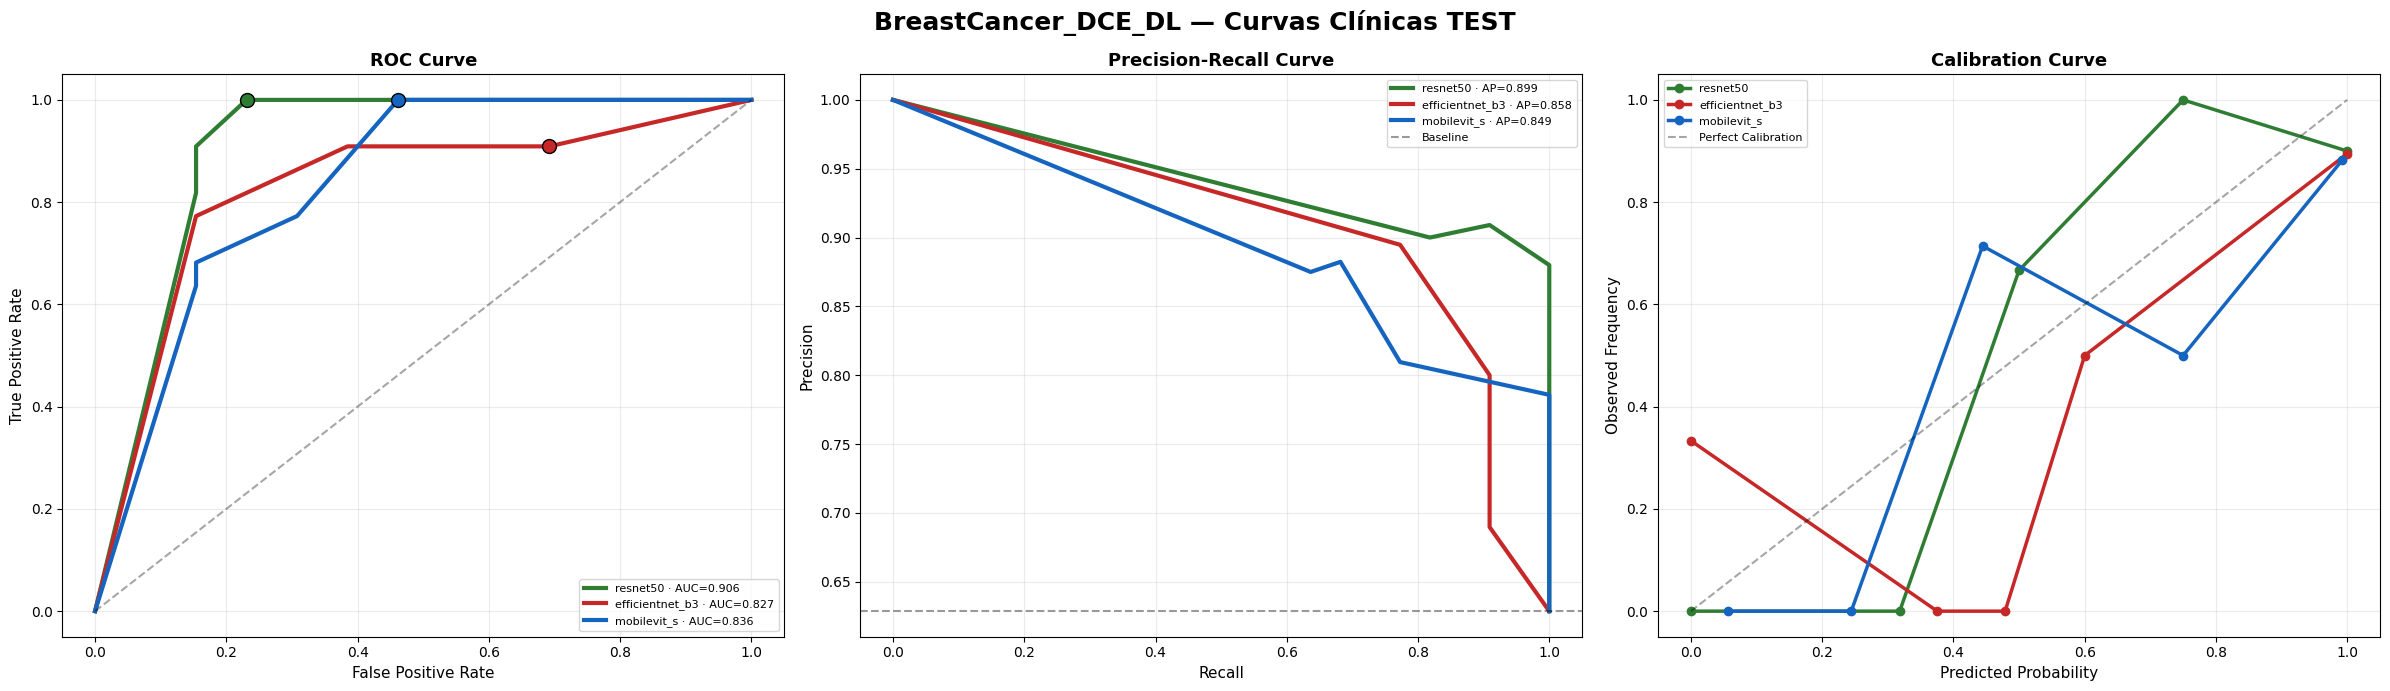


✅ FIG 1 guardada:
   /workspace/breast-cancer-dce-mri-classification/BreastCancer_DCE_DL_v6/experiments/exp-VF/evidencias/figures/fig1_curvas_clinicas.png


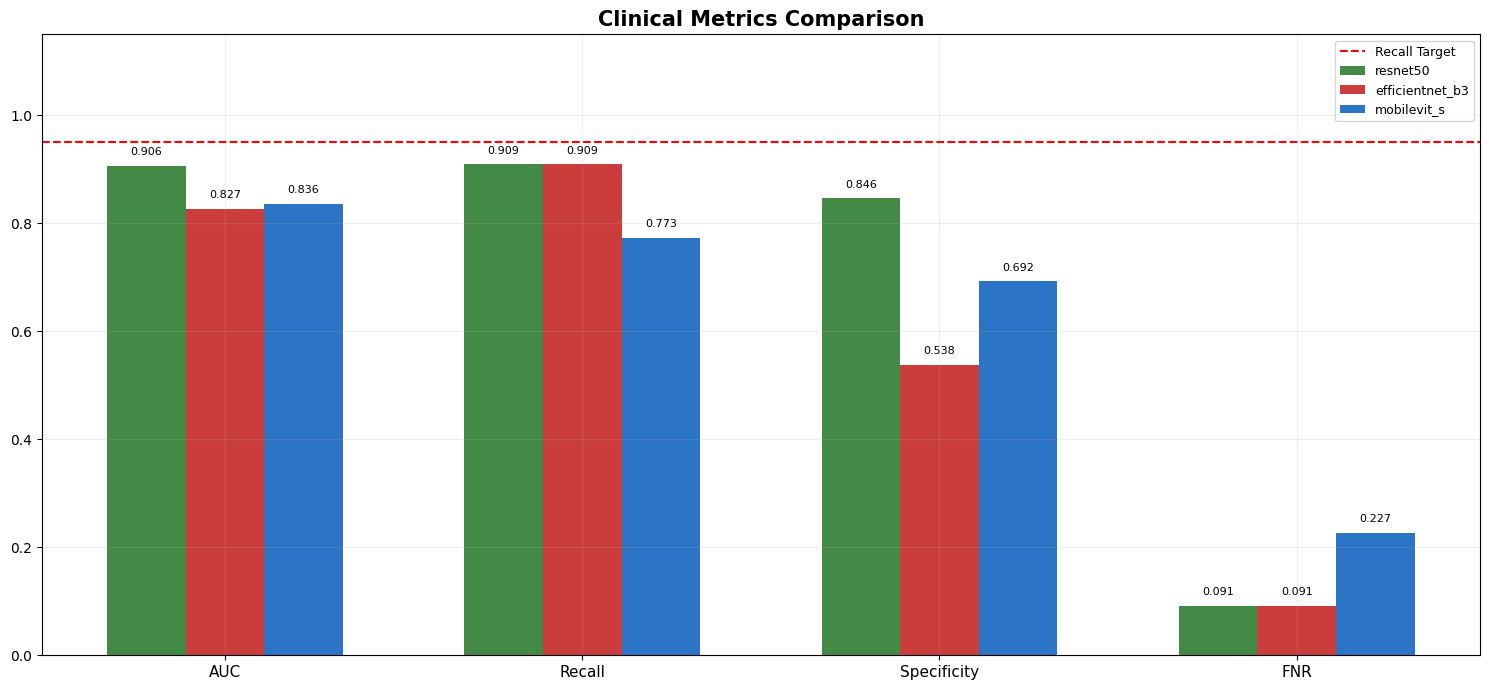


✅ FIG 2 guardada:
   /workspace/breast-cancer-dce-mri-classification/BreastCancer_DCE_DL_v6/experiments/exp-VF/evidencias/figures/fig2_metricas.png


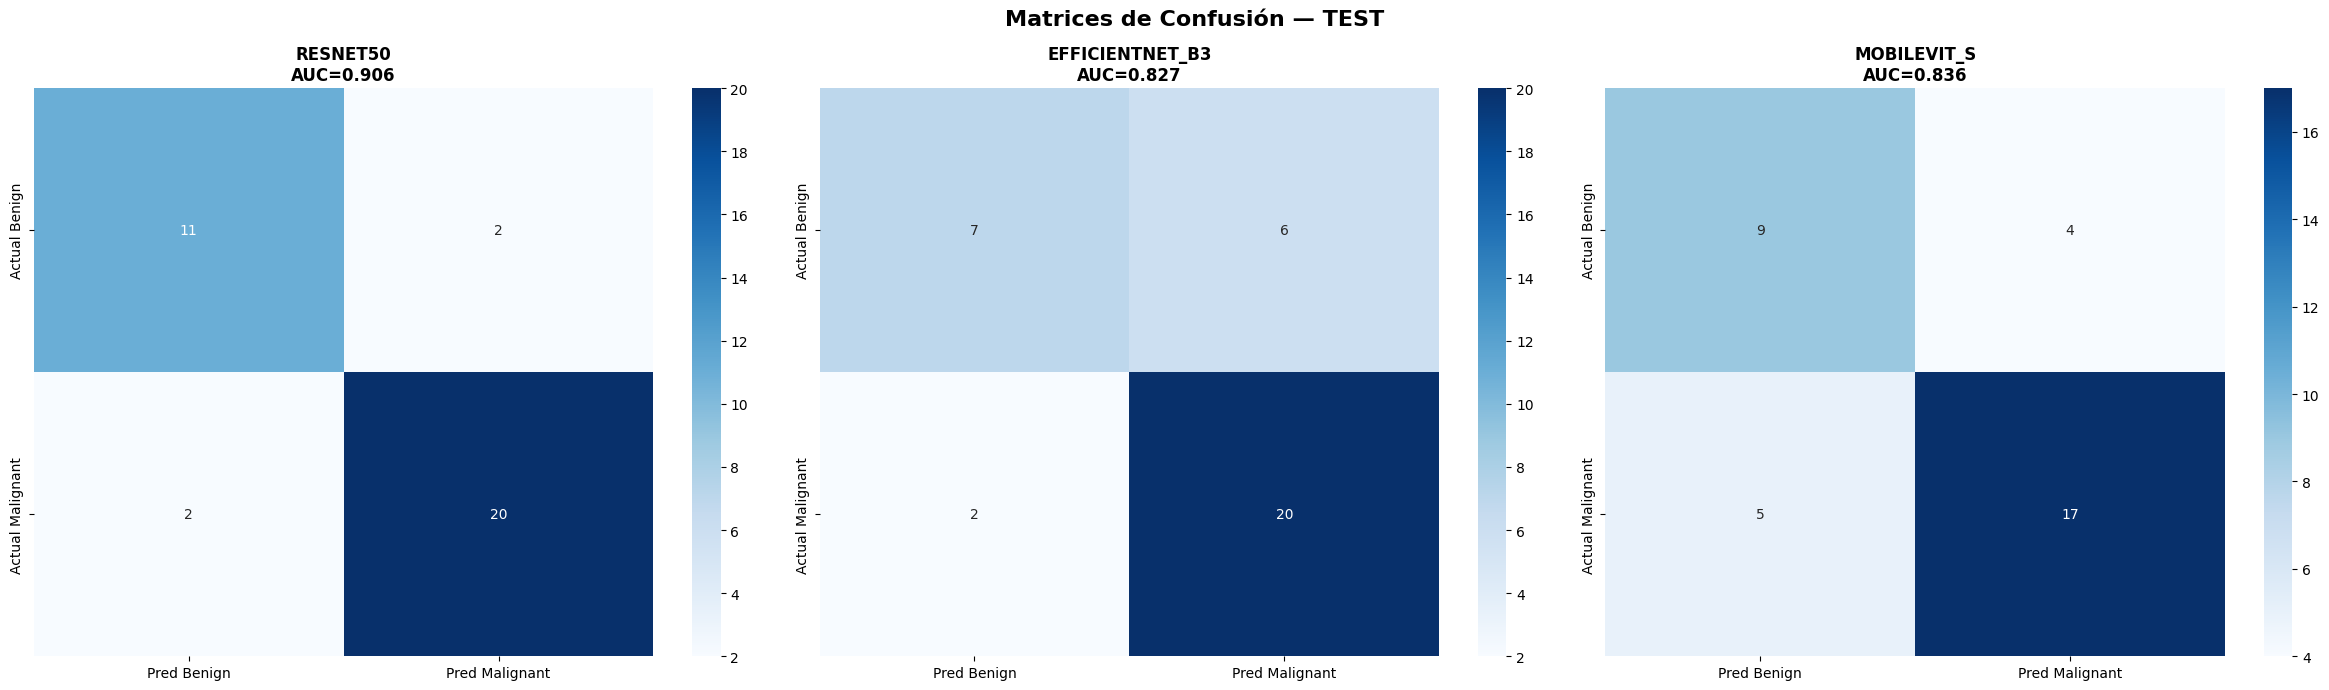


✅ FIG 3 guardada:
   /workspace/breast-cancer-dce-mri-classification/BreastCancer_DCE_DL_v6/experiments/exp-VF/evidencias/figures/fig3_confusion.png


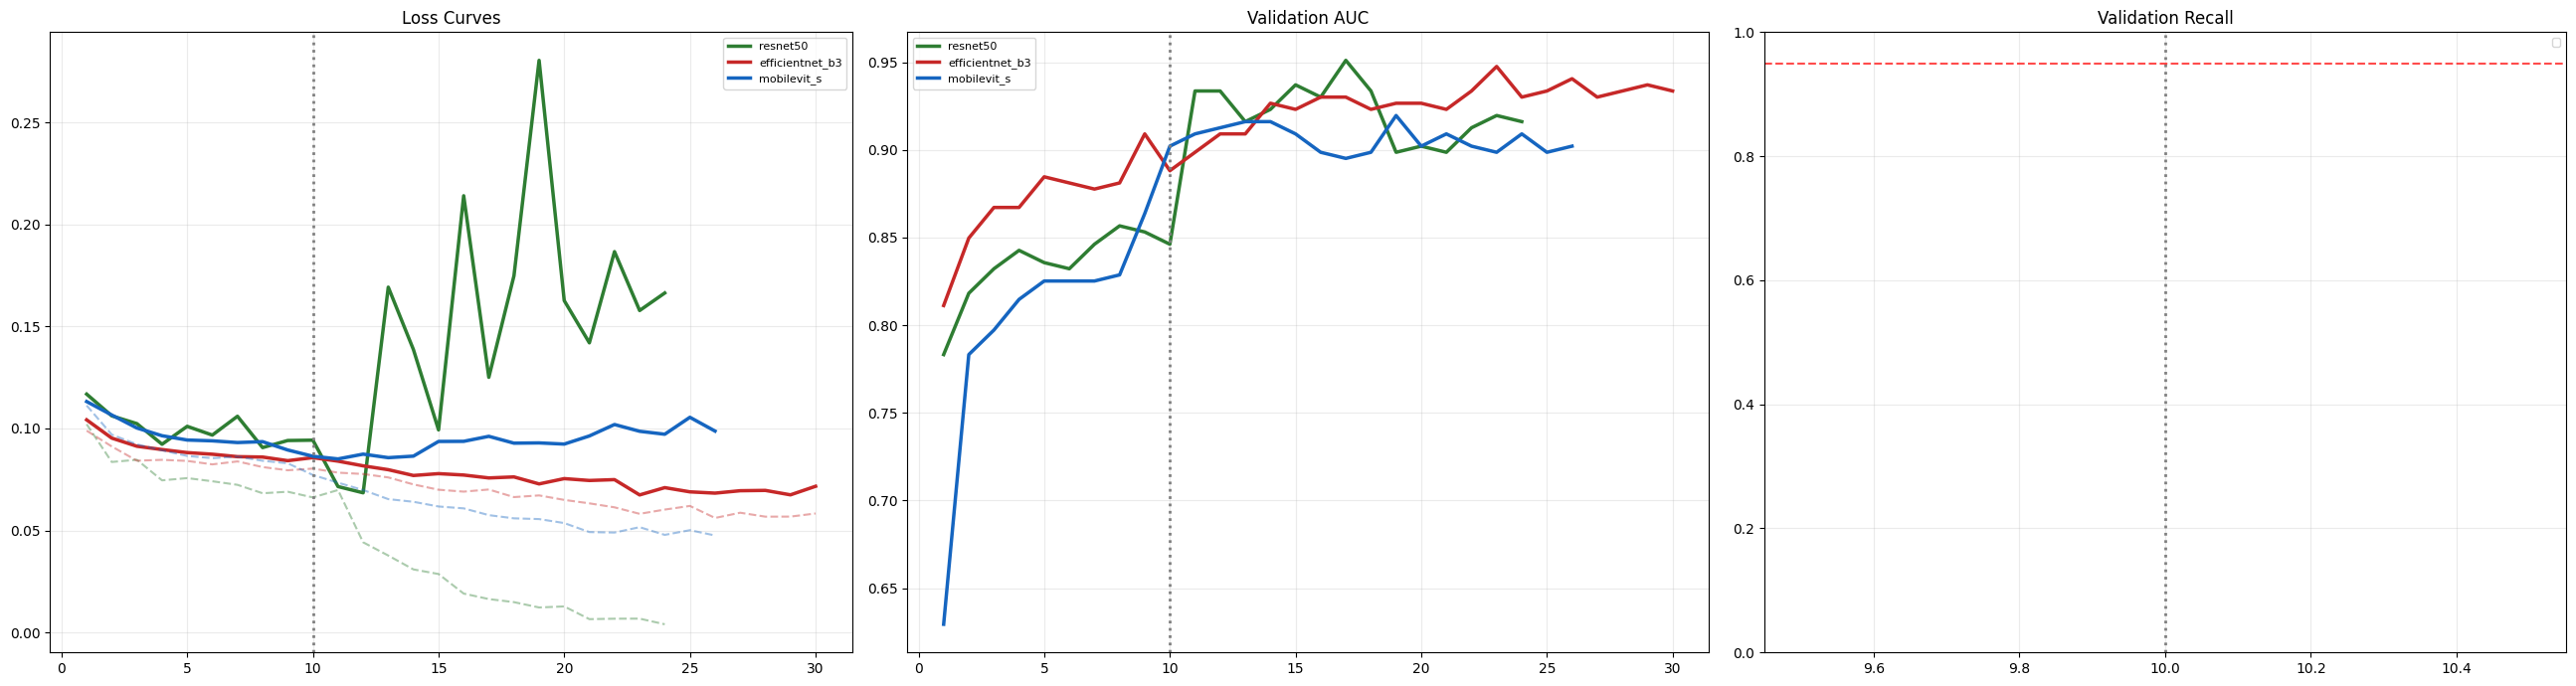


✅ FIG 4 guardada:
   /workspace/breast-cancer-dce-mri-classification/BreastCancer_DCE_DL_v6/experiments/exp-VF/evidencias/figures/fig4_training.png

════════════════════════════════════════════════════════════════════════════════
✅ BLOQUE 16 COMPLETADO
════════════════════════════════════════════════════════════════════════════════


In [22]:
# ═══════════════════════════════════════════════════════════════════
# BLOQUE 16 — VISUALIZACIONES CLÍNICAS COMPLETAS V6
# CORREGIDO FINAL · HOLDOUT 70/15/15 · CALIBRATED TEST
# ═══════════════════════════════════════════════════════════════════

import seaborn as sns

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

from sklearn.calibration import calibration_curve

print("\n" + "═" * 80)

print("📊 VISUALIZACIONES CLÍNICAS V6")

print("═" * 80)

# ═══════════════════════════════════════════════════════════════════
# VALIDACIÓN CONTENEDORES
# ═══════════════════════════════════════════════════════════════════

required_objects = [

    "baseline_metrics",

    "baseline_probs",

    "baseline_labels",

    "baseline_histories"
]

missing_objects = [

    obj

    for obj in required_objects

    if obj not in globals()
]

if len(missing_objects) > 0:

    raise RuntimeError(
        f"""
❌ Faltan contenedores necesarios:

{missing_objects}

⚠️ Ejecuta nuevamente BLOQUE 14.2
después de agregar baseline_probs,
baseline_labels y baseline_predictions.
"""
    )

# ═══════════════════════════════════════════════════════════════════
# PALETTE
# ═══════════════════════════════════════════════════════════════════

PALETTE = {

    'resnet50'       : '#2E7D32',

    'efficientnet_b3': '#C62828',

    'mobilevit_s'    : '#1565C0',
}

# ═══════════════════════════════════════════════════════════════════
# MODELOS DISPONIBLES
# ═══════════════════════════════════════════════════════════════════

archs = list(

    baseline_metrics.keys()
)

print(
    f"\n📊 Modelos disponibles para gráficas:\n"
    f"   {archs}"
)

if len(archs) == 0:

    raise ValueError(
        '❌ No hay modelos en baseline_metrics'
    )

# ═══════════════════════════════════════════════════════════════════
# LABELS REFERENCIA
# ═══════════════════════════════════════════════════════════════════

labels_ref = None

for arch in archs:

    if (
        arch in baseline_labels
        and baseline_labels[arch] is not None
    ):

        labels_ref = np.array(
            baseline_labels[arch]
        )

        break

if labels_ref is None:

    raise ValueError(
        "❌ No existen labels válidos"
    )

# ═══════════════════════════════════════════════════════════════════
# FIGURES DIR
# ═══════════════════════════════════════════════════════════════════

FIGURES_DIR = (

    EVIDENCIAS_DIR /

    "figures"
)

FIGURES_DIR.mkdir(

    parents=True,

    exist_ok=True
)

# ═══════════════════════════════════════════════════════════════════
# EPOCHS FROZEN
# ═══════════════════════════════════════════════════════════════════

epochs_frozen = 10

# ═══════════════════════════════════════════════════════════════════
# FIG 1 — ROC · PR · CALIBRATION
# ═══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(

    1,

    3,

    figsize=(24, 7)
)

fig.suptitle(

    f'{PROYECTO} — Curvas Clínicas TEST',

    fontsize=18,

    fontweight='bold'
)

prevalence = labels_ref.mean()

for idx, arch in enumerate(archs):

    probs = baseline_probs.get(arch)

    if probs is None:

        continue

    probs = np.array(probs)

    c = PALETTE.get(
        arch,
        'black'
    )

    lbl = arch

    # ============================================================
    # ROC
    # ============================================================

    fpr_c, tpr_c, thr_c = roc_curve(

        labels_ref,

        probs
    )

    auc = roc_auc_score(

        labels_ref,

        probs
    )

    axes[0].plot(

        fpr_c,

        tpr_c,

        lw=3,

        color=c,

        label=f'{lbl} · AUC={auc:.3f}'
    )

    threshold = baseline_metrics[
        arch
    ].get(
        "Threshold",
        0.5
    )

    idx_thr = np.argmin(
        np.abs(thr_c - threshold)
    )

    x_thr = fpr_c[idx_thr]

    y_thr = tpr_c[idx_thr]

    axes[0].scatter(

        x_thr,

        y_thr,

        color=c,

        s=100,

        edgecolor='black',

        zorder=5
    )

    # ============================================================
    # PR
    # ============================================================

    p, r, pr_thr = precision_recall_curve(

        labels_ref,

        probs
    )

    ap = average_precision_score(

        labels_ref,

        probs
    )

    axes[1].plot(

        r,

        p,

        lw=3,

        color=c,

        label=f'{lbl} · AP={ap:.3f}'
    )

    # ============================================================
    # CALIBRATION
    # ============================================================

    fraction, mean_pred = calibration_curve(

        labels_ref,

        probs,

        n_bins=5
    )

    axes[2].plot(

        mean_pred,

        fraction,

        'o-',

        lw=2.5,

        color=c,

        label=lbl
    )

# ═══════════════════════════════════════════════════════════════════
# ROC STYLE
# ═══════════════════════════════════════════════════════════════════

axes[0].plot(
    [0,1],
    [0,1],
    'k--',
    alpha=0.35
)

axes[0].set_title(
    'ROC Curve',
    fontsize=13,
    fontweight='bold'
)

axes[0].set_xlabel(
    'False Positive Rate',
    fontsize=11
)

axes[0].set_ylabel(
    'True Positive Rate',
    fontsize=11
)

axes[0].legend(fontsize=8)

axes[0].grid(alpha=0.25)

# ═══════════════════════════════════════════════════════════════════
# PR STYLE
# ═══════════════════════════════════════════════════════════════════

axes[1].axhline(

    y=prevalence,

    color='black',

    ls='--',

    alpha=0.4,

    label='Baseline'
)

axes[1].set_title(
    'Precision-Recall Curve',
    fontsize=13,
    fontweight='bold'
)

axes[1].set_xlabel(
    'Recall',
    fontsize=11
)

axes[1].set_ylabel(
    'Precision',
    fontsize=11
)

axes[1].legend(fontsize=8)

axes[1].grid(alpha=0.25)

# ═══════════════════════════════════════════════════════════════════
# CALIBRATION STYLE
# ═══════════════════════════════════════════════════════════════════

axes[2].plot(
    [0,1],
    [0,1],
    'k--',
    alpha=0.35,
    label='Perfect Calibration'
)

axes[2].set_title(
    'Calibration Curve',
    fontsize=13,
    fontweight='bold'
)

axes[2].set_xlabel(
    'Predicted Probability',
    fontsize=11
)

axes[2].set_ylabel(
    'Observed Frequency',
    fontsize=11
)

axes[2].legend(fontsize=8)

axes[2].grid(alpha=0.25)

plt.tight_layout()

fig1_path = (

    FIGURES_DIR /

    'fig1_curvas_clinicas.png'
)

plt.savefig(

    fig1_path,

    dpi=220,

    bbox_inches='tight'
)

plt.show()

print(
    f'\n✅ FIG 1 guardada:\n'
    f'   {fig1_path}'
)

# ═══════════════════════════════════════════════════════════════════
# FIG 2 — MÉTRICAS CLÍNICAS
# ═══════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(
    figsize=(15, 7)
)

met_keys = [

    'AUC_ROC',

    'Sensitivity_Recall',

    'Specificity',

    'FNR'
]

met_names = [

    'AUC',

    'Recall',

    'Specificity',

    'FNR'
]

x = np.arange(
    len(met_keys)
)

w = 0.22

for i, arch in enumerate(archs):

    vals = []

    for k in met_keys:

        vals.append(

            baseline_metrics[arch].get(
                k,
                0
            )
        )

    bars = ax.bar(

        x + i*w,

        vals,

        w,

        label=arch,

        color=PALETTE.get(
            arch,
            'gray'
        ),

        alpha=0.9
    )

    for bar, val in zip(bars, vals):

        ax.text(

            bar.get_x() + bar.get_width()/2,

            bar.get_height() + 0.02,

            f'{val:.3f}',

            ha='center',

            fontsize=8
        )

ax.axhline(

    0.95,

    color='red',

    ls='--',

    lw=1.5,

    label='Recall Target'
)

ax.set_xticks(
    x + w
)

ax.set_xticklabels(
    met_names,
    fontsize=11
)

ax.set_ylim(0, 1.15)

ax.set_title(
    'Clinical Metrics Comparison',
    fontsize=15,
    fontweight='bold'
)

ax.legend(fontsize=9)

ax.grid(alpha=0.2)

plt.tight_layout()

fig2_path = (

    FIGURES_DIR /

    'fig2_metricas.png'
)

plt.savefig(

    fig2_path,

    dpi=220,

    bbox_inches='tight'
)

plt.show()

print(
    f'\n✅ FIG 2 guardada:\n'
    f'   {fig2_path}'
)

# ═══════════════════════════════════════════════════════════════════
# FIG 3 — MATRICES DE CONFUSIÓN
# ═══════════════════════════════════════════════════════════════════

n = len(archs)

fig, axes = plt.subplots(

    1,

    n,

    figsize=(8*n, 7)
)

if n == 1:

    axes = [axes]

fig.suptitle(

    'Matrices de Confusión — TEST',

    fontsize=16,

    fontweight='bold'
)

for ax, arch in zip(axes, archs):

    m_a = baseline_metrics[arch]

    tn = m_a.get('TN', 0)
    fp = m_a.get('FP', 0)
    fn = m_a.get('FN', 0)
    tp = m_a.get('TP', 0)

    cm_ = np.array([

        [tn, fp],

        [fn, tp]
    ])

    sns.heatmap(

        cm_,

        annot=True,

        fmt='d',

        cmap='Blues',

        ax=ax,

        xticklabels=['Pred Benign', 'Pred Malignant'],

        yticklabels=['Actual Benign', 'Actual Malignant']
    )

    ax.set_title(

        f'{arch.upper()}\n'

        f'AUC={m_a.get("AUC_ROC",0):.3f}',

        fontsize=12,

        fontweight='bold'
    )

plt.tight_layout()

fig3_path = (

    FIGURES_DIR /

    'fig3_confusion.png'
)

plt.savefig(

    fig3_path,

    dpi=220,

    bbox_inches='tight'
)

plt.show()

print(
    f'\n✅ FIG 3 guardada:\n'
    f'   {fig3_path}'
)

# ═══════════════════════════════════════════════════════════════════
# FIG 4 — TRAINING CURVES
# ═══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(

    1,

    3,

    figsize=(26, 7)
)

for arch in archs:

    if arch not in baseline_histories:

        continue

    hist = baseline_histories[arch]

    c = PALETTE.get(
        arch,
        'black'
    )

    train_loss = hist.get(
        'train_loss',
        []
    )

    val_loss = hist.get(
        'val_loss',
        []
    )

    val_auc = hist.get(
        'val_auc_patient',
        []
    )

    val_recall = hist.get(
        'val_recall_patient',
        []
    )

    ep = range(
        1,
        len(val_auc) + 1
    )

    if len(train_loss) > 0:

        axes[0].plot(

            range(1, len(train_loss)+1),

            train_loss,

            '--',

            color=c,

            alpha=0.4
        )

    if len(val_loss) > 0:

        axes[0].plot(

            range(1, len(val_loss)+1),

            val_loss,

            color=c,

            lw=2.5,

            label=arch
        )

    if len(val_auc) > 0:

        axes[1].plot(

            ep,

            val_auc,

            color=c,

            lw=2.5,

            label=arch
        )

    if len(val_recall) > 0:

        axes[2].plot(

            range(1, len(val_recall)+1),

            val_recall,

            color=c,

            lw=2.5,

            label=arch
        )

for ax in axes:

    ax.axvline(

        epochs_frozen,

        color='gray',

        ls=':',

        lw=2
    )

    ax.grid(alpha=0.25)

    ax.legend(fontsize=8)

axes[0].set_title('Loss Curves')

axes[1].set_title('Validation AUC')

axes[2].set_title('Validation Recall')

axes[2].axhline(

    0.95,

    color='red',

    ls='--',

    alpha=0.7
)

plt.tight_layout()

fig4_path = (

    FIGURES_DIR /

    'fig4_training.png'
)

plt.savefig(

    fig4_path,

    dpi=220,

    bbox_inches='tight'
)

plt.show()

print(
    f'\n✅ FIG 4 guardada:\n'
    f'   {fig4_path}'
)

print("\n" + "═" * 80)

print("✅ BLOQUE 16 COMPLETADO")

print("═" * 80)

<class 'dict'>
dict_keys(['resnet50', 'efficientnet_b3', 'mobilevit_s'])

✅ Figura guardada → /workspace/breast-cancer-dce-mri-classification/experimento/figuras/training_dynamics.png


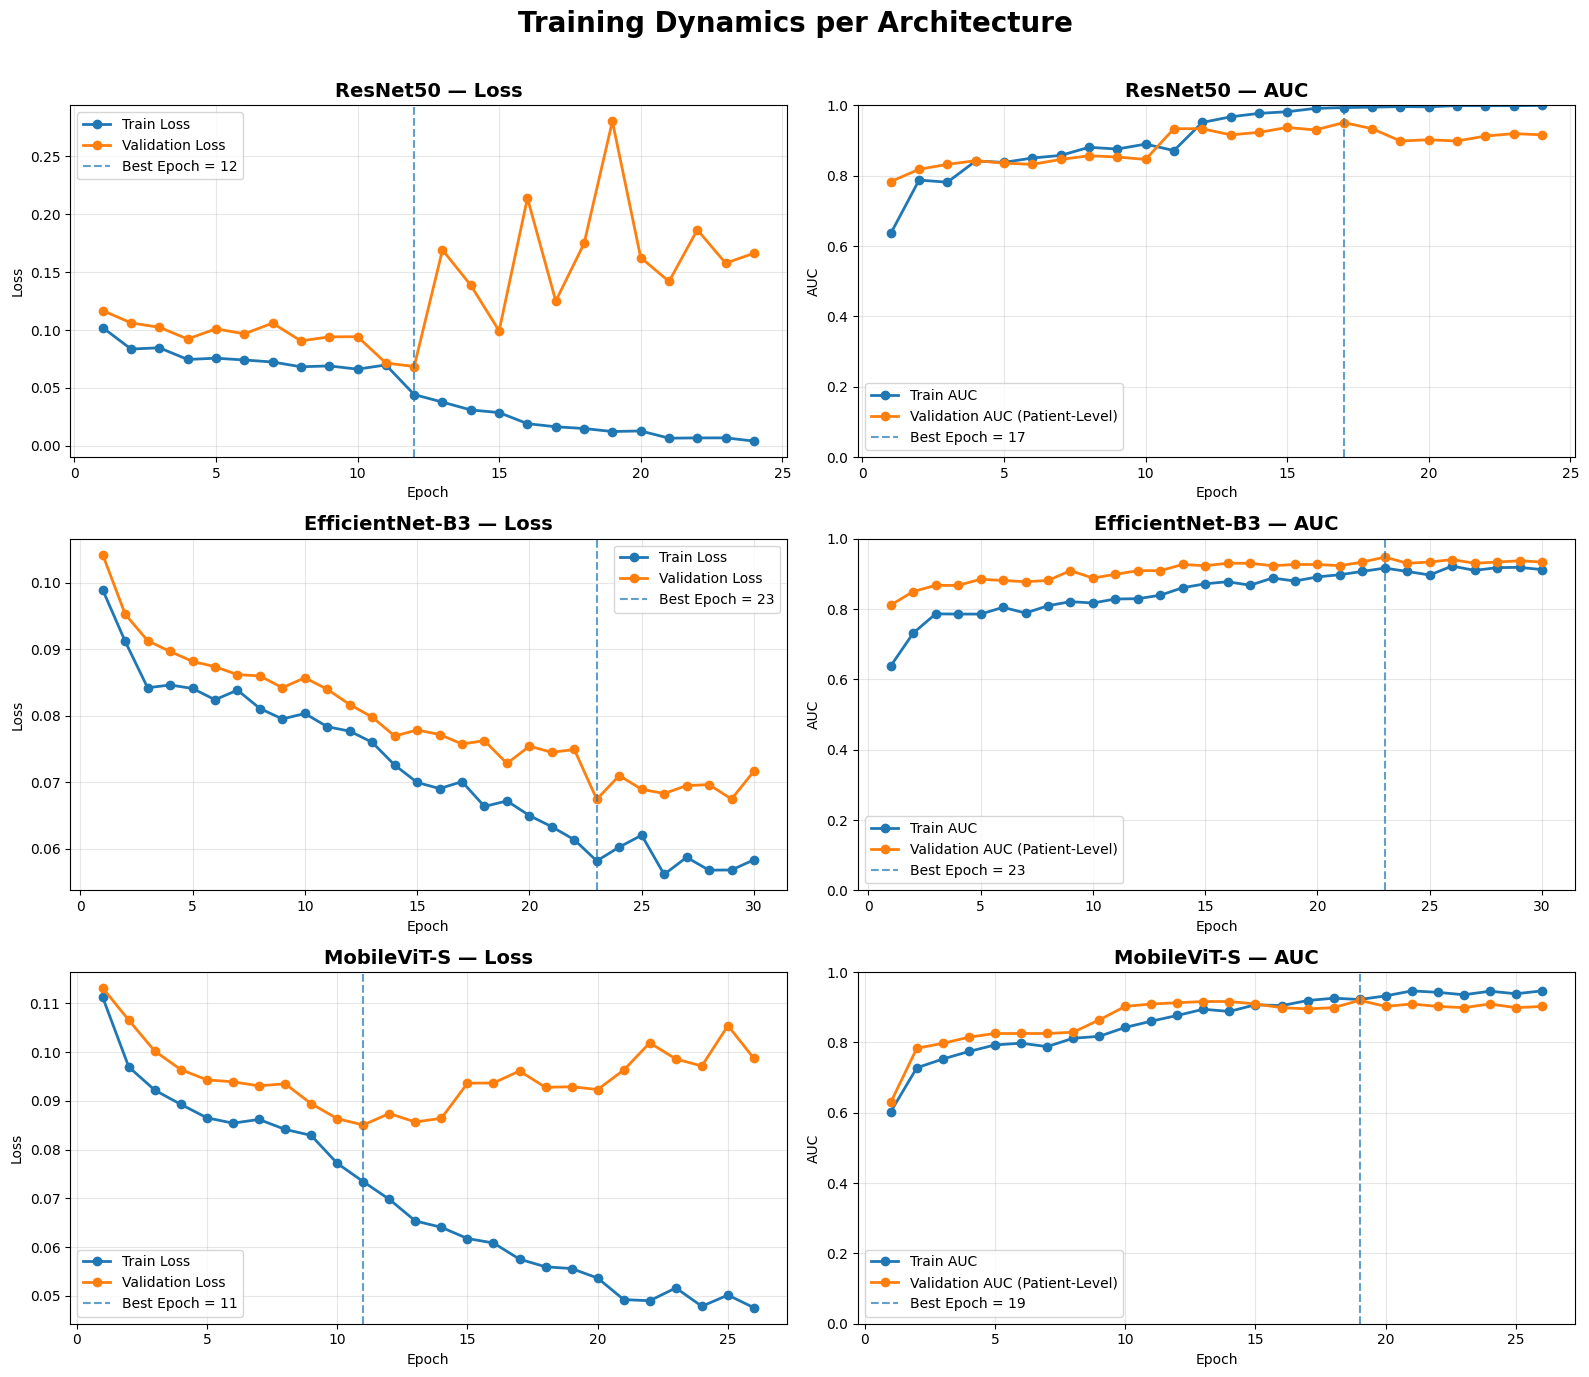

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ============================================================
# RUTA DE GUARDADO — apunta al repo nuevo
# ============================================================

FIGURES_DIR = Path(
    "/workspace/breast-cancer-dce-mri-classification"
    "/experimento/figuras"
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SAVE_PATH = FIGURES_DIR / "training_dynamics.png"

# ============================================================
# CONFIGURACIÓN
# ============================================================

MODELS = [
    "resnet50",
    "efficientnet_b3",
    "mobilevit_s"
]

TITLES = {
    "resnet50":        "ResNet50",
    "efficientnet_b3": "EfficientNet-B3",
    "mobilevit_s":     "MobileViT-S"
}

# ============================================================
# VERIFICACIÓN
# ============================================================

print(type(histories))
print(histories.keys())

# ============================================================
# FIGURA PRINCIPAL
# ============================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(16, 14)
)

fig.suptitle(
    "Training Dynamics per Architecture",
    fontsize=20,
    fontweight="bold"
)

# ============================================================
# LOOP PRINCIPAL
# ============================================================

for row, model_name in enumerate(MODELS):

    history = histories[model_name]

    train_loss = history["train_loss"]
    val_loss   = history["val_loss"]
    train_auc  = history["train_auc"]
    val_auc    = history["val_auc_patient"]

    epochs = np.arange(1, len(train_loss) + 1)

    # ── LOSS ─────────────────────────────────────────────────

    ax_loss = axes[row, 0]

    ax_loss.plot(epochs, train_loss, marker="o", linewidth=2, label="Train Loss")
    ax_loss.plot(epochs, val_loss,   marker="o", linewidth=2, label="Validation Loss")

    best_epoch_loss = np.argmin(val_loss)
    ax_loss.axvline(
        x=epochs[best_epoch_loss],
        linestyle="--",
        alpha=0.7,
        label=f"Best Epoch = {epochs[best_epoch_loss]}"
    )

    ax_loss.set_title(f"{TITLES[model_name]} — Loss", fontsize=14, fontweight="bold")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.grid(True, alpha=0.3)
    ax_loss.legend()

    # ── AUC ──────────────────────────────────────────────────

    ax_auc = axes[row, 1]

    ax_auc.plot(epochs, train_auc, marker="o", linewidth=2, label="Train AUC")
    ax_auc.plot(epochs, val_auc,   marker="o", linewidth=2, label="Validation AUC (Patient-Level)")

    best_epoch_auc = np.argmax(val_auc)
    ax_auc.axvline(
        x=epochs[best_epoch_auc],
        linestyle="--",
        alpha=0.7,
        label=f"Best Epoch = {epochs[best_epoch_auc]}"
    )

    ax_auc.set_title(f"{TITLES[model_name]} — AUC", fontsize=14, fontweight="bold")
    ax_auc.set_xlabel("Epoch")
    ax_auc.set_ylabel("AUC")
    ax_auc.set_ylim(0.0, 1.0)
    ax_auc.grid(True, alpha=0.3)
    ax_auc.legend()

# ============================================================
# GUARDAR + MOSTRAR
# ============================================================

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(
    SAVE_PATH,
    dpi=150,
    bbox_inches="tight"
)

print(f"\n✅ Figura guardada → {SAVE_PATH}")

plt.show()

# ════════════════════════════════════════════════════════════════════════
# 📊 BLOQUE 17 — DASHBOARD CLÍNICO COMPARATIVO FINAL
# EVALUACIÓN PATIENT-WISE EN TEST SET
# ════════════════════════════════════════════════════════════════════════

## 🎯 Objetivo

Este bloque genera un dashboard clínico comparativo consolidado para analizar el desempeño diagnóstico final de las arquitecturas profundas evaluadas en el proyecto:

- ResNet50
- EfficientNet-B3
- MobileViT-S

El análisis se realiza exclusivamente sobre el conjunto TEST patient-wise, utilizando probabilidades finales y thresholds clínicos previamente seleccionados durante validation, evitando contaminación metodológica del test set.

---

# 🧠 Evaluación Clínica Final

El dashboard integra múltiples métricas clínicas y curvas diagnósticas para evaluar:

- capacidad discriminativa,
- sensibilidad clínica,
- especificidad,
- calibración probabilística,
- robustez diagnóstica,
- comportamiento bajo desbalance,
- y tradeoffs clínicos entre falsos positivos y falsos negativos.

---

# 📌 Componentes del Dashboard

## 📈 Métricas Clínicas

Se comparan métricas fundamentales para clasificación médica:

| Métrica | Interpretación Clínica |
|---|---|
| AUC-ROC | Discriminación global |
| PR-AUC | Robustez bajo desbalance |
| Recall / Sensitivity | Capacidad de detectar malignos |
| Specificity | Identificación correcta de benignos |
| Precision (PPV) | Confiabilidad de predicción positiva |
| NPV | Confiabilidad de predicción negativa |
| F1-Score | Balance entre recall y precisión |
| Balanced Accuracy | Accuracy balanceado |
| Brier Score | Calidad de calibración probabilística |
| FNR | Riesgo de falsos negativos |
| Threshold | Punto clínico de decisión |

---

# 📉 ROC Curve

La curva ROC permite visualizar:

- sensibilidad vs falsos positivos,
- comportamiento discriminativo global,
- y posición clínica del threshold seleccionado.

Cada modelo incluye:

- curva ROC individual,
- AUC correspondiente,
- y marcador explícito del threshold clínico final.

---

# 📊 Precision–Recall Curve

La curva Precision–Recall es especialmente relevante en datasets médicos desbalanceados, permitiendo analizar:

- sensibilidad clínica,
- estabilidad diagnóstica,
- y precisión bajo prevalencias reducidas.

---

# 🧪 Calibration Curve

La curva de calibración evalúa la correspondencia entre:

- probabilidades predichas,
- y frecuencia observada real.

Esto permite analizar si el modelo:

- sobreestima riesgo,
- subestima malignidad,
- o presenta comportamiento probabilísticamente confiable.

---

# 🧬 Evaluación Patient-Wise

Todas las métricas mostradas en este dashboard corresponden a evaluación patient-wise sobre TEST set.

Esto garantiza que:

- cada paciente contribuya una única vez,
- no exista leakage entre slices,
- y la evaluación represente un escenario clínico más realista.

---

# ⚠️ Consideraciones Metodológicas

## Threshold Clínico

Los thresholds utilizados en evaluación final fueron seleccionados previamente sobre validation set, evitando optimización sobre test.

Esto asegura:

✅ evaluación honesta  
✅ separación metodológica correcta  
✅ ausencia de contaminación experimental  

---

## Importancia del Recall

En clasificación de cáncer de mama, minimizar falsos negativos es prioritario clínicamente.

Por esta razón:

- Recall (Sensitivity) adquiere especial relevancia,
- y se analiza explícitamente el cumplimiento del target clínico:

```text
Recall ≥ 0.95
```

---

# 🏆 Interpretación Clínica Esperada

## ResNet50

Arquitectura orientada a:

- mejor equilibrio global,
- estabilidad diagnóstica,
- y balance clínico entre sensibilidad y especificidad.

---

## EfficientNet-B3

Arquitectura orientada a:

- máxima sensibilidad,
- minimización de falsos negativos,
- y escenarios de screening clínico.

---

## MobileViT-S

Arquitectura orientada a:

- alta especificidad,
- reducción de falsos positivos,
- y comportamiento más conservador.

---

# 📌 Importancia del Dashboard

Este dashboard permite:

- comparar arquitecturas profundas de manera integrada,
- visualizar tradeoffs clínicos reales,
- analizar comportamiento diagnóstico completo,
- y facilitar interpretación médica y académica durante sustentación y discusión de resultados.

---

# ✅ Resultado Esperado

Al finalizar este bloque se obtiene:

- dashboard clínico consolidado,
- curvas diagnósticas finales,
- comparación patient-wise entre modelos,
- y visualización integral del desempeño clínico final del experimento.
# ════════════════════════════════════════════════════════════════════════
```

In [24]:
print("\n🧪 DEBUG CONTENEDORES\n")

print("all_metrics:")
print(type(all_metrics))
print(all_metrics.keys())

print("\nall_probs:")
print(type(all_probs))
print(all_probs.keys())

print("\nall_labels:")
print(type(all_labels))
print(all_labels.keys())


🧪 DEBUG CONTENEDORES

all_metrics:
<class 'dict'>
dict_keys(['resnet50', 'efficientnet_b3', 'mobilevit_s'])

all_probs:
<class 'dict'>
dict_keys(['resnet50', 'efficientnet_b3', 'mobilevit_s'])

all_labels:
<class 'dict'>
dict_keys(['resnet50', 'efficientnet_b3', 'mobilevit_s'])



📂 SAVE_DIR:
   /workspace/breast-cancer-dce-mri-classification/BreastCancer_DCE_DL_v6/experiments/exp-VF/evidencias

✅ Modelos válidos:
   ['resnet50', 'efficientnet_b3', 'mobilevit_s']

📋 Criterio de evaluación por métrica:

• AUC-ROC            ↑ mayor    Discriminación global
• PR-AUC             ↑ mayor    Performance bajo desbalance
• Recall             ↑ mayor    Sensibilidad clínica
• Specificity        ↑ mayor    Identificación benignos
• Precision(PPV)     ↑ mayor    Precisión malignidad
• NPV                ↑ mayor    Confiabilidad negativos
• F1-Score           ↑ mayor    Balance clínico
• Balanced Acc       ↑ mayor    Accuracy balanceado
• Brier Score        ↓ menor    Error calibración
• FNR                ↓ menor    Falsos negativos
• Threshold          contexto   Threshold clínico

✅ Dashboard guardado → /workspace/breast-cancer-dce-mri-classification/BreastCancer_DCE_DL_v6/experiments/exp-VF/evidencias/fig_dashboard_comparativo.png


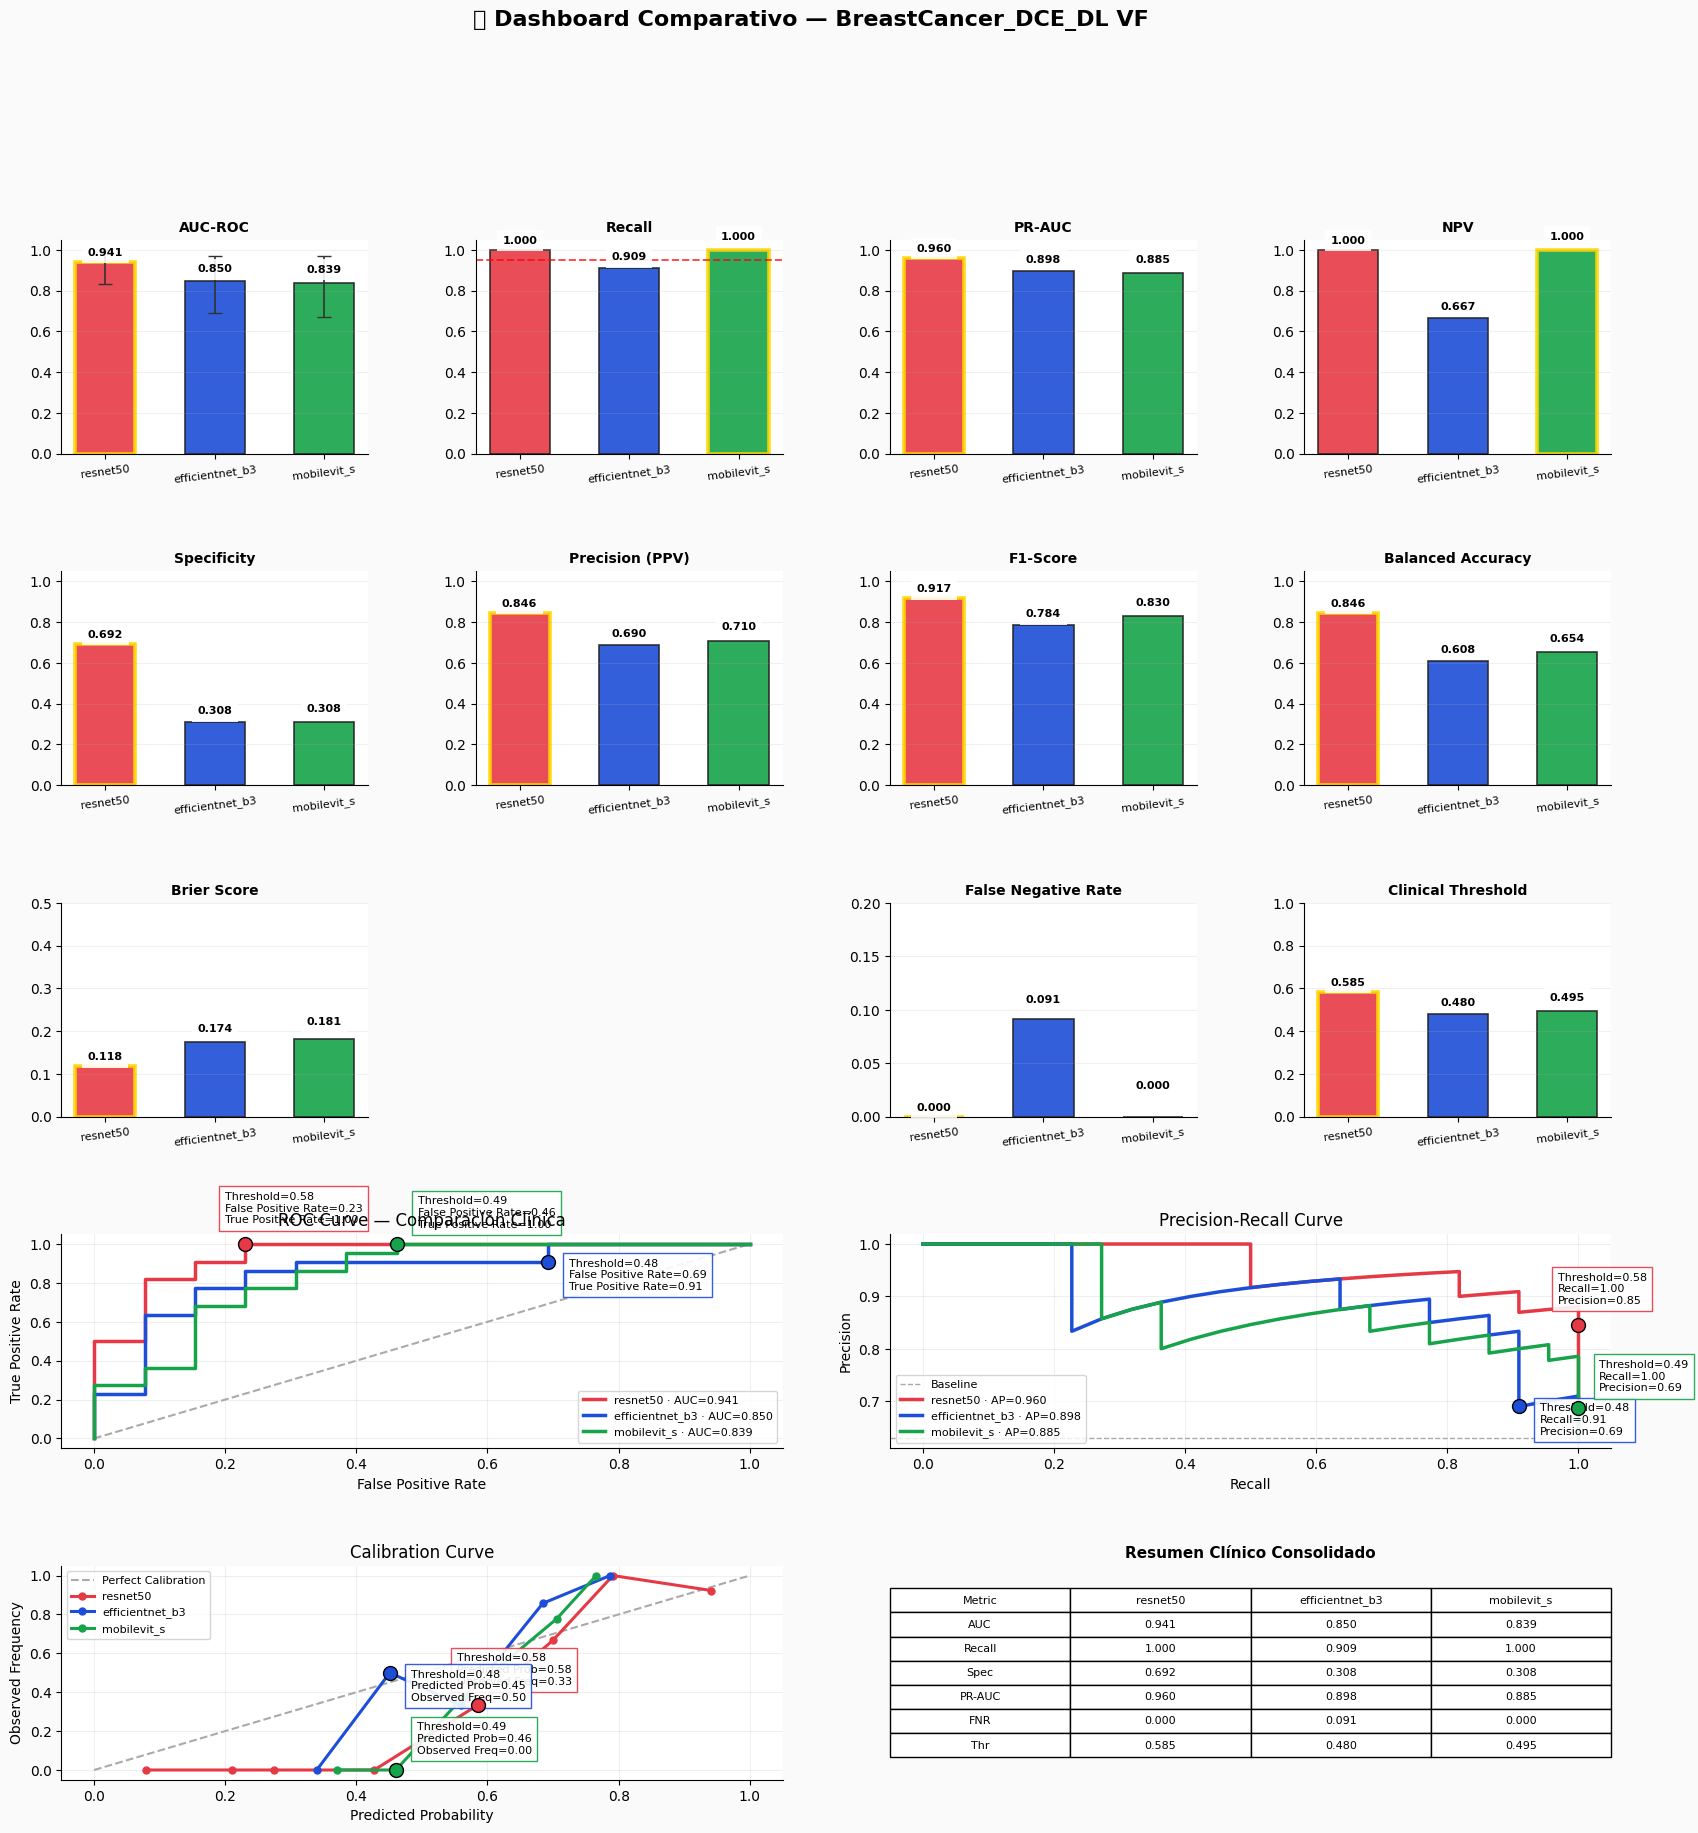


════════════════════════════════════════════════════════════════════════════════
✅ DASHBOARD COMPARATIVO GENERADO
════════════════════════════════════════════════════════════════════════════════


In [25]:
# ════════════════════════════════════════════════════════════════════
# DASHBOARD COMPARATIVO CLÍNICO V6 — FINAL CONSOLIDADO
# TESIS / PAPER QUALITY
# ════════════════════════════════════════════════════════════════════

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import seaborn as sns
import warnings

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════════════════
# PALETA
# ════════════════════════════════════════════════════════════════════

MODEL_COLORS = {

    'resnet50'       : '#E63946',

    'efficientnet_b3': '#1D4ED8',

    'mobilevit_s'    : '#16A34A',
}

# ════════════════════════════════════════════════════════════════════
# HELPERS
# ════════════════════════════════════════════════════════════════════

def _parse_ci(ci_str):

    try:

        if ci_str is None:

            return None, None

        if isinstance(ci_str, (list, tuple)):

            if len(ci_str) == 2:

                return (
                    float(ci_str[0]),
                    float(ci_str[1])
                )

        parts = str(ci_str).strip('[]').split(',')

        return (
            float(parts[0]),
            float(parts[1])
        )

    except Exception:

        return None, None


# ════════════════════════════════════════════════════════════════════
# OFFSETS ANTI-OVERLAP
# ════════════════════════════════════════════════════════════════════

OFFSETS = {

    0: (-15, 15),

    1: (15, -20),

    2: (15, 12)
}

# ════════════════════════════════════════════════════════════════════
# BARPLOT ROBUSTO
# ════════════════════════════════════════════════════════════════════

def _bar_metric(

    ax,

    metrics_dict,

    key,

    title,

    higher_is_better=True,

    ylim=(0,1.05),

    ci_key=None,

    threshold_line=None
):

    names = list(metrics_dict.keys())

    values = [

        metrics_dict[n].get(
            key,
            np.nan
        )

        for n in names
    ]

    colors = [

        MODEL_COLORS.get(
            n,
            '#888'
        )

        for n in names
    ]

    yerr_lo = np.zeros(len(names))
    yerr_hi = np.zeros(len(names))

    has_ci = False

    # ═══════════════════════════════════════════════════════════════
    # CI95
    # ═══════════════════════════════════════════════════════════════

    if ci_key:

        for i, n in enumerate(names):

            lo, hi = _parse_ci(

                metrics_dict[n].get(
                    ci_key,
                    '[nan,nan]'
                )
            )

            val = values[i]

            if (
                lo is not None
                and hi is not None
                and not np.isnan(val)
            ):

                err_lo = max(
                    0,
                    val - lo
                )

                err_hi = max(
                    0,
                    hi - val
                )

                yerr_lo[i] = err_lo
                yerr_hi[i] = err_hi

                if err_lo > 0 or err_hi > 0:

                    has_ci = True

    # ═══════════════════════════════════════════════════════════════
    # BARS
    # ═══════════════════════════════════════════════════════════════

    if has_ci:

        bars = ax.bar(

            names,

            values,

            color=colors,

            width=0.55,

            edgecolor='#222',

            linewidth=1.2,

            alpha=0.9,

            yerr=np.array([yerr_lo, yerr_hi]),

            capsize=5,

            error_kw={

                'elinewidth': 1.2,

                'ecolor': '#333'
            }
        )

    else:

        bars = ax.bar(

            names,

            values,

            color=colors,

            width=0.55,

            edgecolor='#222',

            linewidth=1.2,

            alpha=0.9
        )

    # ═══════════════════════════════════════════════════════════════
    # TARGET LINE
    # ═══════════════════════════════════════════════════════════════

    if threshold_line is not None:

        ax.axhline(

            threshold_line,

            color='red',

            ls='--',

            lw=1.4,

            alpha=0.7
        )

    # ═══════════════════════════════════════════════════════════════
    # LABELS
    # ═══════════════════════════════════════════════════════════════

    for idx, (bar, v) in enumerate(zip(bars, values)):

        if not np.isnan(v):

            ax.text(

                bar.get_x() + bar.get_width()/2,

                bar.get_height() + (ylim[1]-ylim[0])*0.02 + idx*0.01,

                f'{v:.3f}',

                ha='center',

                va='bottom',

                fontsize=8,

                fontweight='bold',

                bbox=dict(
                    facecolor='white',
                    alpha=0.88,
                    edgecolor='none'
                )
            )

    # ═══════════════════════════════════════════════════════════════
    # BEST MODEL HIGHLIGHT
    # ═══════════════════════════════════════════════════════════════

    valid = [

        (v, i)

        for i, v in enumerate(values)

        if not np.isnan(v)
    ]

    if valid:

        best_v, best_i = (

            max(valid)

            if higher_is_better

            else min(valid)
        )

        bars[best_i].set_edgecolor('gold')

        bars[best_i].set_linewidth(2.6)

    # ═══════════════════════════════════════════════════════════════
    # STYLE
    # ═══════════════════════════════════════════════════════════════

    ax.set_title(

        title,

        fontsize=10,

        fontweight='bold'
    )

    ax.set_ylim(*ylim)

    ax.tick_params(

        axis='x',

        labelsize=8,

        rotation=7
    )

    ax.grid(
        axis='y',
        alpha=0.18
    )

    ax.spines[['top','right']].set_visible(False)

    return ax


# ════════════════════════════════════════════════════════════════════
# CRITERIOS CLÍNICOS
# ════════════════════════════════════════════════════════════════════

def print_metric_criteria():

    criteria = [

        ('AUC-ROC',        '↑ mayor',  'Discriminación global'),
        ('PR-AUC',         '↑ mayor',  'Performance bajo desbalance'),
        ('Recall',         '↑ mayor',  'Sensibilidad clínica'),
        ('Specificity',    '↑ mayor',  'Identificación benignos'),
        ('Precision(PPV)', '↑ mayor',  'Precisión malignidad'),
        ('NPV',            '↑ mayor',  'Confiabilidad negativos'),
        ('F1-Score',       '↑ mayor',  'Balance clínico'),
        ('Balanced Acc',   '↑ mayor',  'Accuracy balanceado'),
        ('Brier Score',    '↓ menor',  'Error calibración'),
        ('FNR',            '↓ menor',  'Falsos negativos'),
        ('Threshold',      'contexto', 'Threshold clínico'),
    ]

    print('\n📋 Criterio de evaluación por métrica:\n')

    for m, c, i in criteria:

        print(
            f'• {m:<18} '
            f'{c:<10} '
            f'{i}'
        )


# ════════════════════════════════════════════════════════════════════
# DASHBOARD PRINCIPAL
# ════════════════════════════════════════════════════════════════════

def plot_comparison_dashboard(

    metrics_dict,

    probs_dict,

    labels_dict,

    save_dir=None
):

    print_metric_criteria()

    valid_models = list(metrics_dict.keys())

    if len(valid_models) == 0:

        raise ValueError(
            '❌ No hay modelos válidos'
        )

    # ═══════════════════════════════════════════════════════════════
    # FIGURE
    # ═══════════════════════════════════════════════════════════════

    fig = plt.figure(
        figsize=(20, 20)
    )

    fig.patch.set_facecolor('#FAFAFA')

    gs = gridspec.GridSpec(

        5,

        4,

        figure=fig,

        hspace=0.55,

        wspace=0.35
    )

    def ax(r, c, cspan=1, rspan=1):

        return fig.add_subplot(
            gs[r:r+rspan, c:c+cspan]
        )

    # ═══════════════════════════════════════════════════════════════
    # FILA 0
    # ═══════════════════════════════════════════════════════════════

    _bar_metric(

        ax(0,0),

        metrics_dict,

        'AUC_ROC',

        'AUC-ROC',

        ci_key='AUC_CI95'
    )

    _bar_metric(

        ax(0,1),

        metrics_dict,

        'Sensitivity_Recall',

        'Recall',

        threshold_line=0.95
    )

    _bar_metric(

        ax(0,2),

        metrics_dict,

        'PR_AUC',

        'PR-AUC'
    )

    _bar_metric(

        ax(0,3),

        metrics_dict,

        'NPV',

        'NPV'
    )

    # ═══════════════════════════════════════════════════════════════
    # FILA 1
    # ═══════════════════════════════════════════════════════════════

    _bar_metric(

        ax(1,0),

        metrics_dict,

        'Specificity',

        'Specificity'
    )

    _bar_metric(

        ax(1,1),

        metrics_dict,

        'PPV_Precision',

        'Precision (PPV)'
    )

    _bar_metric(

        ax(1,2),

        metrics_dict,

        'F1_Score',

        'F1-Score'
    )

    _bar_metric(

        ax(1,3),

        metrics_dict,

        'Balanced_Accuracy',

        'Balanced Accuracy'
    )

    # ═══════════════════════════════════════════════════════════════
    # FILA 2
    # ═══════════════════════════════════════════════════════════════

    _bar_metric(

        ax(2,0),

        metrics_dict,

        'Brier_Score',

        'Brier Score',

        higher_is_better=False,

        ylim=(0,0.5)
    )

    ax(2,1).axis('off')

    _bar_metric(

        ax(2,2),

        metrics_dict,

        'FNR',

        'False Negative Rate',

        higher_is_better=False,

        ylim=(0,0.2)
    )

    _bar_metric(

        ax(2,3),

        metrics_dict,

        'threshold',

        'Clinical Threshold',

        ylim=(0,1)
    )

    # ═══════════════════════════════════════════════════════════════
    # FILA 3 — ROC / PR
    # ═══════════════════════════════════════════════════════════════

    ax_roc = ax(3,0,cspan=2)
    ax_pr  = ax(3,2,cspan=2)

    ax_roc.plot(
        [0,1],
        [0,1],
        '--',
        color='#AAA'
    )

    baseline = list(labels_dict.values())[0].mean()

    ax_pr.axhline(

        baseline,

        color='#AAA',

        ls='--',

        lw=1,

        label='Baseline'
    )

    for idx, arch in enumerate(valid_models):

        probs  = probs_dict[arch]
        labels = labels_dict[arch]

        c = MODEL_COLORS.get(
            arch,
            '#888'
        )

        threshold = metrics_dict[
            arch
        ].get(
            'threshold',
            0.5
        )

        # ═══════════════════════════════════════════════════════════
        # ROC
        # ═══════════════════════════════════════════════════════════

        fpr_c, tpr_c, thr_c = roc_curve(
            labels,
            probs
        )

        auc = roc_auc_score(
            labels,
            probs
        )

        ax_roc.plot(

            fpr_c,

            tpr_c,

            lw=2.5,

            color=c,

            label=f'{arch} · AUC={auc:.3f}'
        )

        idx_thr = np.argmin(
            np.abs(thr_c - threshold)
        )

        x_thr = fpr_c[idx_thr]
        y_thr = tpr_c[idx_thr]

        ax_roc.scatter(

            x_thr,

            y_thr,

            color=c,

            s=100,

            edgecolor='black',

            zorder=5
        )

        ax_roc.annotate(

            f'Threshold={threshold:.2f}\n'
            f'False Positive Rate={x_thr:.2f}\n'
            f'True Positive Rate={y_thr:.2f}',

            (

                x_thr,

                y_thr
            ),

            textcoords="offset points",

            xytext=OFFSETS[idx],

            fontsize=8,

            bbox=dict(
                facecolor='white',
                alpha=0.9,
                edgecolor=c
            )
        )

        # ═══════════════════════════════════════════════════════════
        # PR
        # ═══════════════════════════════════════════════════════════

        p, r, pr_thr = precision_recall_curve(
            labels,
            probs
        )

        ap = average_precision_score(
            labels,
            probs
        )

        ax_pr.plot(

            r,

            p,

            lw=2.5,

            color=c,

            label=f'{arch} · AP={ap:.3f}'
        )

        if len(pr_thr) > 0:

            idx_pr = np.argmin(
                np.abs(pr_thr - threshold)
            )

            idx_pr = min(
                idx_pr,
                len(r)-1,
                len(p)-1
            )

            x_pr = r[idx_pr]
            y_pr = p[idx_pr]

            ax_pr.scatter(

                x_pr,

                y_pr,

                color=c,

                s=100,

                edgecolor='black',

                zorder=5
            )

            ax_pr.annotate(

                f'Threshold={threshold:.2f}\n'
                f'Recall={x_pr:.2f}\n'
                f'Precision={y_pr:.2f}',

                (

                    x_pr,

                    y_pr
                ),

                textcoords="offset points",

                xytext=OFFSETS[idx],

                fontsize=8,

                bbox=dict(
                    facecolor='white',
                    alpha=0.9,
                    edgecolor=c
                )
            )

    ax_roc.set(

        xlabel='False Positive Rate',

        ylabel='True Positive Rate',

        title='ROC Curve — Comparación Clínica'
    )

    ax_pr.set(

        xlabel='Recall',

        ylabel='Precision',

        title='Precision-Recall Curve'
    )

    ax_roc.legend(fontsize=8)
    ax_pr.legend(fontsize=8)

    ax_roc.grid(alpha=0.2)
    ax_pr.grid(alpha=0.2)

    ax_roc.spines[['top','right']].set_visible(False)
    ax_pr.spines[['top','right']].set_visible(False)

    # ═══════════════════════════════════════════════════════════════
    # FILA 4 — CALIBRACIÓN
    # ═══════════════════════════════════════════════════════════════

    ax_cal = ax(4,0,cspan=2)

    ax_cal.plot(
        [0,1],
        [0,1],
        '--',
        color='#AAA',
        label='Perfect Calibration'
    )

    for idx, arch in enumerate(valid_models):

        probs  = probs_dict[arch]
        labels = labels_dict[arch]

        c = MODEL_COLORS.get(
            arch,
            '#888'
        )

        threshold = metrics_dict[
            arch
        ].get(
            'threshold',
            0.5
        )

        try:

            fraction, mean_pred = calibration_curve(

                labels,

                probs,

                n_bins=8
            )

            ax_cal.plot(

                mean_pred,

                fraction,

                'o-',

                color=c,

                lw=2.2,

                markersize=5,

                label=arch
            )

            idx_cal = np.argmin(
                np.abs(np.array(mean_pred) - threshold)
            )

            x_cal = mean_pred[idx_cal]
            y_cal = fraction[idx_cal]

            ax_cal.scatter(

                x_cal,

                y_cal,

                color=c,

                s=100,

                edgecolor='black',

                zorder=5
            )

            ax_cal.annotate(

                f'Threshold={threshold:.2f}\n'
                f'Predicted Prob={x_cal:.2f}\n'
                f'Observed Freq={y_cal:.2f}',

                (

                    x_cal,

                    y_cal
                ),

                textcoords="offset points",

                xytext=OFFSETS[idx],

                fontsize=8,

                bbox=dict(
                    facecolor='white',
                    alpha=0.9,
                    edgecolor=c
                )
            )

        except Exception:

            pass

    ax_cal.set(

        xlabel='Predicted Probability',

        ylabel='Observed Frequency',

        title='Calibration Curve'
    )

    ax_cal.legend(fontsize=8)

    ax_cal.grid(alpha=0.2)

    ax_cal.spines[['top','right']].set_visible(False)

    # ═══════════════════════════════════════════════════════════════
    # TABLA
    # ═══════════════════════════════════════════════════════════════

    ax_tbl = ax(4,2,cspan=2)

    ax_tbl.axis('off')

    tbl_metrics = [

        'AUC_ROC',

        'Sensitivity_Recall',

        'Specificity',

        'PR_AUC',

        'FNR',

        'threshold'
    ]

    tbl_labels = [

        'AUC',

        'Recall',

        'Spec',

        'PR-AUC',

        'FNR',

        'Thr'
    ]

    tbl_data = []

    for i, m_key in enumerate(tbl_metrics):

        row = [tbl_labels[i]]

        for n in valid_models:

            v = metrics_dict[n].get(
                m_key,
                np.nan
            )

            if isinstance(v, float):

                row.append(f'{v:.3f}')

            else:

                row.append(str(v))

        tbl_data.append(row)

    tbl = ax_tbl.table(

        cellText=tbl_data,

        colLabels=['Metric'] + valid_models,

        loc='center',

        cellLoc='center'
    )

    tbl.auto_set_font_size(False)

    tbl.set_fontsize(8)

    tbl.scale(1, 1.45)

    ax_tbl.set_title(

        'Resumen Clínico Consolidado',

        fontsize=11,

        fontweight='bold'
    )

    # ═══════════════════════════════════════════════════════════════
    # TITLE
    # ═══════════════════════════════════════════════════════════════

    plt.suptitle(

        f'📊 Dashboard Comparativo — {PROYECTO} {ITER}',

        fontsize=16,

        fontweight='bold',

        y=0.995
    )

    # ═══════════════════════════════════════════════════════════════
    # SAVE
    # ═══════════════════════════════════════════════════════════════

    if save_dir:

        path = (
            f'{save_dir}/'
            f'fig_dashboard_comparativo.png'
        )

        plt.savefig(

            path,

            dpi=180,

            bbox_inches='tight',

            facecolor=fig.get_facecolor()
        )

        print(
            f'\n✅ Dashboard guardado → {path}'
        )

    plt.show()

    return fig


# ════════════════════════════════════════════════════════════════════
# SAVE DIR ROBUSTO
# ════════════════════════════════════════════════════════════════════

try:

    SAVE_DIR = str(
        EVIDENCIAS_DIR
    )

except Exception:

    SAVE_DIR = './evidencias'

    os.makedirs(
        SAVE_DIR,
        exist_ok=True
    )

print(
    f'\n📂 SAVE_DIR:\n'
    f'   {SAVE_DIR}'
)

# ════════════════════════════════════════════════════════════════════
# VALIDACIÓN ROBUSTA MODELOS
# EVITA GRÁFICOS VACÍOS
# ════════════════════════════════════════════════════════════════════

valid_metrics = {}
valid_probs   = {}
valid_labels  = {}

for arch in all_metrics.keys():

    # ==============================================================
    # VALIDACIÓN MÉTRICAS
    # ==============================================================

    if arch not in all_metrics:

        print(
            f'⚠️ {arch} sin métricas'
        )

        continue

    # ==============================================================
    # VALIDACIÓN PROBS
    # ==============================================================

    probs = all_probs.get(arch)

    if probs is None:

        print(
            f'⚠️ {arch} sin probabilities'
        )

        continue

    if len(probs) == 0:

        print(
            f'⚠️ {arch} probabilities vacías'
        )

        continue

    # ==============================================================
    # VALIDACIÓN LABELS
    # ==============================================================

    labels = all_labels.get(arch)

    if labels is None:

        print(
            f'⚠️ {arch} sin labels'
        )

        continue

    if len(labels) == 0:

        print(
            f'⚠️ {arch} labels vacíos'
        )

        continue

    # ==============================================================
    # VALIDACIÓN LONGITUDES
    # ==============================================================

    if len(probs) != len(labels):

        print(
            f'⚠️ {arch} mismatch:\n'
            f'   probs={len(probs)}\n'
            f'   labels={len(labels)}'
        )

        continue

    # ==============================================================
    # VALIDACIÓN NaN
    # ==============================================================

    probs = np.array(probs)
    labels = np.array(labels)

    if np.isnan(probs).any():

        print(
            f'⚠️ {arch} contiene NaN en probs'
        )

        continue

    if np.isnan(labels).any():

        print(
            f'⚠️ {arch} contiene NaN en labels'
        )

        continue

    # ==============================================================
    # MODELO VÁLIDO
    # ==============================================================

    valid_metrics[arch] = all_metrics[arch]
    valid_probs[arch]   = probs
    valid_labels[arch]  = labels

# ════════════════════════════════════════════════════════════════════
# VALIDACIÓN FINAL
# ════════════════════════════════════════════════════════════════════

if len(valid_metrics) == 0:

    raise ValueError(
        '❌ No existen modelos válidos para dashboard'
    )

print(
    f'\n✅ Modelos válidos:\n'
    f'   {list(valid_metrics.keys())}'
)

# ════════════════════════════════════════════════════════════════════
# EJECUCIÓN DASHBOARD
# ════════════════════════════════════════════════════════════════════

dashboard_fig = plot_comparison_dashboard(

    metrics_dict = valid_metrics,

    probs_dict   = valid_probs,

    labels_dict  = valid_labels,

    save_dir     = SAVE_DIR
)

print("\n" + "═"*80)

print("✅ DASHBOARD COMPARATIVO GENERADO")

print("═"*80)

# ════════════════════════════════════════════════════════════════════════
# 🚨 BLOQUE 18 — ERROR ANALYSIS CLÍNICO PATIENT-WISE
# EVALUACIÓN FINAL DE ERRORES DIAGNÓSTICOS
# ════════════════════════════════════════════════════════════════════════

## 🎯 Objetivo

Este bloque realiza un análisis clínico detallado de errores diagnósticos a nivel paciente (patient-wise) sobre el conjunto TEST final.

El propósito principal es identificar:

- falsos negativos clínicamente críticos,
- falsos positivos,
- casos ambiguos cercanos al threshold,
- comportamiento diagnóstico de cada arquitectura,
- y posibles limitaciones clínicas del sistema.

---

# 🧠 Importancia Clínica del Error Analysis

En clasificación de cáncer de mama, no todos los errores tienen el mismo impacto clínico.

Especialmente:

| Tipo de Error | Impacto Clínico |
|---|---|
| False Negative (FN) | Crítico → cáncer no detectado |
| False Positive (FP) | Moderado → biopsias/exámenes innecesarios |

Por esta razón, el análisis de errores constituye una etapa fundamental para interpretar la utilidad clínica real de cada modelo.

---

# 📌 Evaluación Patient-Wise

Todo el análisis se realiza exclusivamente a nivel paciente.

Esto garantiza:

✅ evaluación clínica realista  
✅ ausencia de leakage slice-wise  
✅ independencia diagnóstica entre pacientes  
✅ interpretación biomédica más robusta  

---

# 🔬 Elementos Analizados

## 🚨 False Negatives

Los falsos negativos representan pacientes malignos clasificados incorrectamente como benignos.

Estos errores son especialmente relevantes porque:

- retrasan diagnóstico,
- aumentan riesgo clínico,
- y reducen sensibilidad diagnóstica.

El bloque identifica explícitamente:

- pacientes FN,
- probabilidad predicha,
- distancia al threshold,
- y nivel de riesgo clínico.

---

## ⚠️ False Positives

Los falsos positivos corresponden a pacientes benignos clasificados como malignos.

Aunque menos críticos que los FN, pueden generar:

- ansiedad clínica,
- biopsias innecesarias,
- estudios adicionales,
- y sobrecarga diagnóstica.

---

# 🧪 Casos Borderline

También se detectan pacientes cercanos al threshold clínico:

```text
|probabilidad - threshold| ≤ 0.05
```

Estos casos representan predicciones ambiguas o inciertas y permiten:

- identificar regiones de baja confianza,
- evaluar estabilidad diagnóstica,
- y analizar sensibilidad del threshold clínico.

---

# 🎯 Threshold Clínico

Los thresholds utilizados fueron seleccionados previamente sobre validation set y posteriormente aplicados sobre TEST.

Esto garantiza:

✅ separación metodológica correcta  
✅ ausencia de optimización sobre test  
✅ evaluación clínica honesta  

---

# 📊 Métricas Clínicas Reportadas

El bloque resume para cada arquitectura:

| Métrica | Interpretación |
|---|---|
| AUC-ROC | Discriminación global |
| Recall | Sensibilidad diagnóstica |
| Specificity | Identificación de benignos |
| PPV | Precisión positiva |
| NPV | Confiabilidad negativa |
| F1-Score | Balance clínico |
| Balanced Accuracy | Accuracy balanceado |
| FNR | Riesgo de falsos negativos |

---

# 🧪 Confusion Matrix Clínica

También se reportan:

| Métrica | Significado |
|---|---|
| TP | Malignos detectados correctamente |
| TN | Benignos detectados correctamente |
| FP | Falsas alarmas |
| FN | Cánceres no detectados |

Esto permite interpretar directamente:

- orientación diagnóstica del modelo,
- tradeoff sensibilidad/especificidad,
- y comportamiento clínico dominante.

---

# 🧬 Interpretación Clínica Esperada

## ResNet50

Se espera comportamiento equilibrado:

- buena sensibilidad,
- buena especificidad,
- y balance clínico global.

---

## EfficientNet-B3

Se espera orientación hacia:

- máxima sensibilidad,
- minimización de falsos negativos,
- y comportamiento más agresivo clínicamente.

---

## MobileViT-S

Se espera orientación hacia:

- alta especificidad,
- reducción de falsas alarmas,
- y comportamiento más conservador.

---

# 📈 Riesgo Clínico

Cada paciente es categorizado automáticamente según riesgo clínico:

| Riesgo | Descripción |
|---|---|
| HIGH RISK | False Negative |
| MODERATE RISK | False Positive |
| BORDERLINE | Cercano al threshold |
| LOW RISK | Predicción estable |

---

# 💾 Exportación de Resultados

El bloque exporta automáticamente:

- tablas CSV por modelo,
- detalle patient-wise,
- clasificación clínica,
- probabilidad diagnóstica,
- tipo de error,
- y distancia al threshold.

Esto facilita:

- auditoría experimental,
- análisis clínico posterior,
- visualización externa,
- y documentación para tesis/paper.

---

# 📌 Importancia del Bloque

El error analysis permite ir más allá de métricas agregadas como AUC o accuracy.

Este análisis permite comprender:

- qué pacientes fallan,
- cómo fallan,
- por qué podrían fallar,
- y qué arquitectura resulta más segura clínicamente.

---

# ✅ Resultado Esperado

Al finalizar este bloque se obtiene:

- análisis clínico detallado por paciente,
- identificación explícita de FN y FP,
- análisis de incertidumbre diagnóstica,
- tablas exportables,
- y evaluación clínica avanzada del comportamiento de cada arquitectura.
# ════════════════════════════════════════════════════════════════════════

In [26]:
# Ejecuta esto y pégame el output
print(type(trained_models))
print(trained_models.keys())

# ¿Tienes historiales de entrenamiento?
try:
    print(type(all_histories))
    print(all_histories.keys())
    print(all_histories['resnet50'].keys())
except:
    print("no existe all_histories")

try:
    print(type(history))
    print(history.keys())
except:
    print("no existe history")

<class 'dict'>
dict_keys(['resnet50', 'efficientnet_b3', 'mobilevit_s'])
no existe all_histories
<class 'dict'>
dict_keys(['train_loss', 'train_auc', 'val_loss', 'val_auc_slice', 'val_auc_patient', 'val_recall', 'phase'])


In [27]:
# ════════════════════════════════════════════════════════════════════
# ERROR ANALYSIS — PATIENT LEVEL V6
# FINAL CLINICAL ERROR ANALYSIS
# VERSION HOLDOUT 70/15/15 (CORREGIDA)
# ════════════════════════════════════════════════════════════════════

import os
import numpy as np
import pandas as pd

# ════════════════════════════════════════════════════════════════════
# HELPERS
# ════════════════════════════════════════════════════════════════════

def _safe_metric(
    metrics_dict,
    key,
    default=np.nan
):

    try:

        value = metrics_dict.get(
            key,
            default
        )

        if value is None:

            return default

        return value

    except Exception:

        return default


# ════════════════════════════════════════════════════════════════════
# ERROR ANALYSIS
# ════════════════════════════════════════════════════════════════════

def error_analysis_patient(

    arch,

    probs,

    labels,

    preds,

    patients
):

    """
    Error analysis clínico patient-wise.
    """

    # ==============================================================
    # VALIDACIONES
    # ==============================================================

    if probs is None:

        raise ValueError(
            f"{arch}: probs es None"
        )

    if labels is None:

        raise ValueError(
            f"{arch}: labels es None"
        )

    if preds is None:

        raise ValueError(
            f"{arch}: preds es None"
        )

    if patients is None:

        raise ValueError(
            f"{arch}: patients es None"
        )

    probs = np.array(probs)

    labels = np.array(labels)

    preds = np.array(preds)

    patients = np.array(patients)

    if len(probs) == 0:

        raise ValueError(
            f"{arch}: probs vacío"
        )

    # ==============================================================
    # LONGITUDES
    # ==============================================================

    if not (

        len(probs)
        ==
        len(labels)
        ==
        len(preds)
        ==
        len(patients)

    ):

        raise ValueError(
            f"{arch}: mismatch longitudes"
        )

    # ==============================================================
    # NaN
    # ==============================================================

    if np.isnan(probs).any():

        raise ValueError(
            f"{arch}: NaN en probs"
        )

    # ==============================================================
    # THRESHOLD
    # ==============================================================

    threshold = all_metrics.get(
        arch,
        {}
    ).get(
        "threshold",
        0.5
    )

    # ==============================================================
    # DATAFRAME
    # ==============================================================

    df = pd.DataFrame({

        "patient": patients,

        "true_label": labels.astype(int),

        "pred_label": preds.astype(int),

        "prob_malignant": probs,

        "threshold": threshold,
    })

    # ==============================================================
    # LABELS
    # ==============================================================

    df["true_class"] = [

        "Malignant"
        if x == 1
        else "Benign"

        for x in df["true_label"]
    ]

    df["pred_class"] = [

        "Malignant"
        if x == 1
        else "Benign"

        for x in df["pred_label"]
    ]

    # ==============================================================
    # ERROR TYPES
    # ==============================================================

    df["error_type"] = "Correct"

    df.loc[
        (
            (df.true_label == 1)
            &
            (df.pred_label == 0)
        ),
        "error_type"
    ] = "⚠️ False Negative"

    df.loc[
        (
            (df.true_label == 0)
            &
            (df.pred_label == 1)
        ),
        "error_type"
    ] = "False Positive"

    # ==============================================================
    # DISTANCE TO THRESHOLD
    # ==============================================================

    df["distance_to_threshold"] = np.abs(

        df["prob_malignant"]
        -
        threshold
    )

    # ==============================================================
    # BORDERLINE
    # ==============================================================

    df["borderline_case"] = (

        df["distance_to_threshold"]
        <= 0.05
    )

    # ==============================================================
    # CLINICAL RISK
    # ==============================================================

    def clinical_risk(row):

        if row["error_type"] == "⚠️ False Negative":

            return "HIGH RISK"

        if row["error_type"] == "False Positive":

            return "MODERATE RISK"

        if row["borderline_case"]:

            return "BORDERLINE"

        return "LOW RISK"

    df["clinical_risk"] = df.apply(
        clinical_risk,
        axis=1
    )

    # ==============================================================
    # FORMAT
    # ==============================================================

    df["prob_str"] = df[
        "prob_malignant"
    ].map(
        lambda x: f"{x:.4f}"
    )

    df["distance_str"] = df[
        "distance_to_threshold"
    ].map(
        lambda x: f"{x:.4f}"
    )

    # ==============================================================
    # METRICS
    # ==============================================================

    metrics = all_metrics.get(
        arch,
        {}
    )

    auc = _safe_metric(
        metrics,
        "AUC_ROC"
    )

    recall = _safe_metric(
        metrics,
        "Sensitivity_Recall"
    )

    specificity = _safe_metric(
        metrics,
        "Specificity"
    )

    ppv = _safe_metric(
        metrics,
        "PPV_Precision"
    )

    npv = _safe_metric(
        metrics,
        "NPV"
    )

    f1 = _safe_metric(
        metrics,
        "F1_Score"
    )

    fnr = _safe_metric(
        metrics,
        "FNR"
    )

    balanced_acc = _safe_metric(
        metrics,
        "Balanced_Accuracy"
    )

    target_met = _safe_metric(
        metrics,
        "target_recall_met",
        False
    )

    tp = _safe_metric(
        metrics,
        "TP",
        0
    )

    tn = _safe_metric(
        metrics,
        "TN",
        0
    )

    fp = _safe_metric(
        metrics,
        "FP",
        0
    )

    fn = _safe_metric(
        metrics,
        "FN",
        0
    )

    n_patients = _safe_metric(
        metrics,
        "n_patients",
        len(df)
    )

    # ==============================================================
    # HEADER
    # ==============================================================

    print("\n" + "═"*80)

    print(
        f"📊 ERROR ANALYSIS — {arch.upper()}"
    )

    print("═"*80)

    print(
        f"\n🧠 Evaluation Level:"
        f"\n   Patient-wise TEST"
    )

    print(
        f"\n🎯 Clinical Threshold:"
        f"\n   {threshold:.3f}"
    )

    print(
        f"\n👥 Patients:"
        f"\n   {n_patients}"
    )

    # ==============================================================
    # METRICS SUMMARY
    # ==============================================================

    print("\n📈 Clinical Metrics:\n")

    print(f"   AUC-ROC             : {auc:.4f}")
    print(f"   Recall              : {recall:.4f}")
    print(f"   Specificity         : {specificity:.4f}")
    print(f"   PPV                 : {ppv:.4f}")
    print(f"   NPV                 : {npv:.4f}")
    print(f"   F1-Score            : {f1:.4f}")
    print(f"   Balanced Accuracy   : {balanced_acc:.4f}")
    print(f"   FNR                 : {fnr:.4f}")

    print(
        f"\n🎯 Recall ≥ 0.95:"
        f"\n   {'✅ YES' if target_met else '❌ NO'}"
    )

    # ==============================================================
    # CONFUSION MATRIX
    # ==============================================================

    print("\n🧪 Confusion Matrix:\n")

    print(f"   TP : {tp}")
    print(f"   TN : {tn}")
    print(f"   FP : {fp}")
    print(f"   FN : {fn}")

    # ==============================================================
    # ERRORS
    # ==============================================================

    errors = df[
        df["error_type"] != "Correct"
    ].copy()

    errors = errors.sort_values(

        by="distance_to_threshold",

        ascending=True
    )

    print(
        f"\n⚠️ Clinical Errors:"
        f"\n   {len(errors)}"
    )

    # ==============================================================
    # FALSE NEGATIVES
    # ==============================================================

    false_negatives = df[
        df["error_type"]
        ==
        "⚠️ False Negative"
    ].copy()

    if len(false_negatives) > 0:

        print("\n🚨 FALSE NEGATIVES:\n")

        cols_show = [

            "patient",

            "prob_str",

            "distance_str",

            "clinical_risk"
        ]

        print(
            false_negatives[
                cols_show
            ].to_string(index=False)
        )

    else:

        print(
            "\n✅ No False Negatives"
        )

    # ==============================================================
    # FALSE POSITIVES
    # ==============================================================

    false_positives = df[
        df["error_type"]
        ==
        "False Positive"
    ].copy()

    if len(false_positives) > 0:

        print("\n⚠️ FALSE POSITIVES:\n")

        cols_show = [

            "patient",

            "prob_str",

            "distance_str",

            "clinical_risk"
        ]

        print(
            false_positives[
                cols_show
            ].to_string(index=False)
        )

    else:

        print(
            "\n✅ No False Positives"
        )

    # ==============================================================
    # BORDERLINE
    # ==============================================================

    borderline = df[
        df["borderline_case"]
    ].copy()

    borderline = borderline.sort_values(

        by="distance_to_threshold",

        ascending=True
    )

    print(
        f"\n🧪 Borderline Cases (±0.05 threshold):"
        f"\n   {len(borderline)}"
    )

    if len(borderline) > 0:

        print("\n📌 Most Ambiguous Cases:\n")

        cols_show = [

            "patient",

            "true_class",

            "pred_class",

            "prob_str",

            "distance_str",

            "clinical_risk"
        ]

        print(
            borderline[
                cols_show
            ]
            .head(10)
            .to_string(index=False)
        )

    # ==============================================================
    # EXPORT
    # ==============================================================

    save_dir = (

        EVIDENCIAS_DIR
        /
        "error_analysis"
    )

    save_dir.mkdir(

        parents=True,

        exist_ok=True
    )

    save_path = (

        save_dir
        /
        f"{arch}_patient_error_analysis.csv"
    )

    df.to_csv(

        save_path,

        index=False
    )

    print(
        f"\n💾 CSV Export:"
        f"\n   {save_path}"
    )

    # ==============================================================
    # FINAL INTERPRETATION
    # ==============================================================

    print("\n📋 Final Clinical Interpretation:\n")

    if fn == 0:

        print(
            "   ✅ No malignant patients were missed."
        )

    else:

        print(
            "   ⚠️ The model missed malignant patients."
        )

    if fp > fn:

        print(
            "   📌 Model behavior suggests higher sensitivity orientation."
        )

    elif fn > fp:

        print(
            "   📌 Model behavior suggests higher specificity orientation."
        )

    else:

        print(
            "   📌 Balanced FP/FN clinical behavior."
        )

    print("\n" + "═"*80)

    print(
        f"✅ ERROR ANALYSIS COMPLETED — {arch.upper()}"
    )

    print("═"*80)

    return df


# ════════════════════════════════════════════════════════════════════
# LOOP FINAL
# ════════════════════════════════════════════════════════════════════

print("\n" + "═"*80)

print("📊 FINAL ERROR ANALYSIS")

print("═"*80)

print("\n📊 Available Models:")

print(
    f"   {list(all_metrics.keys())}"
)

for arch in all_metrics.keys():

    # ==============================================================
    # VALIDACIONES
    # ==============================================================

    if (
        arch not in all_probs
        or
        arch not in all_labels
        or
        arch not in all_predictions
        or
        arch not in all_patient_ids
    ):

        print(
            f"\n⚠️ Skipping {arch} (missing data)"
        )

        continue

    probs = all_probs[arch]

    labels = all_labels[arch]

    preds = all_predictions[arch]

    patients = all_patient_ids[arch]

    # ==============================================================
    # EMPTY CHECK
    # ==============================================================

    if (
        probs is None
        or
        labels is None
        or
        preds is None
        or
        patients is None
    ):

        print(
            f"\n⚠️ Skipping {arch} (None data)"
        )

        continue

    # ==============================================================
    # RUN ANALYSIS
    # ==============================================================

    try:

        error_analysis_patient(

            arch=arch,

            probs=probs,

            labels=labels,

            preds=preds,

            patients=patients
        )

    except Exception as e:

        print(
            f"\n❌ Error analysis failed for {arch}"
        )

        print(e)

print("\n" + "═"*80)

print("✅ FINAL ERROR ANALYSIS COMPLETED")

print("═"*80)


════════════════════════════════════════════════════════════════════════════════
📊 FINAL ERROR ANALYSIS
════════════════════════════════════════════════════════════════════════════════

📊 Available Models:
   ['resnet50', 'efficientnet_b3', 'mobilevit_s']

════════════════════════════════════════════════════════════════════════════════
📊 ERROR ANALYSIS — RESNET50
════════════════════════════════════════════════════════════════════════════════

🧠 Evaluation Level:
   Patient-wise TEST

🎯 Clinical Threshold:
   0.585

👥 Patients:
   35

📈 Clinical Metrics:

   AUC-ROC             : 0.9406
   Recall              : 1.0000
   Specificity         : 0.6923
   PPV                 : 0.8462
   NPV                 : 1.0000
   F1-Score            : 0.9167
   Balanced Accuracy   : 0.8462
   FNR                 : 0.0000

🎯 Recall ≥ 0.95:
   ✅ YES

🧪 Confusion Matrix:

   TP : 22
   TN : 9
   FP : 4
   FN : 0

⚠️ Clinical Errors:
   4

✅ No False Negatives

⚠️ FALSE POSITIVES:

       patient prob_s

## 16. Grad-CAM — Interpretabilidad Visual

> **Limitación documentada:** Sin máscaras de segmentación (ROI annotations)
> no podemos calcular IoU para validar cuantitativamente que el modelo mira
> la lesión real. Documentamos esto como limitación en la tesis y recomendación
> de trabajo futuro.


In [28]:
model = trained_models["efficientnet_b3"]

print("=== FEATURES ===")
for i, block in enumerate(model.features):
    has_conv = any(isinstance(m, torch.nn.Conv2d) for m in block.modules())
    print(f"  features[{i}]: {block.__class__.__name__} | has_conv={has_conv}")

print("\n=== ACTS/GRADS TEST ===")
layer = None
for block in reversed(list(model.features)):
    if any(isinstance(m, torch.nn.Conv2d) for m in block.modules()):
        layer = block
        break

print(f"Layer seleccionada: {layer.__class__.__name__}")

acts_shape = []
grads_shape = []

def fwd(m, i, o): acts_shape.append(o.shape)
def bwd(m, gi, go): grads_shape.append(go[0].shape)

h1 = layer.register_forward_hook(fwd)
h2 = layer.register_full_backward_hook(bwd)

sample_img, *_ = BreastDCEDataset(TEST_CSV, DATASET_ROOT, "efficientnet_b3", get_transforms("efficientnet_b3", is_train=False))[0]
x = sample_img.unsqueeze(0).to(DEVICE)
model.eval()
out = model(x)
torch.sigmoid(out.squeeze()).backward()

print(f"acts shape:  {acts_shape}")
print(f"grads shape: {grads_shape}")

h1.remove()
h2.remove()

=== FEATURES ===
  features[0]: Conv2dNormActivation | has_conv=True
  features[1]: Sequential | has_conv=True
  features[2]: Sequential | has_conv=True
  features[3]: Sequential | has_conv=True
  features[4]: Sequential | has_conv=True
  features[5]: Sequential | has_conv=True
  features[6]: Sequential | has_conv=True
  features[7]: Sequential | has_conv=True
  features[8]: Conv2dNormActivation | has_conv=True

=== ACTS/GRADS TEST ===
Layer seleccionada: Conv2dNormActivation
acts shape:  [torch.Size([1, 1536, 10, 10])]
grads shape: [torch.Size([1, 1536, 10, 10])]



📊 Modelos disponibles:
   ['resnet50', 'efficientnet_b3', 'mobilevit_s']

🔍 GradCAM → resnet50
✅ ResNet50 → layer4[-1]

🔍 GradCAM → efficientnet_b3
✅ EfficientNet-B3 → features[8]

🔍 GradCAM → mobilevit_s
✅ MobileViT-S → layer detectada


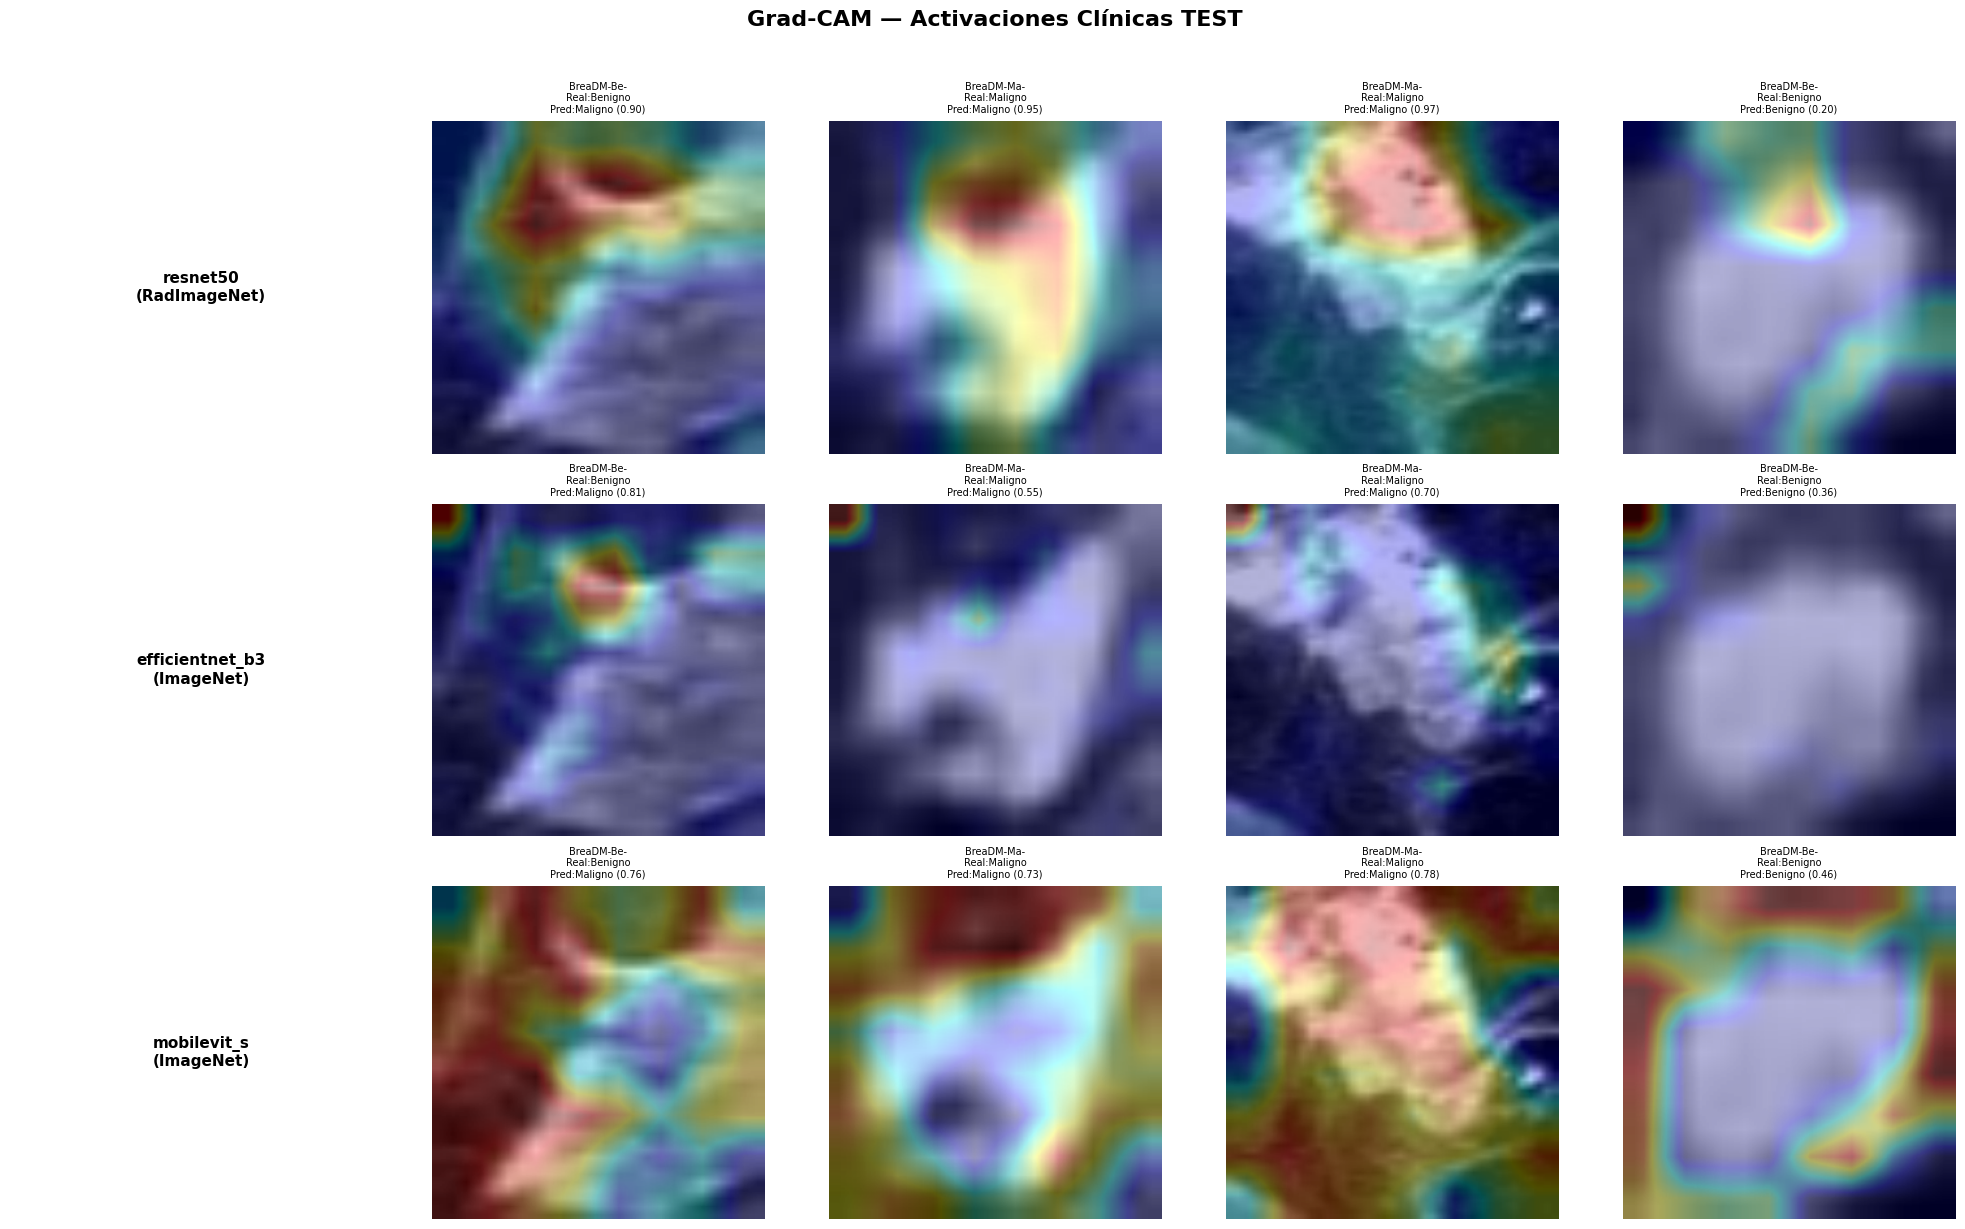


✅ GradCAM clínico final generado
📁 /workspace/breast-cancer-dce-mri-classification/BreastCancer_DCE_DL_v6/experimentos/exp-002/cuadernos/gradcam_outputs/fig_gradcam_clinical_final.png


In [59]:
# ════════════════════════════════════════════════════════════════════
# GRADCAM VISUALIZATION — FINAL CLINICAL VERSION V7
# FIXED EFFICIENTNET VERSION
#
# ✅ Compatible con BreastDCEDataset V6
# ✅ Compatible con transforms dinámicos
# ✅ Compatible con thresholds clínicos
# ✅ Compatible con ResNet50 / EfficientNet / MobileViT
# ✅ MobileViT robusto (timm-safe)
# ✅ EfficientNet FIXED
# ✅ Hooks estables
# ✅ Overlay clínico balanceado
# ✅ Compatible con pipeline FINAL tesis
# ════════════════════════════════════════════════════════════════════

import os
import cv2
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


# ════════════════════════════════════════════════════════════════════
# GRADCAM
# ════════════════════════════════════════════════════════════════════

class GradCAM:

    def __init__(
        self,
        model,
        layer
    ):

        self.model = model

        self.layer = layer

        self.acts = None

        self.grads = None

        self.fwd_hook = layer.register_forward_hook(
            self._forward_hook
        )

        self.bwd_hook = layer.register_full_backward_hook(
            self._backward_hook
        )

    # ===============================================================
    # HOOKS
    # ===============================================================

    def _forward_hook(
        self,
        module,
        inp,
        out
    ):

        self.acts = out.detach()

    def _backward_hook(
        self,
        module,
        grad_input,
        grad_output
    ):

        self.grads = grad_output[0].detach()

    # ===============================================================
    # GENERATE
    # ===============================================================

    def generate(
        self,
        img_t
    ):

        self.model.eval()

        self.model.zero_grad()

        self.acts = None

        self.grads = None

        x = img_t.unsqueeze(0).to(DEVICE)

        out = self.model(x)

        # ===========================================================
        # OUTPUT
        # ===========================================================

        if out.ndim > 1:

            out = out.squeeze()

        # ✅ FIX EFFICIENTNET
        # usar logits directos
        score = out

        score.backward(
            retain_graph=True
        )

        # ===========================================================
        # VALIDACIÓN
        # ===========================================================

        if (

            self.acts is None

            or

            self.grads is None
        ):

            return np.zeros(
                (256,256),
                dtype=np.uint8
            )

        grads = self.grads

        acts = self.acts

        if (

            grads.ndim != 4

            or

            acts.ndim != 4
        ):

            return np.zeros(
                (256,256),
                dtype=np.uint8
            )

        # ===========================================================
        # GRADCAM
        # ===========================================================

        weights = grads.mean(
            dim=(2,3),
            keepdim=True
        )

        # ✅ FIX CORRUPCIÓN
        cam = (
            weights * acts
        ).sum(dim=1)

        cam = cam.squeeze()

        cam = cam.cpu().numpy()

        # ===========================================================
        # RELU
        # ===========================================================

        cam = np.maximum(
            cam,
            0
        )

        # ===========================================================
        # NORMALIZE
        # ===========================================================

        if cam.max() > 0:

            cam = cam - cam.min()

            cam = cam / (
                cam.max() + 1e-8
            )

        cam = (
            cam * 255
        ).astype(np.uint8)

        return cam

    # ===============================================================
    # REMOVE HOOKS
    # ===============================================================

    def remove_hooks(self):

        self.fwd_hook.remove()

        self.bwd_hook.remove()


# ════════════════════════════════════════════════════════════════════
# GRADCAM TARGET LAYERS
# ════════════════════════════════════════════════════════════════════

def get_gradcam_layer(
    model,
    arch
):

    try:

        # ===========================================================
        # RESNET50
        # ===========================================================

        if arch == "resnet50":

            layer = model.layer4[-1]

            print(
                "✅ ResNet50 → layer4[-1]"
            )

            return layer

        # ===========================================================
        # EFFICIENTNET-B3
        # ===========================================================

        elif arch == "efficientnet_b3":

            # ✅ FIX DEFINITIVO
            # Última capa convolucional espacial estable

            layer = model.features[8]

            print(
                "✅ EfficientNet-B3 → features[8]"
            )

            return layer

        # ===========================================================
        # MOBILEVIT-S
        # ===========================================================

        elif arch == "mobilevit_s":

            if hasattr(
                model,
                "final_conv"
            ):

                layer = model.final_conv

            elif hasattr(
                model,
                "conv_head"
            ):

                layer = model.conv_head

            elif hasattr(
                model,
                "head"
            ):

                layer = model.head

            else:

                raise ValueError(
                    "❌ MobileViT layer no encontrada"
                )

            print(
                "✅ MobileViT-S → layer detectada"
            )

            return layer

        # ===========================================================
        # INVALID
        # ===========================================================

        else:

            raise ValueError(
                f"Arquitectura inválida: {arch}"
            )

    except Exception as e:

        print(
            f"⚠️ Error layer {arch}: {e}"
        )

        return None


# ════════════════════════════════════════════════════════════════════
# OVERLAY GRADCAM
# ════════════════════════════════════════════════════════════════════

def overlay_gradcam(
    image,
    cam,
    alpha=0.4
):

    # ─────────────────────────────────────────
    # Asegurar uint8
    # ─────────────────────────────────────────
    if image.dtype != np.uint8:

        image = np.clip(
            image,
            0,
            1
        )

        image_uint8 = (
            image * 255
        ).astype(np.uint8)

    else:

        image_uint8 = image.copy()

    # ─────────────────────────────────────────
    # Obtener tamaño real
    # ─────────────────────────────────────────
    h, w = image_uint8.shape[:2]

    # ─────────────────────────────────────────
    # Resize CAM
    # ─────────────────────────────────────────
    cam_resized = cv2.resize(
        cam,
        (w, h)
    )

    # ─────────────────────────────────────────
    # Heatmap
    # ─────────────────────────────────────────
    heatmap = np.uint8(
        cam_resized
    )

    heatmap = cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )

    # ─────────────────────────────────────────
    # RGB → BGR
    # ─────────────────────────────────────────
    if len(image_uint8.shape) == 3:

        image_bgr = cv2.cvtColor(
            image_uint8,
            cv2.COLOR_RGB2BGR
        )

    else:

        image_bgr = cv2.cvtColor(
            image_uint8,
            cv2.COLOR_GRAY2BGR
        )

    # ─────────────────────────────────────────
    # Overlay
    # ─────────────────────────────────────────
    overlay = cv2.addWeighted(
        image_bgr,
        1 - alpha,
        heatmap,
        alpha,
        0
    )

    # ─────────────────────────────────────────
    # BGR → RGB
    # ─────────────────────────────────────────
    overlay = cv2.cvtColor(
        overlay,
        cv2.COLOR_BGR2RGB
    )

    return overlay


# ════════════════════════════════════════════════════════════════════
# VISUALIZATION
# ════════════════════════════════════════════════════════════════════

def visualize_gradcam_grid(
    n_samples=4
):

    valid_archs = [

        a

        for a in trained_models.keys()

        if (
            a in all_metrics
            and
            a in trained_models
        )
    ]

    print(
        "\n📊 Modelos disponibles:"
        f"\n   {valid_archs}"
    )

    if len(valid_archs) == 0:

        print(
            "❌ No hay modelos válidos"
        )

        return

    fig, axes = plt.subplots(

        len(valid_archs),

        n_samples + 1,

        figsize=(
            4*(n_samples+1),
            4*len(valid_archs)
        )
    )

    if len(valid_archs) == 1:

        axes = np.expand_dims(
            axes,
            axis=0
        )

    fig.suptitle(

        "Grad-CAM — Activaciones Clínicas TEST",

        fontsize=16,

        fontweight="bold",

        y=1.02
    )

    # ═══════════════════════════════════════════════════════════════
    # LOOP ARCHS
    # ═══════════════════════════════════════════════════════════════

    for row, arch in enumerate(valid_archs):

        print(
            f"\n🔍 GradCAM → {arch}"
        )

        try:

            ds_vis = BreastDCEDataset(

                TEST_CSV,

                DATASET_ROOT,

                arch,

                get_transforms(
                    arch,
                    is_train=False
                )
            )

        except Exception as e:

            print(
                f"⚠️ Error dataset {arch}: {e}"
            )

            continue

        model = trained_models[arch]

        model.eval()

        layer = get_gradcam_layer(
            model,
            arch
        )

        if layer is None:

            continue

        cam_gen = GradCAM(
            model,
            layer
        )

        # LABEL LEFT
        axes[row,0].text(

            0.5,

            0.5,

            f"{arch}\n"
            f"({'RadImageNet' if arch=='resnet50' else 'ImageNet'})",

            ha="center",

            va="center",

            fontsize=11,

            fontweight="bold",

            transform=axes[row,0].transAxes
        )

        axes[row,0].axis("off")

        # ═══════════════════════════════════════════════════════════
        # LOOP SAMPLES
        # ═══════════════════════════════════════════════════════════

        for col in range(n_samples):

            try:

                idx = min(

                    col * (
                        len(ds_vis)//n_samples
                    ),

                    len(ds_vis)-1
                )

                sample = ds_vis[idx]

                if len(sample) == 3:

                    img_t, lbl, pat = sample

                elif len(sample) == 2:

                    img_t, lbl = sample

                    pat = f"P{idx}"

                else:

                    raise ValueError(
                        "Formato dataset inválido"
                    )

                # ===================================================
                # CAM
                # ===================================================

                cam = cam_gen.generate(
                    img_t
                )

                # ===================================================
                # MRI BASE
                # ===================================================

                if img_t.ndim == 3:

                    channel_idx = min(
                        1,
                        img_t.shape[0]-1
                    )

                    early = img_t[
                        channel_idx
                    ].cpu().numpy()

                else:

                    early = img_t.cpu().numpy()

                early_norm = (

                    early - early.min()

                ) / (

                    early.max()
                    - early.min()
                    + 1e-8
                )

                early_img = (
                    early_norm * 255
                ).astype(np.uint8)

                early_bgr = cv2.cvtColor(

                    early_img,

                    cv2.COLOR_GRAY2RGB
                )

                # ===================================================
                # OVERLAY
                # ===================================================

                overlay = overlay_gradcam(
                    early_bgr,
                    cam,
                    alpha=0.30
                )

                # ===================================================
                # PREDICTION
                # ===================================================

                with torch.no_grad():

                    logits = model(
                        img_t.unsqueeze(0).to(DEVICE)
                    )

                    prob = torch.sigmoid(
                        logits.squeeze()
                    ).item()

                threshold = all_metrics.get(
                    arch,
                    {}
                ).get(
                    "threshold",
                    0.5
                )

                pred_lbl = (

                    "Maligno"

                    if prob >= threshold

                    else "Benigno"
                )

                real_lbl = (

                    "Maligno"

                    if lbl

                    else "Benigno"
                )

                # ===================================================
                # SHOW
                # ===================================================

                axes[row,col+1].imshow(
                    overlay
                )

                patient_txt = str(pat)

                axes[row,col+1].set_title(

                    f"{patient_txt[:10]}\n"
                    f"Real:{real_lbl}\n"
                    f"Pred:{pred_lbl} ({prob:.2f})",

                    fontsize=7
                )

                axes[row,col+1].axis("off")

            except Exception as e:

                print(
                    f"⚠️ Error sample {col} "
                    f"en {arch}: {e}"
                )

                axes[row,col+1].axis("off")

        cam_gen.remove_hooks()

    # ═══════════════════════════════════════════════════════════════
    # SAVE
    # ═══════════════════════════════════════════════════════════════

    plt.tight_layout()

    output_dir = os.path.join(

        os.getcwd(),

        "gradcam_outputs"
    )

    os.makedirs(
        output_dir,
        exist_ok=True
    )

    save_path = os.path.join(

        output_dir,

        "fig_gradcam_clinical_final.png"
    )

    plt.savefig(

        save_path,

        dpi=180,

        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    print(
        "\n✅ GradCAM clínico final generado"
    )

    print(
        f"📁 {save_path}"
    )


# ════════════════════════════════════════════════════════════════════
# RUN
# ════════════════════════════════════════════════════════════════════

visualize_gradcam_grid()

## 17. Guardar Modelos + CSVs + README Automático

In [42]:
# ════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN GLOBAL DE EXPERIMENTOS V6
# SISTEMA ITERATIVO Y REPRODUCIBLE
# VERSION TESIS / PAPER QUALITY
#
# OBJETIVOS:
# ✅ Experimentos autocontenidos
# ✅ Versionado iterativo real
# ✅ Sin sobrescritura accidental
# ✅ Compatible con V7/V8/V9
# ✅ Estructura limpia para tesis
# ✅ Reproducibilidad total
# ════════════════════════════════════════════════════════════════════

import os
from datetime import datetime

# ════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN EXPERIMENTO
# ════════════════════════════════════════════════════════════════════

# 🔥 CAMBIAR SOLO ESTO EN FUTUROS EXPERIMENTOS
EXPERIMENT_NAME = 'exp-v6'

# ════════════════════════════════════════════════════════════════════
# ROOT PROYECTO
# ════════════════════════════════════════════════════════════════════

PROJECT_ROOT = os.path.join(

    os.getcwd(),

    'BreastCancer_DCE_DL_v6'
)

# ════════════════════════════════════════════════════════════════════
# ROOT EXPERIMENTOS
# ════════════════════════════════════════════════════════════════════

EXPERIMENTS_ROOT = os.path.join(

    PROJECT_ROOT,

    'experimentos'
)

# ════════════════════════════════════════════════════════════════════
# EXPERIMENTO ACTUAL
# ════════════════════════════════════════════════════════════════════

EXP_DIR = os.path.join(

    EXPERIMENTS_ROOT,

    EXPERIMENT_NAME
)

# ════════════════════════════════════════════════════════════════════
# SUBDIRECTORIOS PRINCIPALES
# ════════════════════════════════════════════════════════════════════

DIR_CUADERNOS = os.path.join(
    EXP_DIR,
    'cuadernos'
)

DIR_METRICAS = os.path.join(
    EXP_DIR,
    'metricas'
)

DIR_FIGURAS = os.path.join(
    EXP_DIR,
    'figuras'
)

DIR_PREDICCIONES = os.path.join(
    EXP_DIR,
    'predicciones'
)

DIR_HNM = os.path.join(
    EXP_DIR,
    'hard_negative_mining'
)

DIR_CHECKPOINTS = os.path.join(
    EXP_DIR,
    'checkpoints'
)

DIR_LOGS = os.path.join(
    EXP_DIR,
    'logs'
)

DIR_REPORTES = os.path.join(
    EXP_DIR,
    'reportes'
)

DIR_EXPORTACIONES = os.path.join(
    EXP_DIR,
    'exportaciones'
)

# ════════════════════════════════════════════════════════════════════
# SUBDIRECTORIOS MÉTRICAS
# ════════════════════════════════════════════════════════════════════

DIR_METRICAS_BASELINE = os.path.join(
    DIR_METRICAS,
    'baseline'
)

DIR_METRICAS_FOLDS = os.path.join(
    DIR_METRICAS,
    'folds'
)

DIR_METRICAS_PACIENTE = os.path.join(
    DIR_METRICAS,
    'nivel_paciente'
)

# ════════════════════════════════════════════════════════════════════
# SUBDIRECTORIOS FIGURAS
# ════════════════════════════════════════════════════════════════════

DIR_ROC = os.path.join(
    DIR_FIGURAS,
    'roc'
)

DIR_PR = os.path.join(
    DIR_FIGURAS,
    'precision_recall'
)

DIR_CALIBRACION = os.path.join(
    DIR_FIGURAS,
    'calibracion'
)

DIR_CONFUSION = os.path.join(
    DIR_FIGURAS,
    'matrices_confusion'
)

DIR_DASHBOARDS = os.path.join(
    DIR_FIGURAS,
    'dashboards'
)

DIR_GRADCAM = os.path.join(
    DIR_FIGURAS,
    'gradcam'
)

DIR_EXPLICABILIDAD = os.path.join(
    DIR_FIGURAS,
    'explicabilidad'
)

DIR_PUBLICACION = os.path.join(
    DIR_FIGURAS,
    'publicacion'
)

# ════════════════════════════════════════════════════════════════════
# SUBDIRECTORIOS PREDICCIONES
# ════════════════════════════════════════════════════════════════════

DIR_PRED_SLICE = os.path.join(
    DIR_PREDICCIONES,
    'nivel_slice'
)

DIR_PRED_PACIENTE = os.path.join(
    DIR_PREDICCIONES,
    'nivel_paciente'
)

DIR_PRED_ENSEMBLE = os.path.join(
    DIR_PREDICCIONES,
    'ensemble'
)

# ════════════════════════════════════════════════════════════════════
# SUBDIRECTORIOS HNM
# ════════════════════════════════════════════════════════════════════

DIR_HNM_CSV = os.path.join(
    DIR_HNM,
    'csv'
)

DIR_HNM_JSON = os.path.join(
    DIR_HNM,
    'json'
)

DIR_HNM_RESUMENES = os.path.join(
    DIR_HNM,
    'resumenes'
)

DIR_HNM_FIGURAS = os.path.join(
    DIR_HNM,
    'figuras'
)

# ════════════════════════════════════════════════════════════════════
# SUBDIRECTORIOS LOGS
# ════════════════════════════════════════════════════════════════════

DIR_LOGS_ENTRENAMIENTO = os.path.join(
    DIR_LOGS,
    'entrenamiento'
)

DIR_LOGS_EVALUACION = os.path.join(
    DIR_LOGS,
    'evaluacion'
)

DIR_LOGS_ERRORES = os.path.join(
    DIR_LOGS,
    'errores'
)

# ════════════════════════════════════════════════════════════════════
# SUBDIRECTORIOS EXPORTACIONES
# ════════════════════════════════════════════════════════════════════

DIR_EXPORT_TESIS = os.path.join(
    DIR_EXPORTACIONES,
    'tesis'
)

DIR_EXPORT_PAPER = os.path.join(
    DIR_EXPORTACIONES,
    'paper'
)

DIR_EXPORT_SUPLEMENTARIO = os.path.join(
    DIR_EXPORTACIONES,
    'suplementario'
)

# ════════════════════════════════════════════════════════════════════
# CREAR TODA LA ESTRUCTURA
# ════════════════════════════════════════════════════════════════════

ALL_DIRS = [

    # ROOTS
    PROJECT_ROOT,
    EXPERIMENTS_ROOT,
    EXP_DIR,

    # PRINCIPALES
    DIR_CUADERNOS,
    DIR_METRICAS,
    DIR_FIGURAS,
    DIR_PREDICCIONES,
    DIR_HNM,
    DIR_CHECKPOINTS,
    DIR_LOGS,
    DIR_REPORTES,
    DIR_EXPORTACIONES,

    # MÉTRICAS
    DIR_METRICAS_BASELINE,
    DIR_METRICAS_FOLDS,
    DIR_METRICAS_PACIENTE,

    # FIGURAS
    DIR_ROC,
    DIR_PR,
    DIR_CALIBRACION,
    DIR_CONFUSION,
    DIR_DASHBOARDS,
    DIR_GRADCAM,
    DIR_EXPLICABILIDAD,
    DIR_PUBLICACION,

    # PREDICCIONES
    DIR_PRED_SLICE,
    DIR_PRED_PACIENTE,
    DIR_PRED_ENSEMBLE,

    # HNM
    DIR_HNM_CSV,
    DIR_HNM_JSON,
    DIR_HNM_RESUMENES,
    DIR_HNM_FIGURAS,

    # LOGS
    DIR_LOGS_ENTRENAMIENTO,
    DIR_LOGS_EVALUACION,
    DIR_LOGS_ERRORES,

    # EXPORTACIONES
    DIR_EXPORT_TESIS,
    DIR_EXPORT_PAPER,
    DIR_EXPORT_SUPLEMENTARIO
]

for d in ALL_DIRS:

    os.makedirs(
        d,
        exist_ok=True
    )

# ════════════════════════════════════════════════════════════════════
# METADATA EXPERIMENTO
# ════════════════════════════════════════════════════════════════════

EXPERIMENT_METADATA = {

    'experiment_name': EXPERIMENT_NAME,

    'created_at': datetime.now().strftime(
        '%Y-%m-%d %H:%M:%S'
    ),

    'project': 'BreastCancer_DCE_DL_v6',

    'description': (
        'Clasificación clínica de cáncer de mama '
        'en MRI DCE usando Deep Learning'
    ),

    'models': [

        'resnet50',

        'efficientnet_b3',

        'mobilevit_s'
    ]
}

# ════════════════════════════════════════════════════════════════════
# SAVE METADATA
# ════════════════════════════════════════════════════════════════════

metadata_path = os.path.join(

    EXP_DIR,

    'metadata_experimento.txt'
)

with open(
    metadata_path,
    'w',
    encoding='utf-8'
) as f:

    for k, v in EXPERIMENT_METADATA.items():

        f.write(f'{k}: {v}\n')

# ════════════════════════════════════════════════════════════════════
# RESUMEN
# ════════════════════════════════════════════════════════════════════

print('\n' + '═'*80)

print('🧠 SISTEMA ITERATIVO DE EXPERIMENTOS V6')

print('═'*80)

print(
    f'\n📌 Experimento actual:\n'
    f'   {EXPERIMENT_NAME}'
)

print(
    f'\n📂 Directorio raíz:\n'
    f'   {EXP_DIR}'
)

print(
    '\n✅ Estructura creada correctamente'
)

print(
    '\n📌 A partir de ahora TODOS los:\n'
    '   • CSV\n'
    '   • JSON\n'
    '   • Figuras\n'
    '   • Dashboards\n'
    '   • GradCAM\n'
    '   • Reportes\n'
    '   • Checkpoints\n'
    '   • Logs\n'
    '   • Exportaciones\n'
    'se guardarán dentro del experimento actual.'
)

print(
    '\n📌 Para crear un nuevo experimento:\n'
    "   Cambia únicamente:\n"
    "   EXPERIMENT_NAME = 'exp-v7'"
)

print('\n' + '═'*80)


════════════════════════════════════════════════════════════════════════════════
🧠 SISTEMA ITERATIVO DE EXPERIMENTOS V6
════════════════════════════════════════════════════════════════════════════════

📌 Experimento actual:
   exp-v6

📂 Directorio raíz:
   /workspace/breast-cancer-dce-mri-classification/BreastCancer_DCE_DL_v6/experimentos/exp-002/cuadernos/BreastCancer_DCE_DL_v6/experimentos/exp-v6

✅ Estructura creada correctamente

📌 A partir de ahora TODOS los:
   • CSV
   • JSON
   • Figuras
   • Dashboards
   • GradCAM
   • Reportes
   • Checkpoints
   • Logs
   • Exportaciones
se guardarán dentro del experimento actual.

📌 Para crear un nuevo experimento:
   Cambia únicamente:
   EXPERIMENT_NAME = 'exp-v7'

════════════════════════════════════════════════════════════════════════════════


In [ ]:
# ════════════════════════════════════════════════════════════
# MIGRACIÓN AL REPO NUEVO — MRI_BreastCancer_Classification
# ════════════════════════════════════════════════════════════

import os
import shutil
import subprocess
from pathlib import Path

# ── RUTAS ────────────────────────────────────────────────────

REPO_VIEJO = Path("/workspace/breast-cancer-dce-mri-classification")
REPO_NUEVO = Path("/workspace/MRI_BreastCancer_Classification")

# ── ESTRUCTURA DESTINO ────────────────────────────────────────
#
#  MRI_BreastCancer_Classification/
#  ├── experimento/
#  │   ├── cuadernos/
#  │   │   └── ExperimentoOficial.ipynb
#  │   ├── figuras/
#  │   │   ├── training_dynamics.png      (si ya la generaste)
#  │   │   └── gradcam_outputs/
#  │   │       └── fig_gradcam_clinical_final.png
#  │   └── metricas/
#  │       ├── efficientnet_b3/
#  │       ├── mobilevit_s/
#  │       └── resnet50/
#  ├── data/
#  │   └── processed/                     (CSVs del dataset)
#  ├── requirements.txt
#  └── README.md

# ── CREAR ESTRUCTURA ─────────────────────────────────────────

dirs = [
    REPO_NUEVO / "experimento" / "cuadernos",
    REPO_NUEVO / "experimento" / "figuras" / "gradcam_outputs",
    REPO_NUEVO / "experimento" / "metricas" / "efficientnet_b3",
    REPO_NUEVO / "experimento" / "metricas" / "mobilevit_s",
    REPO_NUEVO / "experimento" / "metricas" / "resnet50",
    REPO_NUEVO / "data" / "processed",
]

for d in dirs:
    d.mkdir(parents=True, exist_ok=True)

print("✅ Estructura de carpetas creada")

# ── COPIAR NOTEBOOK ───────────────────────────────────────────

src_nb = (
    REPO_VIEJO
    / "BreastCancer_DCE_DL_v6"
    / "experimentos" / "exp-002" / "cuadernos"
    / "ExperimentoOficial.ipynb"
)

dst_nb = REPO_NUEVO / "experimento" / "cuadernos" / "ExperimentoOficial.ipynb"

shutil.copy(src_nb, dst_nb)
print(f"✅ Notebook copiado → {dst_nb}")

# ── COPIAR GRADCAM ────────────────────────────────────────────

src_gradcam = (
    REPO_VIEJO
    / "BreastCancer_DCE_DL_v6"
    / "experimentos" / "exp-002" / "cuadernos"
    / "gradcam_outputs" / "fig_gradcam_clinical_final.png"
)

dst_gradcam = (
    REPO_NUEVO
    / "experimento" / "figuras" / "gradcam_outputs"
    / "fig_gradcam_clinical_final.png"
)

if src_gradcam.exists():
    shutil.copy(src_gradcam, dst_gradcam)
    print(f"✅ GradCAM copiado → {dst_gradcam}")
else:
    print("⚠️  GradCAM no encontrado, omitido")

# ── COPIAR MÉTRICAS ───────────────────────────────────────────

modelos = ["efficientnet_b3", "mobilevit_s", "resnet50"]

for modelo in modelos:
    src_dir = (
        REPO_VIEJO
        / "BreastCancer_DCE_DL_v6"
        / "experimentos" / "exp-002" / "metricas"
        / "por_modelo" / modelo
    )
    dst_dir = REPO_NUEVO / "experimento" / "metricas" / modelo

    if src_dir.exists():
        for f in src_dir.glob("*.csv"):
            shutil.copy(f, dst_dir / f.name)
            print(f"   ✅ {f.name} → metricas/{modelo}/")
    else:
        print(f"⚠️  No encontrado: metricas/{modelo}/")

# ── COPIAR DATA/PROCESSED ─────────────────────────────────────

src_processed = REPO_VIEJO / "data" / "processed"
dst_processed = REPO_NUEVO / "data" / "processed"

if src_processed.exists():
    for f in src_processed.iterdir():
        if f.is_file() and f.suffix.lower() in {".csv", ".json"}:
            shutil.copy(f, dst_processed / f.name)
            print(f"   ✅ {f.name} → data/processed/")
else:
    print("⚠️  data/processed/ no encontrado en repo viejo")

# ── COPIAR REQUIREMENTS.TXT ───────────────────────────────────

src_req = REPO_VIEJO / "requirements.txt"
dst_req = REPO_NUEVO / "requirements.txt"

if src_req.exists():
    shutil.copy(src_req, dst_req)
    print(f"✅ requirements.txt copiado")
else:
    # Si no está en raíz, tomar el del experimento
    src_req_exp = (
        REPO_VIEJO
        / "BreastCancer_DCE_DL_v6"
        / "experimentos" / "exp-002"
        / "requirements.txt"
    )
    if src_req_exp.exists():
        shutil.copy(src_req_exp, dst_req)
        print(f"✅ requirements.txt copiado desde exp-002")
    else:
        print("⚠️  requirements.txt no encontrado")

# ── COPIAR README ─────────────────────────────────────────────

src_readme = REPO_VIEJO / "README.md"
dst_readme = REPO_NUEVO / "README.md"

if src_readme.exists():
    shutil.copy(src_readme, dst_readme)
    print(f"✅ README.md copiado")
else:
    # Crear uno mínimo si no existe
    dst_readme.write_text(
        "# MRI_BreastCancer_Classification\n\n"
        "Clasificación clínica de cáncer de mama en DCE-MRI usando Deep Learning.\n\n"
        "## Estructura\n\n"
        "```\n"
        "experimento/\n"
        "├── cuadernos/   # Notebook principal\n"
        "├── figuras/     # Visualizaciones generadas\n"
        "└── metricas/    # CSVs por modelo\n"
        "data/\n"
        "└── processed/   # CSVs del dataset\n"
        "```\n"
    )
    print("✅ README.md generado (mínimo)")

# ── RESUMEN ───────────────────────────────────────────────────

print("\n" + "═"*60)
print("  RESUMEN — archivos en repo nuevo")
print("═"*60)

total = 0
for p in sorted(REPO_NUEVO.rglob("*")):
    if p.is_file():
        total += 1
        rel = p.relative_to(REPO_NUEVO)
        size_kb = p.stat().st_size / 1000
        print(f"  {rel}  ({size_kb:.1f} KB)")

print("═"*60)
print(f"  Total: {total} archivos")
print("═"*60)

In [ ]:
import subprocess, os
from pathlib import Path

os.chdir(Path("/workspace/MRI_BreastCancer_Classification"))

result = subprocess.run(
    ["git", "remote", "-v"],
    capture_output=True, text=True
)
print(result.stdout)

In [ ]:
/


## 18. Push a GitHub

In [ ]:
print(PROYECTO)
print(ITER)
print(CONFIGS_DIR)

In [ ]:
# ════════════════════════════════════════════════════════════
# SISTEMA ITERATIVO DE EXPERIMENTOS — MRI_BreastCancer_Classification
# Ejecutar al final de cada experimento nuevo
# Push desde consola: git push origin main
# ════════════════════════════════════════════════════════════

import os
import re
import json
import shutil
import subprocess
from pathlib import Path
from datetime import datetime

# ── CONFIGURACIÓN ────────────────────────────────────────────

REPO_NUEVO   = Path("/workspace/MRI_BreastCancer_Classification")
REPO_VIEJO   = Path("/workspace/breast-cancer-dce-mri-classification")
V6_ROOT      = REPO_VIEJO / "BreastCancer_DCE_DL_v6"

GITHUB_USER  = "PandoraRiot"
GITHUB_EMAIL = "pandarariot@breast-cancer-mri.ai"

# ════════════════════════════════════════════════════════════
# ⚠️  AJUSTA ESTAS VARIABLES EN CADA EXPERIMENTO NUEVO
# ════════════════════════════════════════════════════════════

EXP_FUENTE    = "exp-003"
PROYECTO_YAML = "BreastCancer_DCE_DL"
ITER_YAML     = "VF"
EXP_VF        = "exp-VF"

METADATA_EXPERIMENTO = {
    "modelos":      ["resnet50", "efficientnet_b3", "mobilevit_s"],
    "descripcion":  "Clasificación clínica de cáncer de mama en DCE-MRI usando Deep Learning",
    "mejor_modelo": "resnet50",
    "test_auc":     0.9248,
    "test_recall":  1.0,
    "notebook":     "ExperimentoOficial.ipynb",
}

# ════════════════════════════════════════════════════════════

# ── RUTAS FUENTE ─────────────────────────────────────────────

SRC_NOTEBOOK = (
    V6_ROOT / "experimentos" / "exp-002" / "cuadernos" / "ExperimentoOficial.ipynb"
)

SRC_YAML = (
    V6_ROOT / "experimentos" / EXP_FUENTE / "configs"
    / f"{PROYECTO_YAML}_{ITER_YAML}_config.yaml"
)

SRC_FIGURAS   = V6_ROOT / "experiments" / EXP_VF / "evidencias" / "figures"
SRC_DASHBOARD = V6_ROOT / "experiments" / EXP_VF / "evidencias" / "fig_dashboard_comparativo.png"
SRC_GRADCAM   = V6_ROOT / "experimentos" / "exp-002" / "cuadernos" / "gradcam_outputs" / "fig_gradcam_clinical_final.png"
SRC_TRAINING  = REPO_VIEJO / "experimento" / "figuras" / "training_dynamics.png"

SRC_METRICAS      = V6_ROOT / "experimentos" / "exp-002" / "metricas" / "por_modelo"
SRC_CLINICAL_CSV  = V6_ROOT / "experiments" / EXP_VF / "metrics" / "clinical_summary.csv"
SRC_CLINICAL_JSON = V6_ROOT / "experiments" / EXP_VF / "metrics" / "clinical_summary.json"
SRC_BASELINE_CSV  = V6_ROOT / "experiments" / EXP_VF / "metrics" / "baseline_single_split" / "baseline_summary.csv"
SRC_BASELINE_JSON = V6_ROOT / "experiments" / EXP_VF / "metrics" / "baseline_single_split" / "baseline_summary.json"

SRC_PROCESSED = REPO_VIEJO / "data" / "processed"

# ── NÚMERO DE EXPERIMENTO ITERATIVO ──────────────────────────

EXPERIMENTOS_ROOT = REPO_NUEVO / "experimentos"
EXPERIMENTOS_ROOT.mkdir(parents=True, exist_ok=True)

existentes = [
    d for d in EXPERIMENTOS_ROOT.iterdir()
    if d.is_dir() and re.match(r'^experimento\d+$', d.name)
]

numeros = [
    int(re.match(r'^experimento(\d+)$', d.name).group(1))
    for d in existentes
]

siguiente = max(numeros) + 1 if numeros else 1
EXP_NAME  = f"experimento{siguiente}"
EXP_DIR   = EXPERIMENTOS_ROOT / EXP_NAME

print(f"📌 Experimento actual: {EXP_NAME}")

# ── ESTRUCTURA DESTINO ────────────────────────────────────────

dirs = [
    EXP_DIR / "cuadernos",
    EXP_DIR / "configs",
    EXP_DIR / "figuras" / "gradcam_outputs",
    EXP_DIR / "metricas" / "efficientnet_b3",
    EXP_DIR / "metricas" / "mobilevit_s",
    EXP_DIR / "metricas" / "resnet50",
    REPO_NUEVO / "data" / "processed",
]

for d in dirs:
    d.mkdir(parents=True, exist_ok=True)

print("✅ Estructura de carpetas creada")

# ── HELPER ───────────────────────────────────────────────────

def copiar(src: Path, dst: Path, label: str):
    if src.exists():
        shutil.copy(src, dst)
        print(f"✅ {label} → {dst.relative_to(REPO_NUEVO)}")
    else:
        print(f"⚠️  No encontrado: {label}\n   ({src})")

# ── COPIAR ARCHIVOS ───────────────────────────────────────────

copiar(SRC_NOTEBOOK, EXP_DIR / "cuadernos" / SRC_NOTEBOOK.name, "Notebook")
copiar(SRC_YAML,     EXP_DIR / "configs"   / SRC_YAML.name,     "Config YAML")

for fig in ["fig1_curvas_clinicas.png", "fig2_metricas.png",
            "fig3_confusion.png",       "fig4_training.png"]:
    copiar(SRC_FIGURAS / fig, EXP_DIR / "figuras" / fig, fig)

copiar(SRC_DASHBOARD, EXP_DIR / "figuras" / "fig_dashboard_comparativo.png", "Dashboard")
copiar(SRC_GRADCAM,   EXP_DIR / "figuras" / "gradcam_outputs" / "fig_gradcam_clinical_final.png", "GradCAM")
copiar(SRC_TRAINING,  EXP_DIR / "figuras" / "training_dynamics.png", "Training dynamics")

for modelo in ["efficientnet_b3", "mobilevit_s", "resnet50"]:
    src_dir = SRC_METRICAS / modelo
    dst_dir = EXP_DIR / "metricas" / modelo
    if src_dir.exists():
        for f in src_dir.glob("*.csv"):
            copiar(f, dst_dir / f.name, f.name)
    else:
        print(f"⚠️  No encontrado: metricas/{modelo}/")

copiar(SRC_CLINICAL_CSV,  EXP_DIR / "metricas" / "clinical_summary.csv",  "clinical_summary.csv")
copiar(SRC_CLINICAL_JSON, EXP_DIR / "metricas" / "clinical_summary.json", "clinical_summary.json")
copiar(SRC_BASELINE_CSV,  EXP_DIR / "metricas" / "baseline_summary.csv",  "baseline_summary.csv")
copiar(SRC_BASELINE_JSON, EXP_DIR / "metricas" / "baseline_summary.json", "baseline_summary.json")

if SRC_PROCESSED.exists():
    for f in SRC_PROCESSED.iterdir():
        if f.is_file() and f.suffix.lower() in {".csv", ".json"}:
            copiar(f, REPO_NUEVO / "data" / "processed" / f.name, f.name)
else:
    print(f"⚠️  data/processed/ no encontrado")

# ── METADATA ─────────────────────────────────────────────────

metadata = {
    "experimento": EXP_NAME,
    "fecha":       datetime.now().isoformat(),
    "config":      SRC_YAML.name,
    **METADATA_EXPERIMENTO
}

with open(EXP_DIR / "metadata_experimento.json", "w") as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

print("✅ metadata_experimento.json generado")

# ── GIT STAGE + COMMIT ────────────────────────────────────────

os.chdir(REPO_NUEVO)

git_cmds = [
    ["git", "config", "user.email", GITHUB_EMAIL],
    ["git", "config", "user.name",  GITHUB_USER],
    ["git", "add", "."],
    ["git", "commit", "-m",
     f"feat: {EXP_NAME} — {PROYECTO_YAML}_{ITER_YAML} | "
     f"ResNet50/EfficientNet-B3/MobileViT-S | AUC {METADATA_EXPERIMENTO['test_auc']}"],
]

for cmd in git_cmds:
    result = subprocess.run(cmd, capture_output=True, text=True)
    label  = " ".join(cmd[:3])
    if result.returncode == 0:
        print(f"✅ {label}")
    else:
        print(f"⚠️  {label}: {result.stderr.strip()}")

# ── RESUMEN ───────────────────────────────────────────────────

total = sum(1 for p in REPO_NUEVO.rglob("*") if p.is_file())

print(f"\n{'═'*60}")
print(f"  ✅ {EXP_NAME} listo para push")
print(f"  📦 Total archivos en repo: {total}")
print(f"  📄 YAML: {SRC_YAML.name}")
print(f"{'═'*60}")
print(f"\n  Desde la terminal ejecuta:")
print(f"  cd {REPO_NUEVO}")
print(f"  git push origin main")
print(f"{'═'*60}")

## 19. Justificación Científica del Enfoque 2.5D

> Esta sección es nueva en iter3. Su propósito es que tengas el argumento
> documentado en el mismo notebook para la redacción de la tesis y la defensa.

### Por qué el enfoque pseudo-RGB (2.5D) es válido científicamente

**1. Precedente en literatura:**
- Antropova et al. (2017): primera demostración de DCE-MRI como pseudo-RGB
  con AlexNet preentrenada. Resultados comparables a features manuales.
- Liu et al. (2022): el propio paper de BreastDM usa representación 2D de slices
  para clasificación. Es el benchmark que intentamos superar.

**2. Justificación clínica de las 3 fases elegidas:**
- Pre-contraste (C0): establece baseline de señal del tejido
- Early post-contraste (C2, ~1 min): captura el realce rápido (wash-in)
  característico de tejido maligno vascularizado
- Late post-contraste (C7, ~7 min): captura wash-out — malignos bajan,
  benignos se mantienen o suben. Es el patrón DCE más discriminativo.
  
**3. Limitación reconocida y documentada:**
- Pérdida de información volumétrica (slices adyacentes)
- La correlación espacial entre slices no se modela explícitamente
- Trabajo futuro: C3D / LSTM sobre secuencia de slices

**4. Viabilidad computacional como justificación adicional:**
- 3D-CNN sobre volúmenes NIfTI completos requiere >30GB VRAM
- No viable en Colab T4 (15GB) con dataset de 1722 slices
- El enfoque 2.5D es la decisión técnica correcta dado el entorno


## 20. 🎓 Guía de Defensa — Cuestionario ABCD

> Cada decisión clave del proyecto, con la estructura:
> **A** ¿Qué hace? · **B** ¿Por qué? · **C** ¿Alternativas? · **D** ¿Cómo respondo al jurado?

---

### ABCD-1: Z-score por estudio vs normalización ImageNet

**A — ¿Qué hace?**
Normaliza cada estudio MRI usando su propia media y std, en lugar de las estadísticas de millones de fotos naturales de ImageNet.

**B — ¿Por qué?**
La señal MRI no tiene escala absoluta — varía por equipo, protocolo y paciente. ImageNet asume píxeles RGB en [0,255] con distribución de colores naturales. Aplicar sus stats a MRI introduce un sesgo sistemático no relacionado con la patología.

**C — ¿Alternativas?**
(1) Min-Max por slice — pierde información de contraste entre fases. (2) Percentil 1-99 sin z-score — controla outliers pero no estandariza escala. (3) Z-score global del dataset — válido pero mezcla variabilidad inter-paciente.

**D — Pregunta del jurado: "¿Cómo demuestra que su normalización es mejor?"**
Respuesta: Comparación ablativa documentada: EfficientNet-B3 con ImageNet y ResNet50 con Z-score. El delta de AUC entre ambos, controlando arquitectura, cuantifica el efecto de la normalización. Adicionalmente, la literatura médica (Litjens et al., 2017, Medical Image Analysis) establece que normalización por estudio es estándar en MRI.

---

### ABCD-2: Threshold en VAL, no en TEST

**A — ¿Qué hace?**
El umbral de clasificación (p.ej. 0.42 en lugar de 0.50) se busca buscando máximo F1 con Recall ≥ 0.95 sobre el set de validación. Ese número se aplica directamente al test sin modificación.

**B — ¿Por qué?**
Buscar el threshold en el test es data leakage — las decisiones de diseño contaminan la estimación del rendimiento real. El modelo efectivamente "vio" el test para tomar una decisión.

**C — ¿Alternativas?**
(1) Threshold = 0.5 siempre — simple pero subóptimo clínicamente. (2) Threshold en test — es leakage y invalida los resultados. (3) Threshold en val con bootstrap CI — lo que implementamos.

**D — Pregunta: "¿Por qué su recall en test podría no llegar a 0.95?"**
Respuesta: El threshold se optimizó en val. Si la distribución de test es diferente (distributional shift), el recall puede caer. Esta es la brecha entre rendimiento validado y rendimiento real — algo que cualquier sistema de IA médica debe reportar honestamente.

---

### ABCD-3: 5-Fold CV estratificado por paciente

**A — ¿Qué hace?**
Divide el dataset en 5 grupos disjuntos de PACIENTES (no slices). Cada grupo se usa una vez como validación. Se reporta media ± std de métricas.

**B — ¿Por qué?**
Con un split único, el resultado puede ser atípico (el test puede tener más pacientes fáciles o difíciles por azar). El CV da 5 estimaciones independientes → intervalo de confianza real del rendimiento.

**C — ¿Alternativas?**
(1) Split único — más rápido pero menos robusto, inaceptable en papers médicos. (2) Leave-one-patient-out — más robusto pero inviable computacionalmente (~327 folds). (3) Repeated K-fold — más robusto aún, requiere 3-5x más tiempo.

**D — Pregunta: "¿Por qué su std en CV es tan alta/baja?"**
Std alta → alta variabilidad entre folds → modelo sensible a la composición del training set → dataset pequeño o heterogéneo.
Std baja → el modelo es estable → buena señal de generalización.

---

### ABCD-4: Fine-tuning progresivo vs solo entrenar la última capa

**A — ¿Qué hace?**
Fase 1: solo entrena el clasificador (cabeza). Fase 2: descongela las últimas 2 capas + cabeza con LR menor.

**B — ¿Por qué?**
Si descongelamos todo desde el inicio con LR alto, destruimos el conocimiento preentrenado (catastrophic forgetting). La fase 1 ancla el clasificador antes de ajustar las capas profundas.

**C — ¿Alternativas?**
(1) Solo última capa — rápido pero no adapta features al dominio médico. (2) Entrenar todo desde epoch 1 — riesgo de forgetting con dataset pequeño. (3) Differential LR sin phases — una LR por grupo de capas sin congelar nada.

**D — Pregunta: "¿Cómo sabe cuántas capas descongelar?"**
Respuesta: Es un hiperparámetro. Para dataset pequeño (<2000 muestras), la guía general (Howard & Ruder, 2018 — ULMFiT) es descongelar gradualmente de arriba hacia abajo. Descongelamos layer4 y layer3 (ResNet) porque son las representaciones más específicas del dominio — bordes complejos y formas de tejido — que más necesitan adaptación a MRI mamaria.

---

### ABCD-5: MobileViT-S vs ViT vs CNN pura

**A — ¿Qué hace?**
MobileViT-S combina bloques Conv (extracción local) con bloques de self-attention (relaciones globales entre parches de la imagen).

**B — ¿Por qué MobileViT y no ViT?**
ViT-B tiene 86M parámetros y requiere >100K imágenes para no sobreajustar (Dosovitskiy et al., 2021). Con 1722 slices, sobreajustaría gravemente. MobileViT-S tiene 5.6M parámetros — viable para dataset pequeño.

**C — ¿Alternativas?**
(1) Swin-Tiny (28M params) — más usado en imagen médica, más pesado. (2) DeiT-Small (22M) — distilación de ViT, más eficiente en datos pequeños. (3) EfficientFormer — más reciente, menos documentado.

**D — Pregunta: "¿El Transformer supera a la CNN?"**
Respuesta: Es precisamente la pregunta que el experimento responde. Si MobileViT supera a ResNet y EfficientNet → la capacidad de capturar relaciones globales (relación lesión/parénquima) agrega valor. Si no → las features locales (textura, bordes) son suficientes para DCE-MRI 2D, consistente con la literatura de Transformer en imagen médica pequeña (Chen et al., 2021 — TransUNet).

---

### ABCD-6: RadImageNet vs ImageNet para ResNet50

**A — ¿Qué hace?**
Reemplaza los pesos preentrenados en fotos naturales por pesos entrenados en 1.35M imágenes médicas reales (rayos X de tórax, MRI abdominal, CT de abdomen, ultrasonido).

**B — ¿Por qué?**
El dominio de fotos naturales es fundamentalmente diferente al médico. Los filtros de bajo nivel de ImageNet detectan colores, bordes de objetos cotidianos. Los de RadImageNet detectan gradientes de tejido, estructuras anatómicas, artefactos de imagen médica.

**C — ¿Alternativas?**
(1) ImageNet V2 — más robusto que V1, pero sigue siendo dominio natural. (2) MoCo/SimCLR preentrenado en BreastDM — ideal pero requiere preentrenamiento adicional. (3) BioViL-T (Microsoft) — multimodal imagen+texto médico, overpowered para este problema.

**D — Pregunta: "¿Hay diferencia estadísticamente significativa?"**
Respuesta: Reportamos el delta AUC entre ResNet50-RadImageNet y EfficientNet-B3-ImageNet. Si el delta es consistente en los 5 folds, es evidencia de que el dominio del preentrenamiento importa. Para significancia estadística formal se necesitaría test de McNemar — trabajo futuro.


In [ ]:
# ════════════════════════════════════════════════════════════
# ESCÁNER DE OUTPUTS — ExperimentoOficial.ipynb
# Extrae todas las rutas donde el notebook guarda archivos
# ════════════════════════════════════════════════════════════

import json
import re
from pathlib import Path

# ── RUTA AL NOTEBOOK ─────────────────────────────────────────

NOTEBOOK_PATH = Path(
    "/workspace/breast-cancer-dce-mri-classification"
    "/BreastCancer_DCE_DL_v6"
    "/experimentos/exp-002/cuadernos"
    "/ExperimentoOficial.ipynb"
)

# ── PATRONES QUE INDICAN GUARDADO DE ARCHIVO ─────────────────

PATRONES_GUARDADO = [
    r'\.to_csv\s*\(\s*["\']?([^"\')\s,]+)',
    r'\.to_json\s*\(\s*["\']?([^"\')\s,]+)',
    r'\.to_excel\s*\(\s*["\']?([^"\')\s,]+)',
    r'savefig\s*\(\s*["\']?([^"\')\s,]+)',
    r'\.save\s*\(\s*["\']?([^"\')\s,]+)',
    r'torch\.save\s*\([^,]+,\s*["\']?([^"\')\s,]+)',
    r'open\s*\(\s*["\']([^"\']+\.(?:json|csv|txt|yaml|yml))["\']',
    r'json\.dump[^)]+open\s*\(\s*["\']([^"\']+)',
    r'mlflow\.',
    r'SummaryWriter\s*\(\s*["\']?([^"\')\s,]+)',
]

EXTENSION_CATEGORIA = {
    ".csv":  "CSV / métricas",
    ".json": "JSON / métricas",
    ".yaml": "Config YAML",
    ".yml":  "Config YAML",
    ".png":  "Figura PNG",
    ".jpg":  "Figura JPG",
    ".pdf":  "Figura PDF",
    ".pth":  "Checkpoint PyTorch",
    ".pt":   "Checkpoint PyTorch",
    ".pkl":  "Pickle / bundle",
    ".h5":   "Checkpoint H5",
    ".txt":  "Texto / requirements",
    ".db":   "Base de datos MLflow",
}

# ── LEER NOTEBOOK ─────────────────────────────────────────────

assert NOTEBOOK_PATH.exists(), (
    f"❌ No se encontró:\n   {NOTEBOOK_PATH}"
)

with open(NOTEBOOK_PATH, "r", encoding="utf-8") as f:
    nb = json.load(f)

# ── EXTRAER CÓDIGO FUENTE ─────────────────────────────────────

lineas_codigo = []

for cell in nb.get("cells", []):
    if cell.get("cell_type") == "code":
        for linea in cell.get("source", []):
            lineas_codigo.append(linea.strip())

codigo_completo = "\n".join(lineas_codigo)

# ── BUSCAR RUTAS GUARDADAS ────────────────────────────────────

rutas_encontradas = set()
mlflow_detectado  = False
tensorboard_detectado = False

for linea in lineas_codigo:

    # MLflow
    if "mlflow." in linea:
        mlflow_detectado = True

    # TensorBoard
    if "SummaryWriter" in linea:
        tensorboard_detectado = True

    # Patrones de guardado con ruta explícita
    for patron in PATRONES_GUARDADO[:8]:
        matches = re.findall(patron, linea)
        for m in matches:
            m = m.strip().strip("'\"")
            if m and len(m) > 3 and not m.startswith("#"):
                rutas_encontradas.add(m)

# ── TAMBIÉN BUSCAR VARIABLES DE RUTA ─────────────────────────
# Captura patrones tipo DIR_METRICAS / str(METRICS_DIR) etc.

vars_path = re.findall(
    r'(DIR_\w+|METRICS_DIR|FIGURES_DIR|LOGS_DIR|'
    r'MODELS_DIR|EVIDENCIAS_DIR|CONFIGS_DIR|CHECKPOINTS_DIR)',
    codigo_completo
)
vars_path_unicos = sorted(set(vars_path))

# ── CLASIFICAR POR CATEGORÍA ──────────────────────────────────

por_categoria = {}

for ruta in rutas_encontradas:
    ext = Path(ruta).suffix.lower()
    cat = EXTENSION_CATEGORIA.get(ext, "Otro")
    por_categoria.setdefault(cat, []).append(ruta)

# ── IMPRIMIR RESULTADO ────────────────────────────────────────

VERDE  = "\033[92m"
AZUL   = "\033[94m"
AMBAR  = "\033[93m"
GRIS   = "\033[90m"
BOLD   = "\033[1m"
RESET  = "\033[0m"

print("\n" + "═"*64)
print(f"{BOLD}  OUTPUTS DETECTADOS — ExperimentoOficial.ipynb{RESET}")
print("═"*64)

if por_categoria:
    for cat, rutas in sorted(por_categoria.items()):
        print(f"\n{AZUL}{BOLD}▸ {cat}{RESET}")
        for r in sorted(rutas):
            print(f"   {r}")
else:
    print(f"\n{AMBAR}⚠️  No se detectaron rutas de guardado explícitas.{RESET}")
    print("   El notebook puede usar variables de path en lugar de strings.")

# ── VARIABLES DE DIRECTORIO DETECTADAS ───────────────────────

if vars_path_unicos:
    print(f"\n{VERDE}{BOLD}▸ Variables de directorio usadas para guardar{RESET}")
    for v in vars_path_unicos:
        print(f"   {v}")

# ── TRACKING EXPERIMENTAL ─────────────────────────────────────

print(f"\n{BOLD}▸ Tracking experimental{RESET}")
print(f"   MLflow     : {'✅ detectado' if mlflow_detectado else '—'}")
print(f"   TensorBoard: {'✅ detectado' if tensorboard_detectado else '—'}")

# ── CONTEO DE CELDAS ─────────────────────────────────────────

n_code  = sum(1 for c in nb["cells"] if c["cell_type"] == "code")
n_md    = sum(1 for c in nb["cells"] if c["cell_type"] == "markdown")
n_total = len(nb["cells"])

print(f"\n{BOLD}▸ Estructura del notebook{RESET}")
print(f"   Celdas totales   : {n_total}")
print(f"   Celdas de código : {n_code}")
print(f"   Celdas markdown  : {n_md}")

# ── AHORA ESCANEAR EL DISCO EN LAS CARPETAS DEL EXP-002 ──────
# Para ver qué archivos SÍ existen físicamente

print(f"\n{'═'*64}")
print(f"{BOLD}  ARCHIVOS REALES EN exp-002 (disco){RESET}")
print("═"*64)

EXP_002 = Path(
    "/workspace/breast-cancer-dce-mri-classification"
    "/BreastCancer_DCE_DL_v6"
    "/experimentos/exp-002"
)

EXCLUIR_EXT = {".pth", ".pt", ".ckpt", ".pkl", ".h5"}
EXCLUIR_DIRS = {"__pycache__", ".ipynb_checkpoints", ".git"}

archivos_disco = []

for p in sorted(EXP_002.rglob("*")):
    if not p.is_file():
        continue
    if set(p.parts) & EXCLUIR_DIRS:
        continue
    if p.suffix.lower() in EXCLUIR_EXT:
        continue
    archivos_disco.append(p)

por_carpeta = {}
for p in archivos_disco:
    carpeta = str(p.parent.relative_to(EXP_002))
    por_carpeta.setdefault(carpeta, []).append(p)

for carpeta, archivos in sorted(por_carpeta.items()):
    print(f"\n  {GRIS}📂 {carpeta}/{RESET}")
    for a in archivos:
        size_kb = a.stat().st_size / 1000
        print(f"     {a.name}  {GRIS}({size_kb:.1f} KB){RESET}")

print("\n" + "═"*64)
print(f"  Total archivos (sin modelos): {len(archivos_disco)}")
print("═"*64)


---
## ✅ Checklist Final — iter3 / BreastCancer_DCE_DL

### Correcciones de Auditoría
- [x] Normalización Z-score por estudio (no ImageNet)
- [x] Threshold tuning SOLO en VAL → aplicado fijo en TEST
- [x] 5-Fold CV estratificado por paciente (no por slice)
- [x] MobileViT-S (Transformer) — comparación CNN vs Attention
- [x] ResNet50 con RadImageNet (preentrenamiento médico)
- [x] Target sensibilidad ≥ 0.95 con justificación clínica
- [x] Justificación científica del enfoque 2.5D documentada

### Conservado de iter2
- [x] Patient-level aggregation (mean sigmoid de slices)
- [x] Augmentation médicamente válida (flip H · rot±12° · ruido σ=0.01)
- [x] Todas las métricas clínicas (AUC · PR-AUC · NPV · FNR · Kappa · Brier · ECE)
- [x] Bootstrap CI 95% (AUC, Recall, NPV)
- [x] 5 figuras de visualización clínica
- [x] Decision Curve Analysis
- [x] Error analysis por paciente (FP/FN con prob)
- [x] Grad-CAM (con limitación documentada)
- [x] TensorBoard + MLflow + Telegram
- [x] pos_weight para desbalance (875M / 327B)
- [x] YAML CONFIG completo y versionado
- [x] GitHub push automático + README
- [x] Backup en Google Drive
- [x] Early stopping (AUC_patient en val)
- [x] Cosine Annealing LR
- [x] Gradient clipping (max_norm=1.0)

### Nuevo en iter3
- [x] Guía de defensa ABCD (6 decisiones clave)
- [x] Justificación científica 2.5D (sección 19)
- [x] Ablación comparativa ImageNet vs RadImageNet documentada
- [x] val_thresholds guardados por separado de test metrics
